## Summary of D-Wave Classical Portfolio Optimization

This notebook tested three D-Wave classical sampling algorithms on portfolio optimization:

### **Algorithms Tested:**
1. **Simulated Annealing**: Probabilistic algorithm with good exploration capabilities
2. **Tabu Search**: Deterministic local search with memory to avoid cycling
3. **Steepest Descent**: Greedy local search, fastest but can get trapped

### **Datasets Used:**
- **10 stocks**: Small problem for detailed analysis
- **100 stocks**: Medium-scale portfolio  
- **Full dataset**: All available stocks
- **Wide dataset**: Stocks + ETFs for maximum diversification

### **Key Benefits of D-Wave Classical Approach:**
- **No quantum hardware required**: Runs locally on classical computers
- **No API tokens needed**: Pure classical algorithms
- **Educational value**: Shows how portfolio optimization maps to quadratic optimization
- **Baseline for quantum**: Provides classical benchmark for quantum algorithms
- **Multiple algorithms**: Compare different optimization strategies

### **Expected Results:**
- **Simulated Annealing**: Usually best overall performance, especially on larger problems
- **Tabu Search**: Good balance of quality and computational time
- **Steepest Descent**: Fastest execution but may find sub-optimal solutions

### **Next Steps:**
Compare these results with:
- Genetic algorithms (`portfolio_optimization.ipynb`)
- Quantum D-Wave CQM solvers (`quantum_scaffolding.ipynb`) 
- Traditional optimization methods (scipy, riskfolio)

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import logging
import os
import warnings
import itertools
from datetime import datetime, timedelta
from functools import partial
from pathlib import Path

# Configure logging BEFORE importing optimization_engines
SEED = 12
np.random.seed(SEED)
msg_level = logging.INFO

# Set global logging level
logging.basicConfig(level=msg_level, force=True)

# Import after logging configuration
from optimization_engines import dwave_classical_sharpe

# Suppress all RuntimeWarnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Portfolio Optimization using D-Wave Classical Samplers

This notebook compares different D-Wave classical optimization algorithms:
- **Simulated Annealing**: Good overall performance, best for most problems  
- **Tabu Search**: Good balance of quality and speed
- **Steepest Descent**: Fastest but can get stuck in local optima

All algorithms run locally without requiring quantum hardware or API tokens.

In [57]:
# Create a logger
logger = logging.getLogger("inspect_results_logger")
logger.setLevel(msg_level)  # Set the level for this logger

# Set logging level for all loggers with this name
logging.getLogger("inspect_results_logger").setLevel(msg_level)

# Clear any existing handlers to prevent duplicates
logger.handlers.clear()

# Create a handler (where to send the logs) only if none exist
if not logger.handlers:
    handler = logging.StreamHandler()  # Send to the console
    handler.setLevel(msg_level)
    
    # Create a formatter (how to format the logs)
    formatter = logging.Formatter("%(asctime)s - %(name)s - %(levelname)s - %(message)s")
    handler.setFormatter(formatter)
    
    # Add the handler to the logger
    logger.addHandler(handler)

### Path definition

In [58]:
benchmark_path = '../data/benchmark_gspc.pkl'
source_path = '../data/stocks_adjclose.pkl'

### Data loading

Ticker,ds,^GSPC
0,2011-01-03,1271.869995
1,2011-01-04,1270.199951
2,2011-01-05,1276.560059
3,2011-01-06,1273.849976
4,2011-01-07,1271.500000


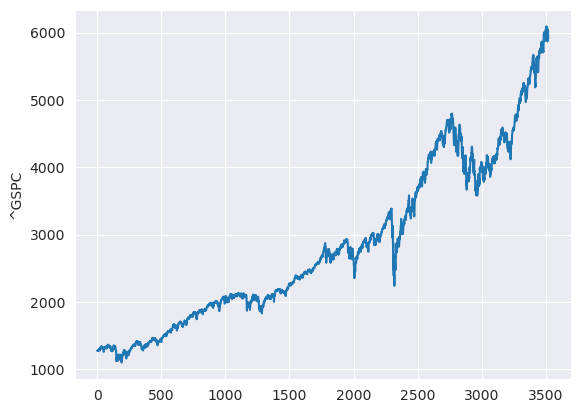

In [59]:
benchmark = pd.read_pickle(benchmark_path)
sns.lineplot(benchmark['^GSPC'])
benchmark.head()

In [60]:
source = pd.read_pickle(source_path)
print(source.shape)
# Check if any row contains at least one NaN
#print(source_wide.isnull().any(axis=1))
# Check if any value in the DataFrame is null
has_any_nan = source.isnull().values.any()
print("Any NaN in source_wide:", has_any_nan)
source.head()

(3522, 439)
Any NaN in source_wide: False


Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WRB,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,39.270000,...,6.112024,18.971697,71.104691,11.828708,76.192101,14.700940,43.098133,26.977388,47.841393,38.200001
2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,38.529999,...,6.072278,18.631702,69.911537,11.702991,78.568939,14.763333,43.300457,26.565216,47.206047,37.840000
2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,41.240002,...,6.045782,18.713308,70.882263,12.068158,79.582596,14.675976,43.184826,26.691620,47.240875,37.799999
2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,41.259998,...,5.977333,18.577297,71.084503,11.984348,80.162842,14.663502,43.462337,26.878460,45.778728,37.480000
2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,40.759998,...,5.939793,18.486635,70.963158,12.313586,83.001091,14.794533,43.699345,27.213682,45.770027,37.599998


### Correlation Analysis

* Determine a set of stocks with minimal correlation

In [61]:
df_corr = source.corr()
df_corr.head()

Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WRB,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Ticker,,,,,,,,,,,,,,,,,,,,,
A,1.000000,0.938434,0.972057,0.803930,0.973666,0.944446,0.958391,0.877209,0.950709,0.946486,...,0.915526,0.962450,0.952409,0.840455,-0.192150,0.925082,0.581125,0.957106,0.742547,0.926361
AAPL,0.938434,1.000000,0.925958,0.904199,0.965640,0.912658,0.974905,0.858673,0.957237,0.883810,...,0.954041,0.944027,0.944347,0.799052,-0.274004,0.864298,0.709763,0.932155,0.609996,0.834967
ABT,0.972057,0.925958,1.000000,0.780764,0.974008,0.966874,0.947089,0.840192,0.947416,0.967112,...,0.905557,0.957242,0.959083,0.826124,-0.199613,0.959269,0.502779,0.961910,0.787986,0.938066
ACGL,0.803930,0.904199,0.780764,1.000000,0.859009,0.772929,0.921957,0.746998,0.908116,0.731481,...,0.943648,0.783657,0.889515,0.726342,-0.175307,0.746701,0.854873,0.878777,0.539229,0.617688
ACN,0.973666,0.965640,0.974008,0.859009,1.000000,0.962718,0.975225,0.861665,0.975261,0.940212,...,0.947315,0.970085,0.967641,0.856489,-0.227554,0.926912,0.623003,0.971591,0.727454,0.899654


#### Rank correlation ascending

In [62]:
# rank by correlation
corr_sum = df_corr.map(lambda x: abs(x)).sum()
corr_rank = corr_sum.sort_values().rank(method='min').astype(int)
corr_rank

Ticker
TPR       1
BKR       2
GE        3
WYNN      4
DVN       5
       ... 
TXN     435
TEL     436
ITW     437
ICE     438
HD      439
Length: 439, dtype: int64

#### Rank returns descending

In [63]:
# rank by returns
return_rank = source.diff().sum(axis=0).sort_values().rank(method='min', ascending=False).astype(int)
return_rank

Ticker
APA     439
MOS     438
SLB     437
DVN     436
PCG     435
       ... 
TDG       5
FICO      4
AZO       3
BKNG      2
NVR       1
Length: 439, dtype: int64

#### Select sets of 10 and 100 stocks with maximal returns and minimal correlation

In [64]:
select_10 = (return_rank + corr_rank).sort_values().reset_index()['Ticker'].values[:11]
select_10

array(['FICO', 'LLY', 'MCK', 'CHTR', 'GWW', 'AXON', 'REGN', 'RCL', 'RL',
       'TSLA', 'TPL'], dtype=object)

In [65]:
select_100 = (return_rank + corr_rank).sort_values().reset_index()['Ticker'].values[:101]
select_100

array(['FICO', 'LLY', 'MCK', 'CHTR', 'GWW', 'AXON', 'REGN', 'RCL', 'RL',
       'TSLA', 'TPL', 'MKTX', 'PWR', 'URI', 'TRGP', 'ZBRA', 'KLAC',
       'NFLX', 'ALGN', 'HUBB', 'AVGO', 'IBM', 'GE', 'BA', 'SPG', 'PH',
       'GNRC', 'ETN', 'BKNG', 'LULU', 'ERIE', 'DECK', 'AZO', 'WAB',
       'EXPE', 'CPAY', 'TDG', 'NVDA', 'BIIB', 'ULTA', 'TFX', 'SNPS',
       'MPWR', 'PODD', 'FDX', 'COST', 'LII', 'VRTX', 'TT', 'BLDR', 'MMM',
       'HUM', 'IT', 'CAT', 'ORLY', 'CAH', 'UAL', 'AMP', 'SBAC', 'UHS',
       'ESS', 'MHK', 'MTB', 'CDNS', 'GILD', 'EOG', 'WST', 'CRL', 'ADBE',
       'COR', 'GPN', 'GS', 'MSI', 'DIS', 'FFIV', 'JBL', 'IDXX', 'DE',
       'CLX', 'PGR', 'AJG', 'KKR', 'FRT', 'ADSK', 'DVA', 'VRSN', 'ANSS',
       'HES', 'XOM', 'CVX', 'MSCI', 'IRM', 'POOL', 'ISRG', 'INCY', 'TTWO',
       'NVR', 'COP', 'LIN', 'BDX', 'FIS'], dtype=object)

Defining Fitness Function for the calculation of Sharpe Ratio. I am using the Portfolio Variance as 

Portfolio variance = w12σ12 + w22σ22 + 2w1w2Cov1,2

### Porfolio Stats

In [66]:
def portfolio_stats(weights, data):

    weights = np.array(weights)
    returns =np.log(data) - np.log(data.shift(1)) # log return to minimize fp error
    #returns = data.pct_change().dropna()
    port_return = np.sum(returns.mean() * weights) 
    port_vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov() , weights)))
    try:
        sharpe_ratio = port_return/port_vol
    except Exception as e:
        sharpe_ratio = 0
    return sharpe_ratio, port_return, port_vol

### Fitness function

In [67]:
def fitness_function(weights, data):
    sharpe_ratio, _, _ = portfolio_stats(weights, data)
    return sharpe_ratio


In [68]:
def curried_fitness(weights, data):
    port_return = partial(fitness_function, data)
    return port_return

def minimize_sharpe(weights):
    return -1 * curried_fitness(weights)

### Data generator

Data generator to instantiate blocks on demand

In [69]:
def generate_data(df, benchmark, days_to_avg=30, days_to_opt=30, seed=SEED):
    df2 = df.reset_index()
    benchmark2 = benchmark.reset_index()
    elements = df2.sample(n=100, random_state=seed).index # definint a maximum of 100 different sampled initial dates
    for idx in elements:
        df_sample = df2.iloc[idx-days_to_avg:idx+days_to_opt, :]
        df_sample = df_sample.set_index('ds')
        df_sample_b = benchmark2.iloc[idx-days_to_avg:idx+days_to_opt, :]
        df_sample_b = df_sample_b.set_index('ds').drop(['index'], axis=1)
        yield df_sample, df_sample_b

### Backtest

In [70]:
def backtest(optimization_function, data, benchmark, initial_capital, avg_period, opt_period):
    portfolio_value = initial_capital
    portfolio_returns = []
    benchmark_returns = []
    portfolio_total_return = []
    portfolio_sharpe_ratios = []
    weights_history = pd.DataFrame(index=data.index, columns=data.columns)
    portfolio_value_history = pd.Series(index=data.index, name='Portfolio Value', dtype='float')
    portfolio_value_history.iloc[0] = portfolio_value


    j = 0
    for i in range(avg_period+1, avg_period + opt_period+1):
        df = data.iloc[j:i, :]
        df_pct = df.iloc[j:i, :].pct_change().dropna(axis=0)
        #logger.debug(f'df_pct: {df_pct}')
        weights = optimization_function(df)
        weights[weights < 0] = 0
        weights /= weights.sum()
        weights_history.loc[df.index[-1]] = weights
        #sharpe_ratio, portfolio_return, portfolio_volatility = portfolio_stats(weights, df)
        # portfolio_change = df.iloc[-2:, :].pct_change() * weights
        portfolio_change = df_pct.iloc[-1] * weights
        #portfolio_return = portfolio_change.sum(axis=1).iloc[-1]
        portfolio_return = portfolio_change.sum()
        portfolio_returns.append(portfolio_return)
        # print(f'portfolio returns: {portfolio_returns}')
        benchmark_return = benchmark.iloc[j:i, :].pct_change().iloc[-1].values.tolist()[0]
        benchmark_returns.append(benchmark_return)
        # print(f'benchmark_returns: {benchmark_returns}')
        portfolio_cumulative_returns = np.cumprod([k + 1 for k in portfolio_returns])
        # print(f'portfolio cumulative returns: {portfolio_cumulative_returns}')
        benchmark_cumulative_returns = np.cumprod([k + 1 for k in  benchmark_returns])
        # print(f'benchmark cumulative returns: {benchmark_cumulative_returns}')
        portfolio_mean_return = np.mean(portfolio_returns)
        benchmark_mean_return = np.mean(benchmark_returns)
        portfolio_volatility = np.std(portfolio_returns) 
        benchmark_volatility = np.std(benchmark_returns)
        try:
            sharpe_ratio = (portfolio_mean_return) / portfolio_volatility
        except Exception as e:
            sharpe_ratio = 0
        portfolio_sharpe_ratios.append(sharpe_ratio)

         # Portfolio & Benchmark value
        benchmark_value = initial_capital * benchmark_cumulative_returns[-1]
        portfolio_value = initial_capital * portfolio_cumulative_returns[-1]
        j += 1

    portfolio_cumulative_returns = portfolio_cumulative_returns - portfolio_cumulative_returns[0]
    benchmark_cumulative_returns = benchmark_cumulative_returns - benchmark_cumulative_returns[0]

    # Plot the results
    plt.figure(figsize=(12, 6))
    plt.plot(portfolio_cumulative_returns, label='Portfolio')
    plt.plot(benchmark_cumulative_returns, label='Benchmark')
    #plt.plot(portfolio_returns, label='Portfolio')
    #plt.plot(benchmark_returns, label='Benchmark')
    plt.legend(loc='upper left')
    plt.title('Backtesting Results')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Returns')
    plt.show()

    return weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns

In [71]:
import pickle

def write_pickle_dict(data, file_path):
    """Pickles a dictionary and saves it to a file."""
    try:
        with open(file_path, 'wb') as f:  # Open the file in binary write mode ('wb')
            pickle.dump(data, f)
        print(f"Dictionary pickled and saved to {file_path}")
    except Exception as e:
        print(f"An error occurred while pickling: {e}")

def read_pickle_dict(file_path):
    try:
        with open(file_path, 'rb') as f:
            loaded_dict = pickle.load(f)
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found.")
    except Exception as e:
        print(f"An error occurred: {e}")
    return loaded_dict



### Run Experiment Function

In [72]:
def run_experiment(results_path_template, data, benchmark, opt_fun, parameters):

    n_periods = parameters['n_periods']
    days_to_avg = parameters['days_to_avg']
    days_to_opt = parameters['days_to_opt']
    population_size = parameters['population_size']
    num_generations = parameters['num_generations']
    initial_capital = parameters['initial_capital']
    datagen = generate_data(data, benchmark)

        
    for i in range(n_periods):
        results_path = results_path_template.format(i)
        if not os.path.exists(results_path):
            try:
                df, df_b = next(datagen)
                print(f'initial date: {df.iloc[days_to_avg+1:, :].index[0]}')
                plt.figure(figsize=(12, 6))
                plt.plot(df.iloc[days_to_avg+1:days_to_avg+days_to_opt+1, :].sum(axis=1), label='Source')
                plt.plot(df_b, label='Benchmark')
                plt.legend(loc='upper left')
                plt.title('Source Data')
                plt.xlabel('Date')
                plt.ylabel('Stock Values')
                plt.show()
                start_time = datetime.now()
                weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns = backtest(opt_fun, df, df_b, initial_capital=initial_capital, avg_period=days_to_avg,opt_period=days_to_opt)
                logger.debug(f'portfolio cumulative returns: {portfolio_cumulative_returns}')
                end_time = datetime.now()
                dt = abs(end_time - start_time)
            except Exception as e: 
                print(f'Failed {results_path} due to {e}')
                weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns = [], [], [], []

            result = {
                "round": i, 
                "start_date": df.index[0],
                "end_date": df.index[-1],
                "population_size": population_size,
                "num_generations": num_generations,
                "days_to_avg": days_to_avg,
                "days_to_opt": days_to_opt,
                "weights_history": weights_history,
                "portfolio_value_history": portfolio_value_history,
                "portfolio_cumulative_returns": portfolio_cumulative_returns,
                "benchmark_cumulative_returns": benchmark_cumulative_returns,
                "total_run_time": dt.total_seconds()
                }
            write_pickle_dict(result, results_path)

        else:
            results = read_pickle_dict(results_path)
            portfolio_cumulative_returns = results['portfolio_cumulative_returns']
            benchmark_cumulative_returns = results['benchmark_cumulative_returns']

            # Plot the results
            plt.figure(figsize=(12, 6))
            plt.plot(portfolio_cumulative_returns, label='Portfolio')
            plt.plot(benchmark_cumulative_returns, label='Benchmark')
            plt.legend(loc='upper left')
            plt.title('Backtesting Results')
            plt.xlabel('Date')
            plt.ylabel('Cumulative Returns')
            plt.show()
            
    return None

### Comparison functions

In [73]:
def pair_comparison(results_path_1_template, results_path_2_template, parameters):
    n_periods = parameters['n_periods']

    for i in range(n_periods):
        results_path_1 = results_path_1_template.format(i)
        results_path_2 = results_path_2_template.format(i)
        results_1 = read_pickle_dict(results_path_1)
        results_2 = read_pickle_dict(results_path_2) 
        portfolio_cumulative_returns_ga = results_1['portfolio_cumulative_returns']
        benchmark_cumulative_returns_ga = results_1['benchmark_cumulative_returns']
        portfolio_cumulative_returns_bf = results_2['portfolio_cumulative_returns']
        benchmark_cumulative_returns_bf = results_2['benchmark_cumulative_returns']

        # Plot the results
        plt.figure(figsize=(12, 6))
        plt.plot(portfolio_cumulative_returns_ga, label=f'{results_path_1}')
        plt.plot(portfolio_cumulative_returns_bf, label=f'{results_path_2}')
        plt.plot(benchmark_cumulative_returns_ga, label='Benchmark')
        plt.legend(loc='upper left')
        plt.title('Backtesting Results')
        plt.xlabel('Date')
        plt.ylabel('Cumulative Returns')
        plt.show()

def multi_comparison(solver_configs, n_periods, title_prefix="Portfolio Optimization", show_benchmark=True):
    """
    Compare multiple portfolio optimization solvers across periods.
    
    Args:
        solver_configs (list): List of dictionaries with 'path_template' and 'name' keys
        n_periods (int): Number of periods to compare
        title_prefix (str): Prefix for plot titles
        show_benchmark (bool): Whether to show benchmark comparison
    """
    
    for period in range(n_periods):
        period_data = []
        benchmark_data = None
        
        # Load data for all solvers for this period
        for config in solver_configs:
            path_template = config['path_template']
            solver_name = config['name']
            file_path = path_template.format(period)
            
            try:
                result_data = read_pickle_dict(file_path)
                if result_data is not None:
                    portfolio_returns = result_data.get('portfolio_cumulative_returns', [])
                    benchmark_returns = result_data.get('benchmark_cumulative_returns', [])
                    start_date = result_data.get('start_date', 'Unknown')
                    execution_time = result_data.get('total_run_time', 0)
                    
                    # Check if portfolio_returns has data (handle NumPy arrays properly)
                    has_portfolio_data = False
                    if portfolio_returns is not None:
                        try:
                            has_portfolio_data = len(portfolio_returns) > 0
                        except TypeError:
                            # Handle case where portfolio_returns is not a sequence
                            has_portfolio_data = portfolio_returns is not None
                    
                    if has_portfolio_data:
                        period_data.append({
                            'name': solver_name,
                            'portfolio_returns': portfolio_returns,
                            'benchmark_returns': benchmark_returns,
                            'start_date': start_date,
                            'execution_time': execution_time,
                            'file_path': file_path
                        })
                        
                        # Store benchmark from first successful load
                        if benchmark_data is None and benchmark_returns is not None:
                            try:
                                if len(benchmark_returns) > 0:
                                    benchmark_data = benchmark_returns
                            except (TypeError, AttributeError):
                                pass
                        
                        logger.info(f'Period {period}: Loaded {solver_name} (exec_time: {execution_time:.2f}s)')
                    else:
                        logger.warning(f'Period {period}: {solver_name} has no portfolio returns data')
                else:
                    logger.warning(f'Period {period}: Could not load {solver_name} from {file_path}')
                    
            except Exception as e:
                logger.error(f'Period {period}: Error loading {solver_name} from {file_path}: {e}')
        
        # Plot results if we have any data
        if period_data:
            plt.figure(figsize=(15, 8))
            
            # Color palette for better distinction
            colors = plt.cm.Set1(np.linspace(0, 1, len(period_data)))
            
            # Plot portfolio returns for each solver
            for i, data in enumerate(period_data):
                plt.plot(data['portfolio_returns'], 
                        label=f"{data['name']} (t={data['execution_time']:.1f}s)", 
                        color=colors[i], 
                        linewidth=2, 
                        alpha=0.8)
            
            # Plot benchmark if available and requested
            if show_benchmark and benchmark_data is not None:
                plt.plot(benchmark_data, 
                        label='S&P 500 Benchmark', 
                        linestyle='--', 
                        color='black', 
                        linewidth=2, 
                        alpha=0.7)
            
            plt.title(f'{title_prefix} Comparison - Period {period}\\n'
                     f'Start Date: {period_data[0]["start_date"]} | Solvers: {len(period_data)}')
            plt.xlabel('Trading Days')
            plt.ylabel('Cumulative Returns')
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            
            # Print summary statistics
            print(f"\\nPeriod {period} Summary:")
            print("-" * 50)
            for data in period_data:
                try:
                    final_return = data['portfolio_returns'][-1] if len(data['portfolio_returns']) > 0 else 0
                except (IndexError, TypeError):
                    final_return = 0
                print(f"{data['name']:<25}: {final_return:>8.4f} ({data['execution_time']:>6.2f}s)")
            if benchmark_data is not None:
                try:
                    benchmark_final = benchmark_data[-1] if len(benchmark_data) > 0 else 0
                except (IndexError, TypeError):
                    benchmark_final = 0
                print(f"{'Benchmark':<25}: {benchmark_final:>8.4f}")
            print()
            
        else:
            logger.warning(f'No data available for any solver in period {period}')

def performance_summary(solver_configs, n_periods):
    """Generate performance summary across all periods for multiple solvers."""
    summary_data = []
    
    for config in solver_configs:
        solver_name = config['name']
        path_template = config['path_template']
        
        returns_data = []
        execution_times = []
        successful_periods = 0
        
        for period in range(n_periods):
            file_path = path_template.format(period)
            try:
                result_data = read_pickle_dict(file_path)
                if result_data is not None:
                    portfolio_returns = result_data.get('portfolio_cumulative_returns', [])
                    execution_time = result_data.get('total_run_time', 0)
                    
                    # Safe check for portfolio returns data
                    try:
                        if portfolio_returns is not None and len(portfolio_returns) > 0:
                            final_return = portfolio_returns[-1]
                            returns_data.append(final_return)
                            execution_times.append(execution_time)
                            successful_periods += 1
                    except (TypeError, IndexError):
                        pass
            except Exception as e:
                logger.debug(f'Could not process {file_path}: {e}')
        
        if returns_data:
            summary_data.append({
                'Solver': solver_name,
                'Periods': successful_periods,
                'Avg_Return': np.mean(returns_data),
                'Std_Return': np.std(returns_data),
                'Min_Return': np.min(returns_data),
                'Max_Return': np.max(returns_data),
                'Avg_Time': np.mean(execution_times),
                'Std_Time': np.std(execution_times),
                'Success_Rate': successful_periods / n_periods * 100
            })
    
    if summary_data:
        df = pd.DataFrame(summary_data)
        df = df.round(4)
        return df
    else:
        return pd.DataFrame()

### D-Wave Classical Optimizer Parameters

Different classical samplers with their characteristics:
* **Simulated Annealing**: Probabilistic algorithm, good exploration, slower
* **Tabu Search**: Deterministic local search with memory, balanced performance  
* **Steepest Descent**: Greedy local search, fastest but limited exploration

In [74]:
parameters = {
    "population_size": 100,
    "num_generations": 100,
    "mutation_rate": 0.1,
    "elitism": 0.1,
    "n_periods": 10,
    "days_to_avg": 30,
    "days_to_opt": 30,
    "initial_capital": 1000,
}

### Easy Test: Optimization with 10 stocks

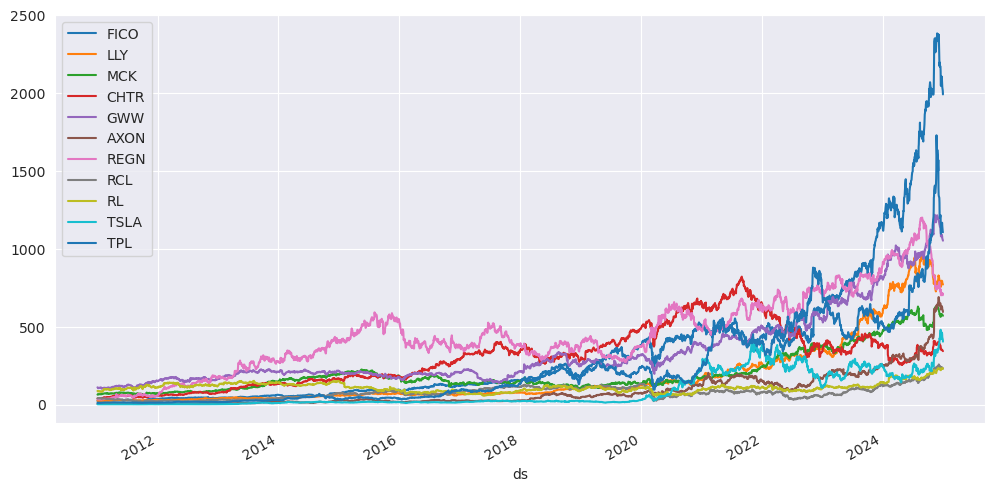

In [75]:
data_10 = source[select_10]
sns.set_style('darkgrid')
data_10.plot(figsize=(12,6))
plt.legend(loc='upper left')
plt.show()

In [76]:
df = data_10.copy()
days_to_avg = parameters['days_to_avg']
display(df.head())
print(f'initial date: {df.iloc[days_to_avg+1, :].index}')

Ticker,FICO,LLY,MCK,CHTR,GWW,AXON,REGN,RCL,RL,TSLA,TPL
ds,,,,,,,,,,,
2011-01-03,23.337875,24.383286,63.808739,38.459999,110.267799,5.00,33.776596,39.921806,87.635155,1.774667,10.710283
2011-01-04,22.812870,24.404190,64.355370,39.599998,110.022827,4.77,33.217312,40.473835,85.022339,1.778000,10.739388
2011-01-05,22.822775,24.230032,64.812325,39.570000,109.588188,4.88,33.247276,40.908760,84.975266,1.788667,10.704462
2011-01-06,22.902021,24.341486,67.079399,39.220001,105.621284,4.77,34.265968,40.030552,84.692795,1.858667,10.751030
2011-01-07,22.307678,24.313623,66.308769,39.180000,104.783623,4.79,34.056232,40.139271,83.766922,1.882667,10.748118


initial date: Index(['FICO', 'LLY', 'MCK', 'CHTR', 'GWW', 'AXON', 'REGN', 'RCL', 'RL',
       'TSLA', 'TPL'],
      dtype='object', name='Ticker')


In [77]:
df.iloc[days_to_avg+1:, :].index[0]

Timestamp('2011-02-16 00:00:00')

#### D-Wave Simulated Annealing

In [78]:
# Create D-Wave Classical Optimization Functions
opt_fun_dwave_sa = partial(dwave_classical_sharpe, 
                          sampler_type='simulated_annealing',
                          min_weight=0.01,
                          risk_aversion=0.5)

opt_fun_dwave_tabu = partial(dwave_classical_sharpe, 
                            sampler_type='tabu',
                            min_weight=0.01,
                            risk_aversion=0.5)

opt_fun_dwave_greedy = partial(dwave_classical_sharpe, 
                              sampler_type='steepest_descent',
                              min_weight=0.01,
                              risk_aversion=0.5)

print("D-Wave Classical Optimizers configured:")
print("- Simulated Annealing (SA): Best overall performance")
print("- Tabu Search: Good balance of quality and speed")  
print("- Steepest Descent (Greedy): Fastest execution")

D-Wave Classical Optimizers configured:
- Simulated Annealing (SA): Best overall performance
- Tabu Search: Good balance of quality and speed
- Steepest Descent (Greedy): Fastest execution


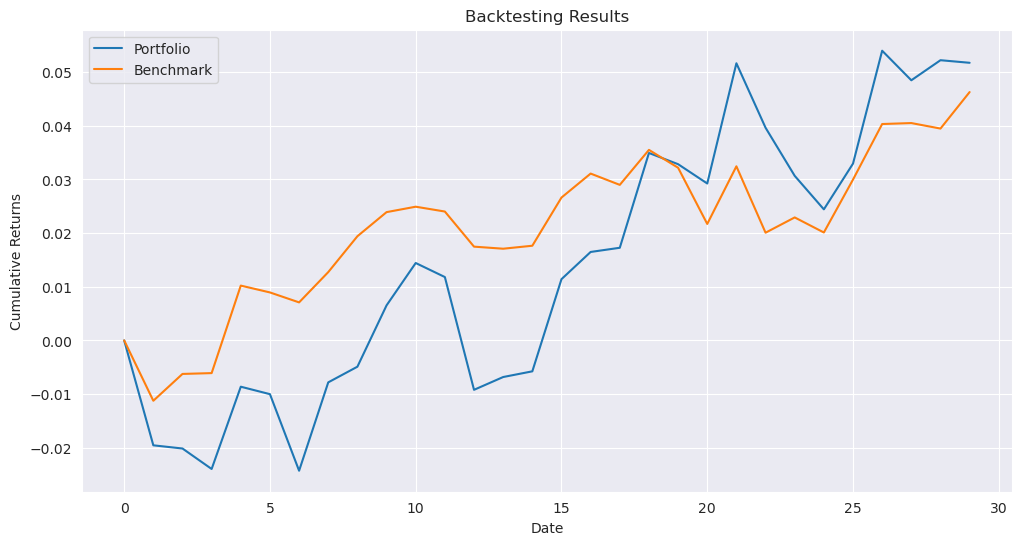

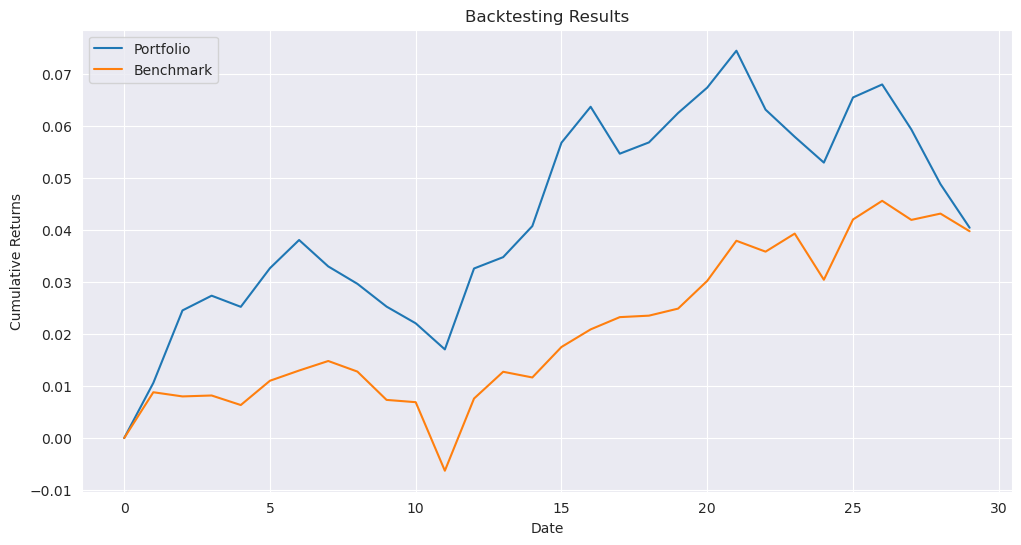

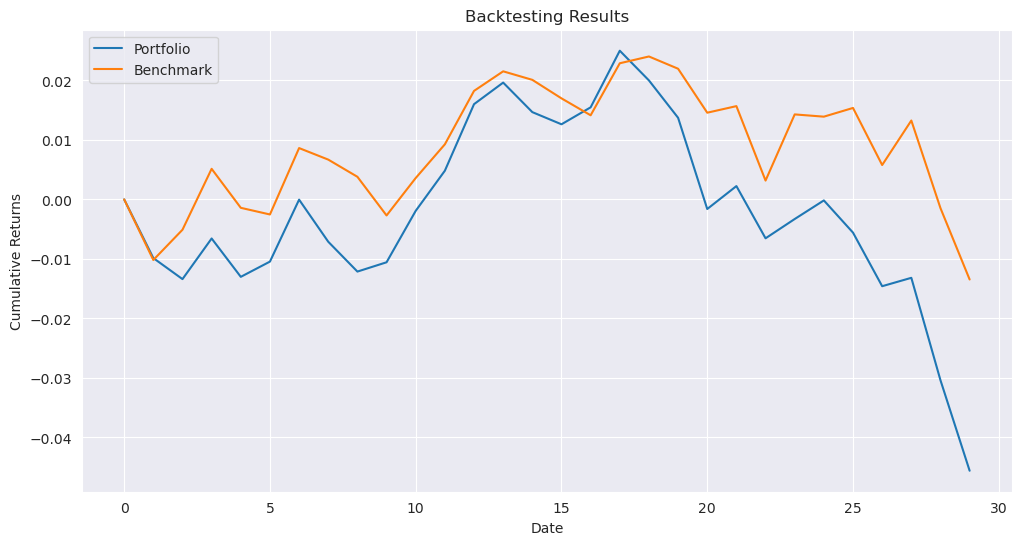

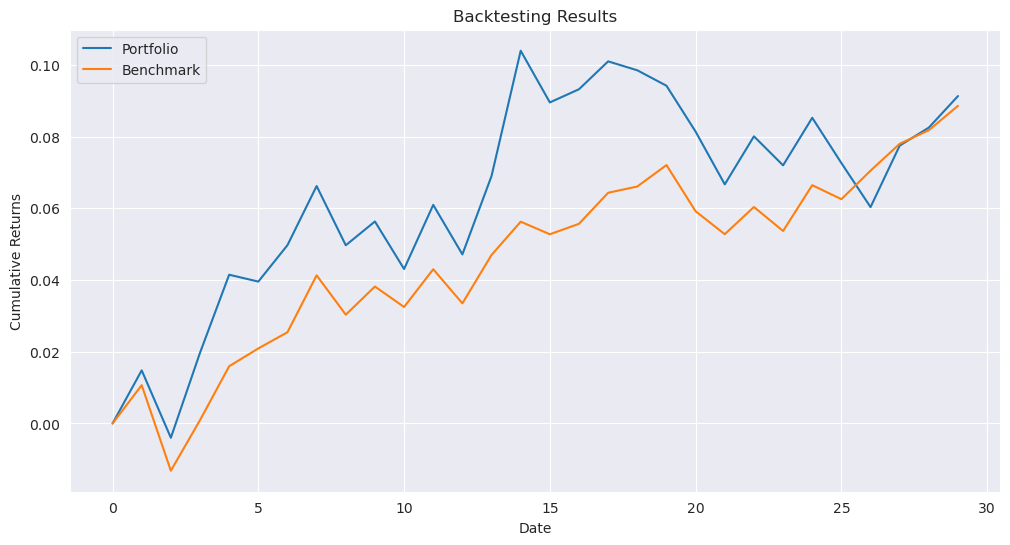

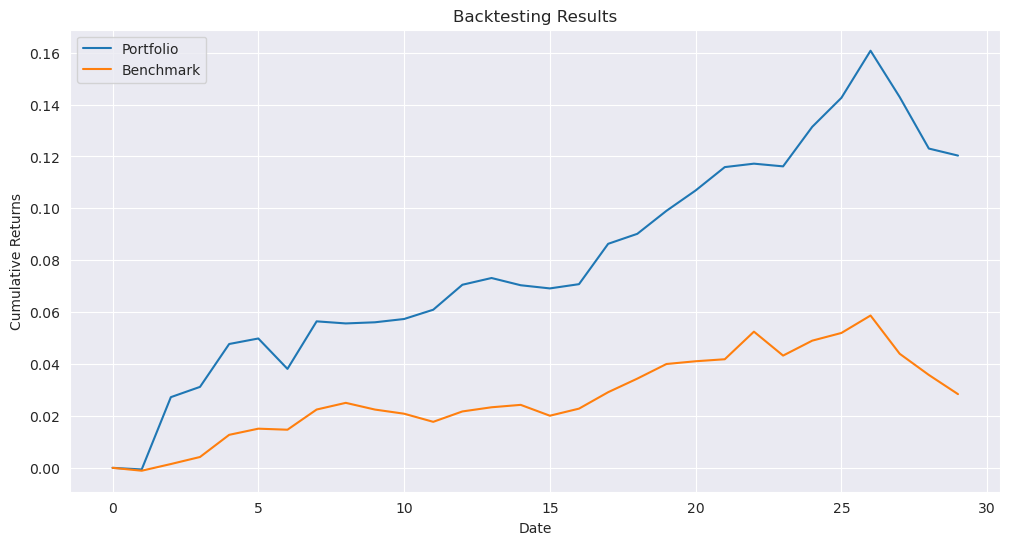

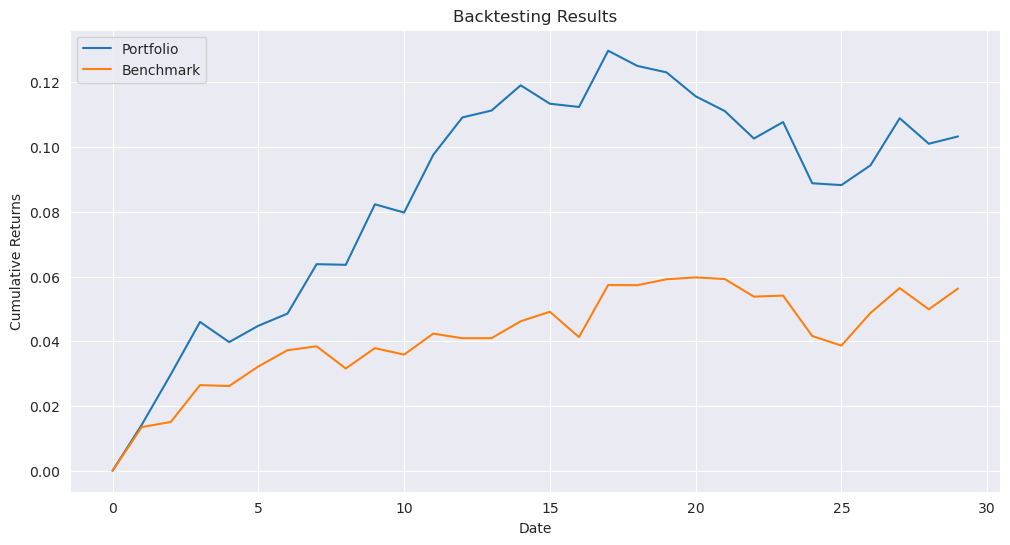

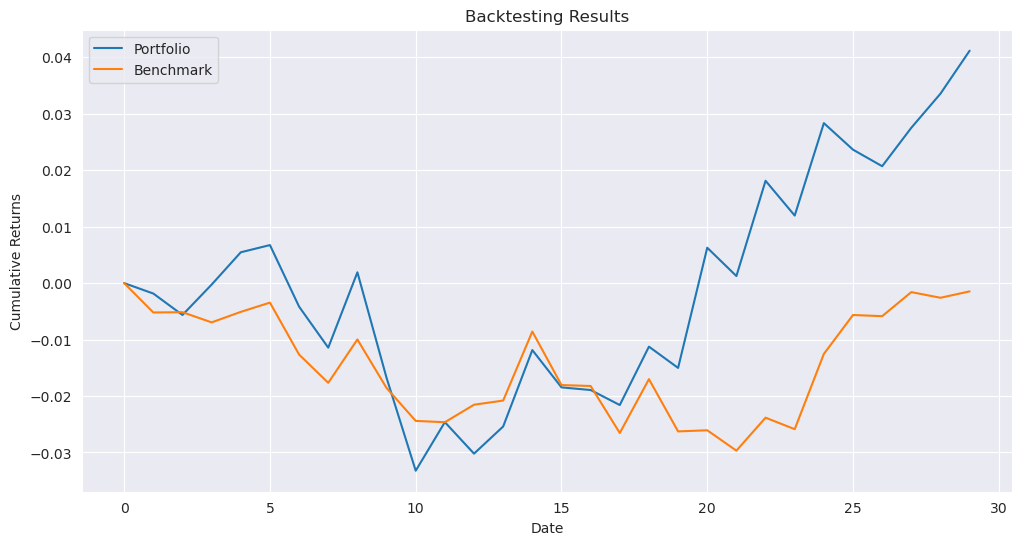

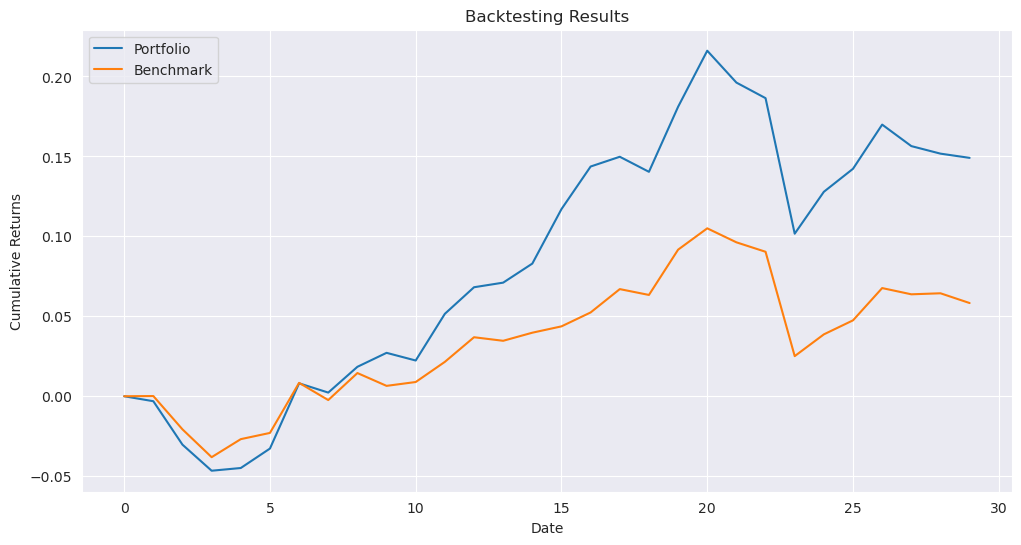

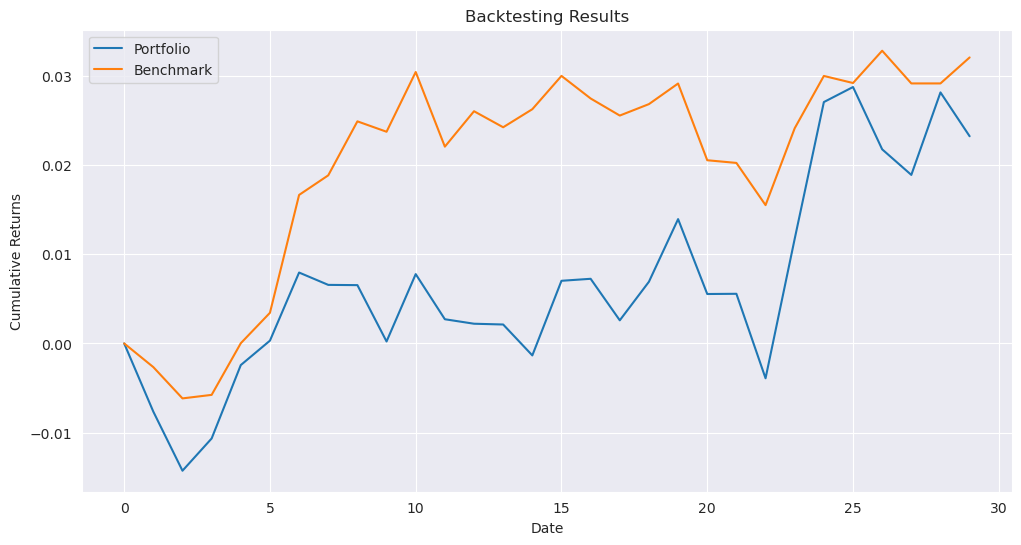

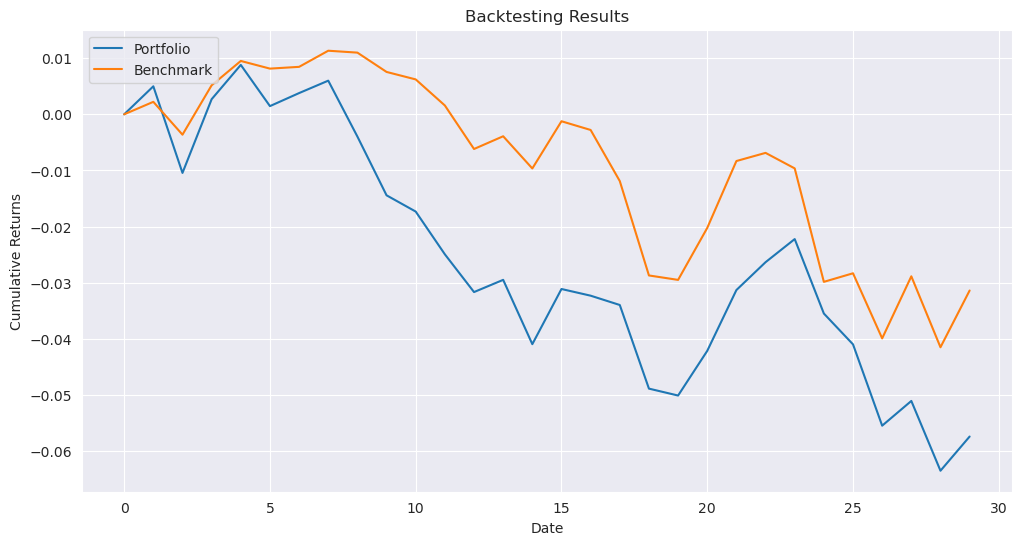

In [79]:
results_path_dwave_sa_10 = '../results/results_10_{}_dwave_sa.pkl'
_ = run_experiment(results_path_dwave_sa_10, data_10, benchmark, opt_fun_dwave_sa, parameters)

#### D-Wave Tabu Search

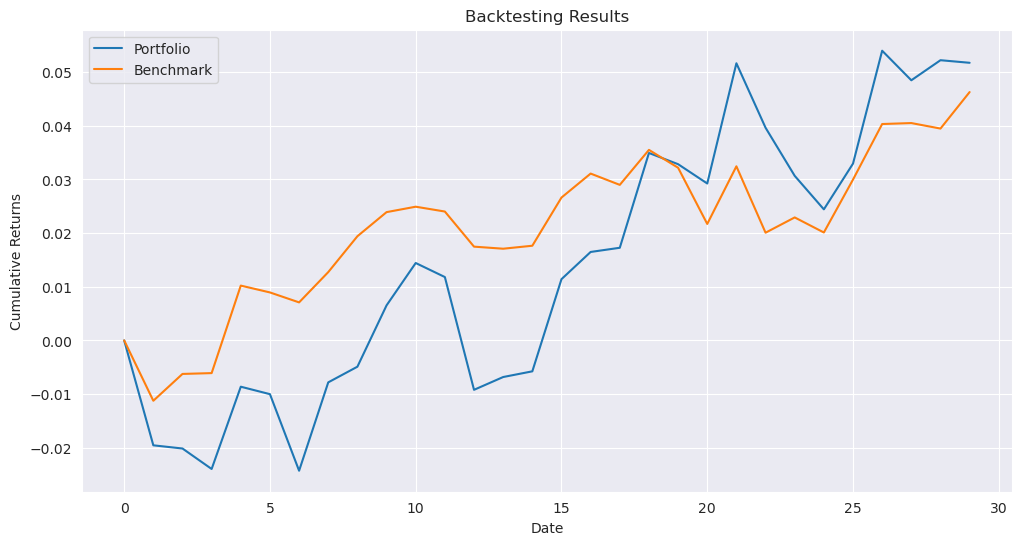

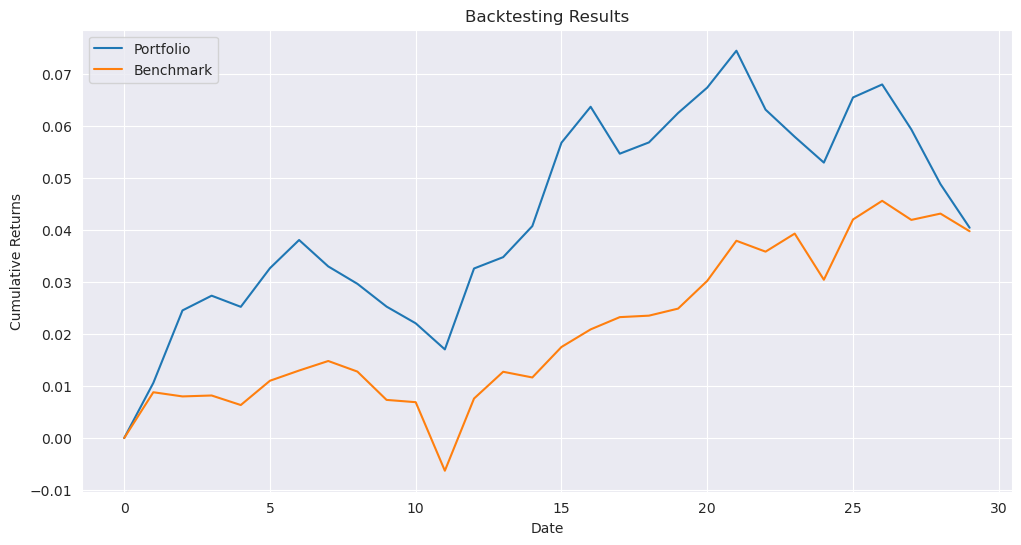

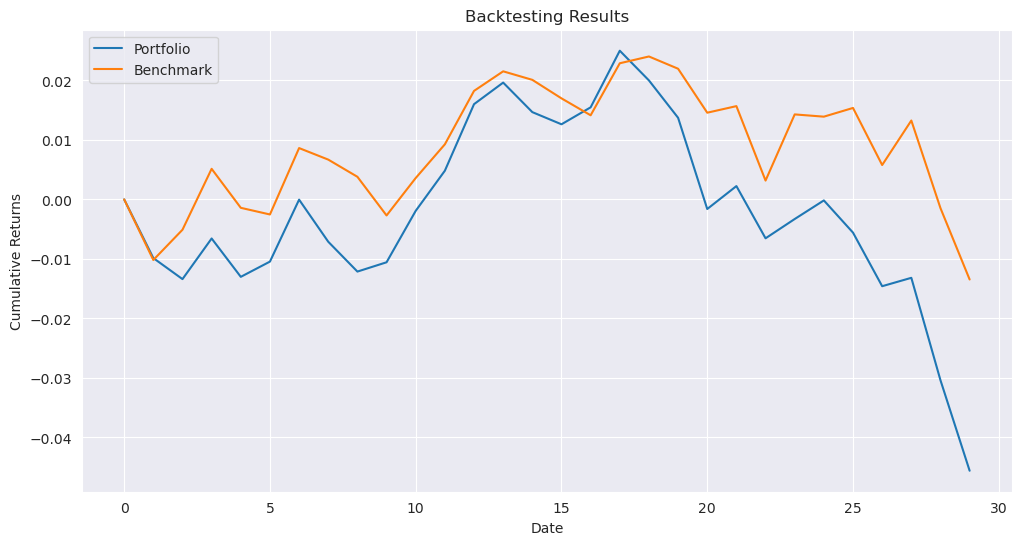

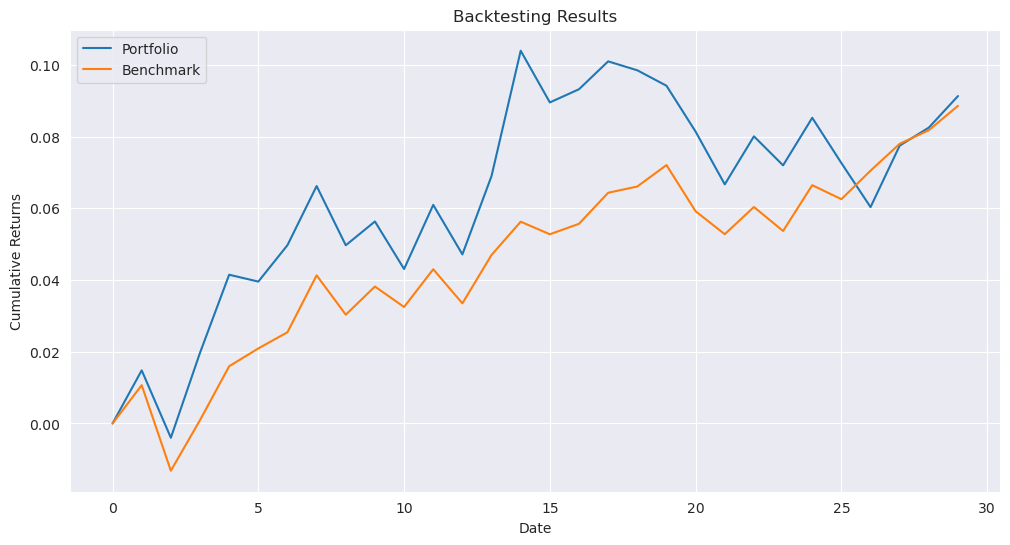

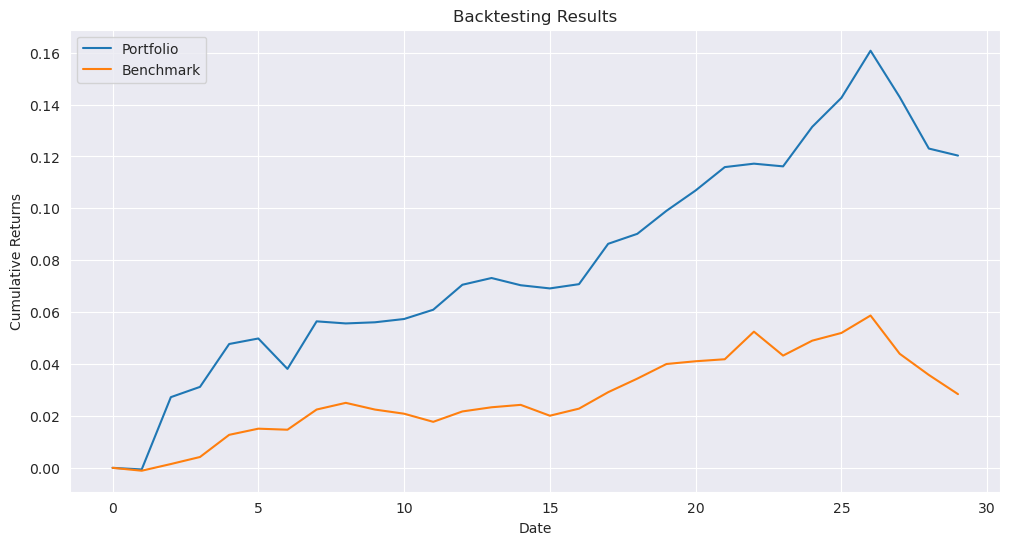

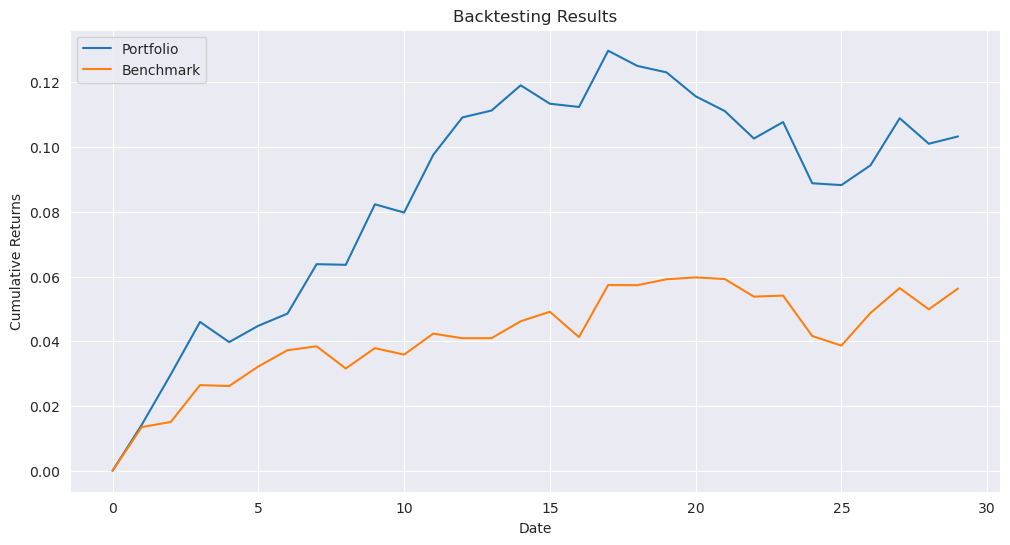

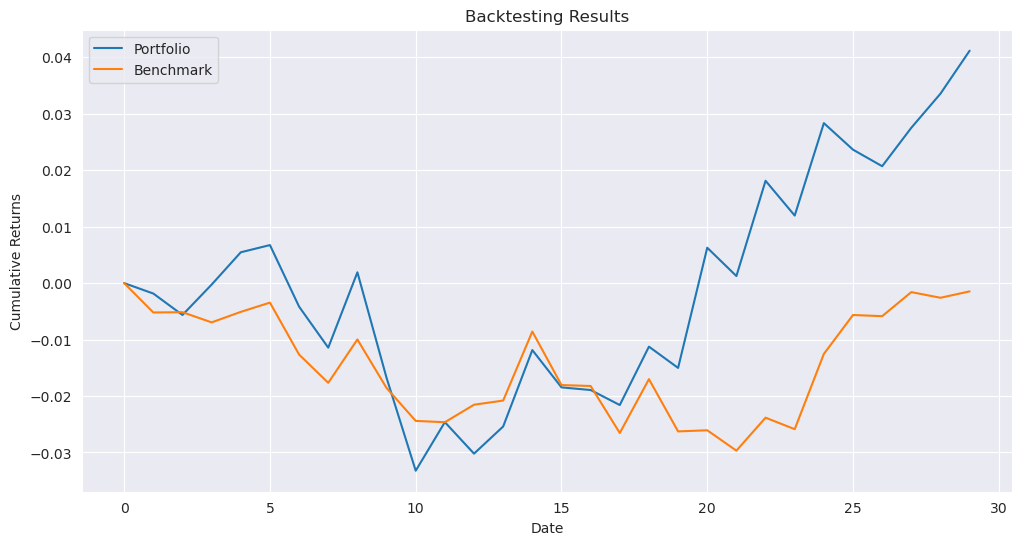

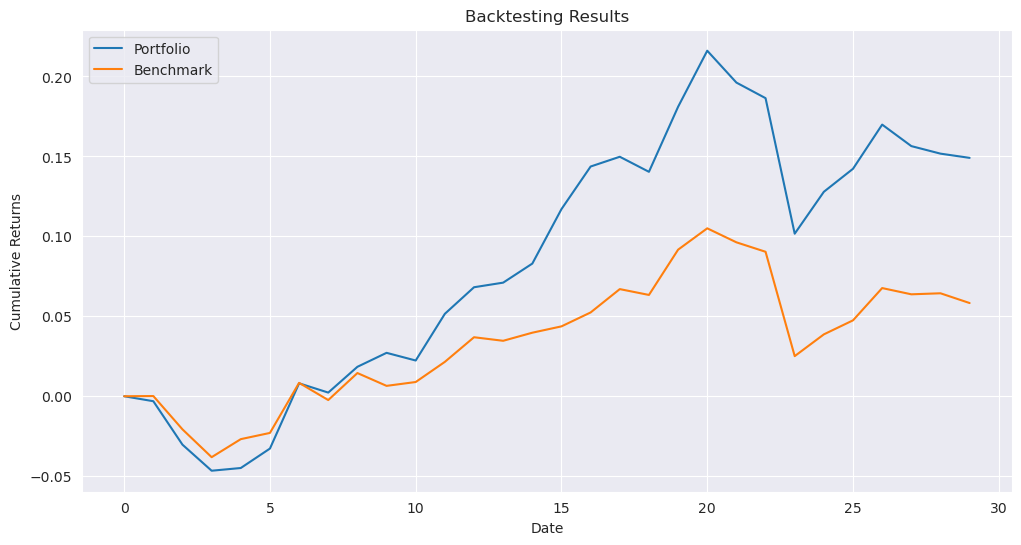

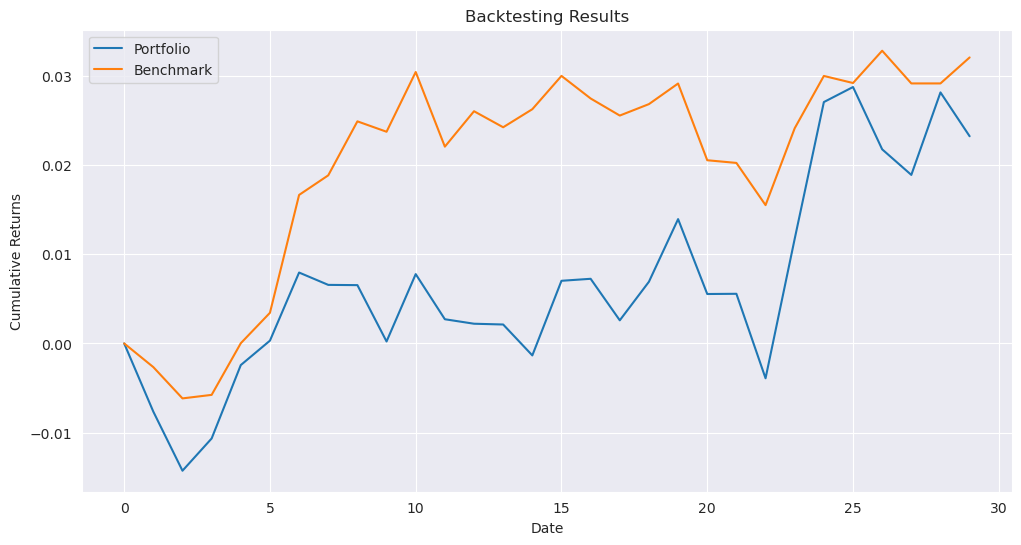

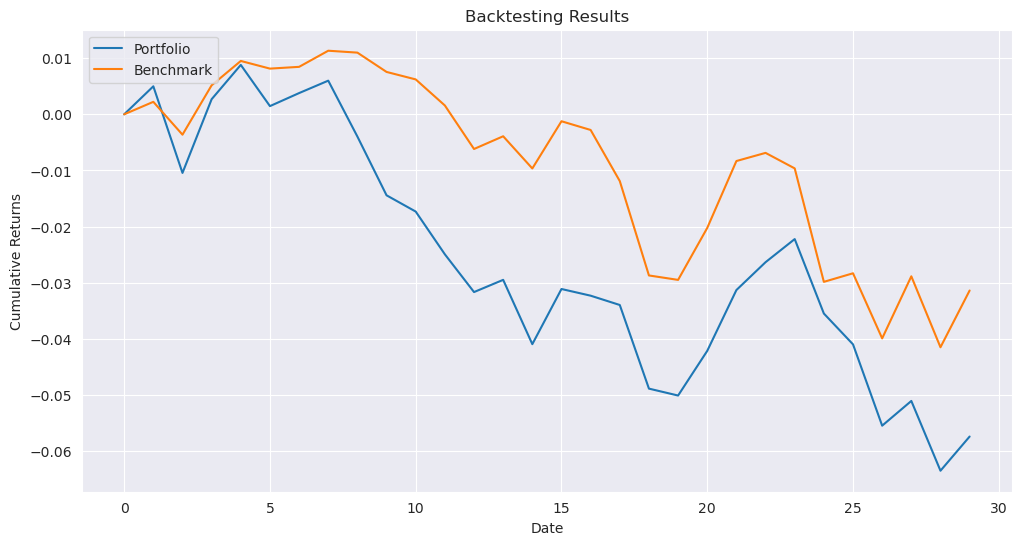

In [80]:
results_path_dwave_tabu_10 = '../results/results_10_{}_dwave_tabu.pkl'
_ = run_experiment(results_path_dwave_tabu_10, data_10, benchmark, opt_fun_dwave_tabu, parameters)

#### D-Wave Steepest Descent (Greedy)

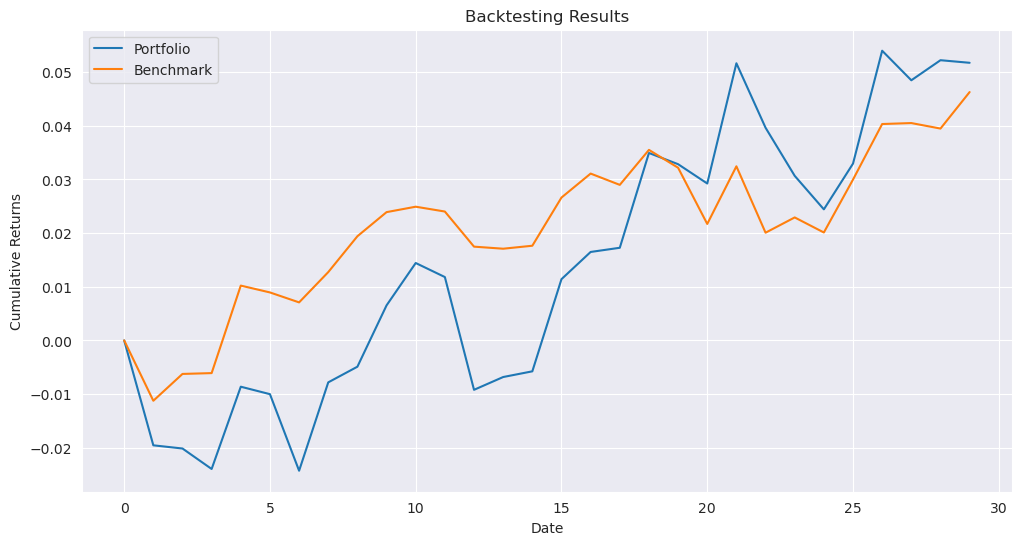

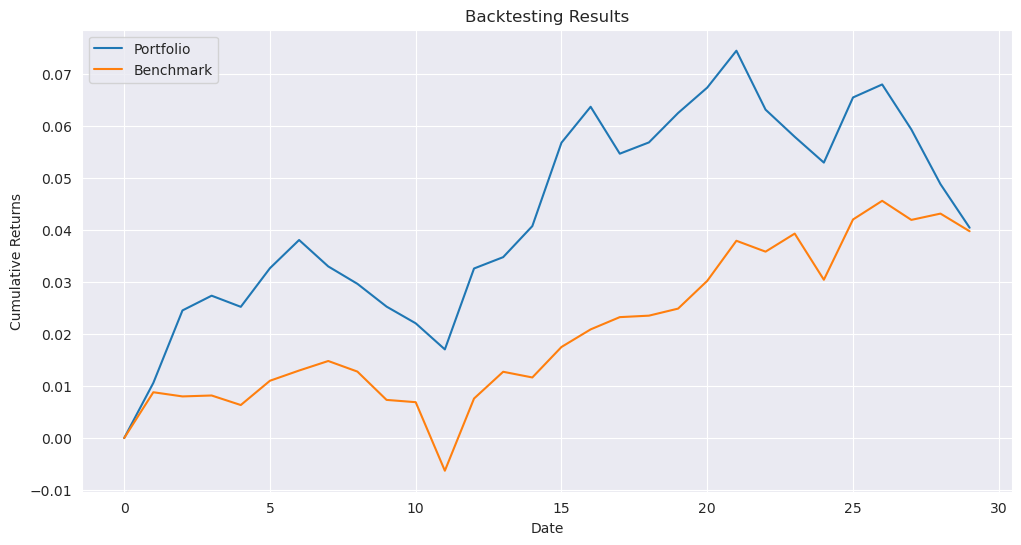

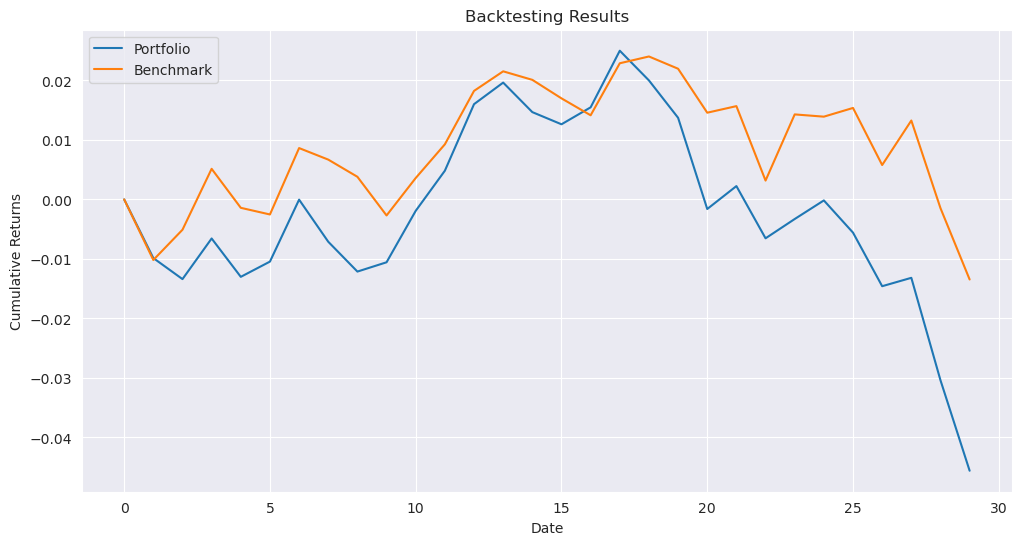

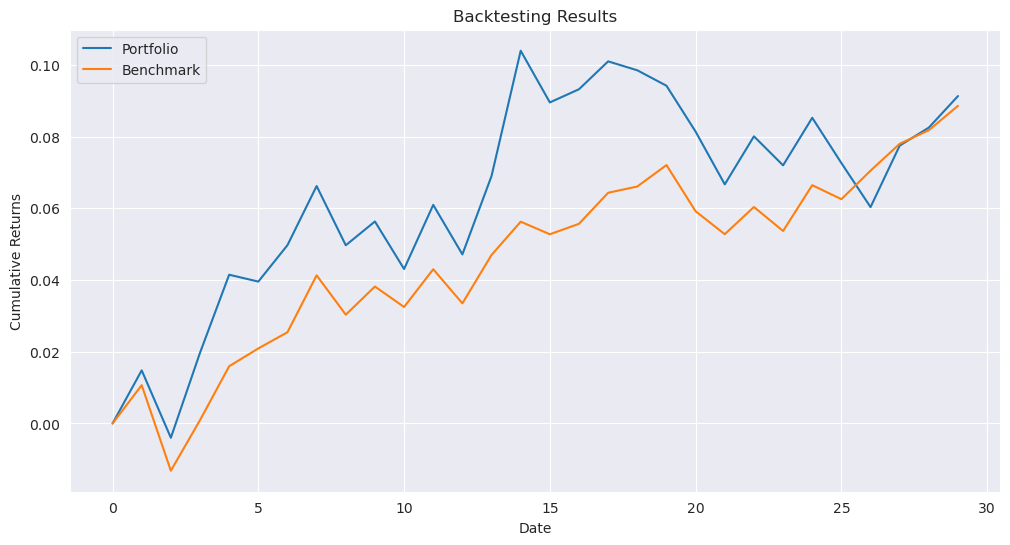

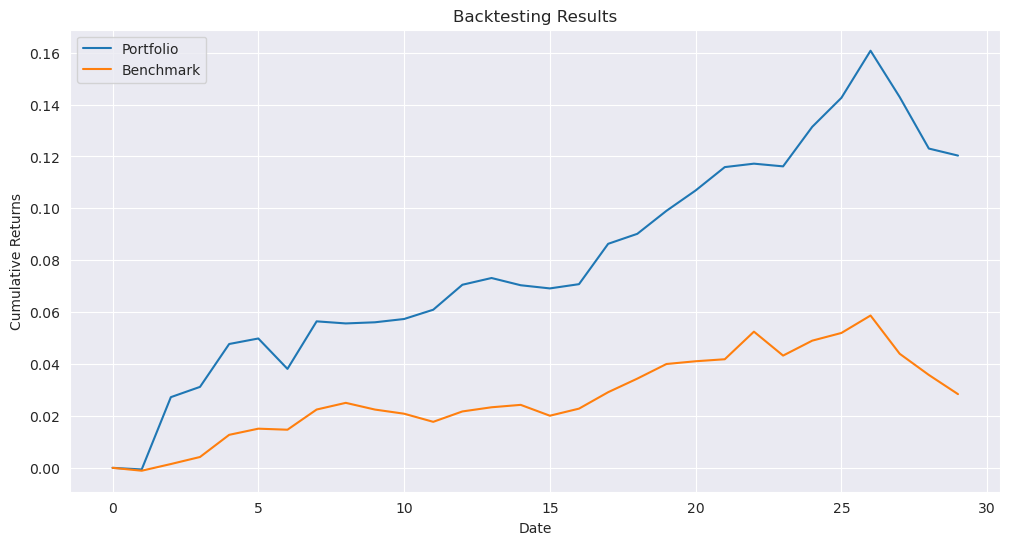

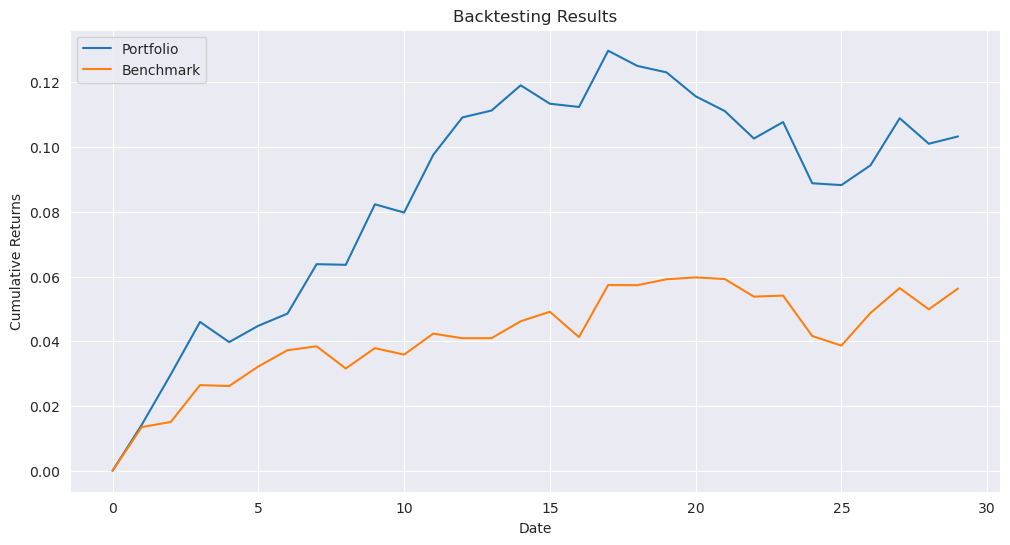

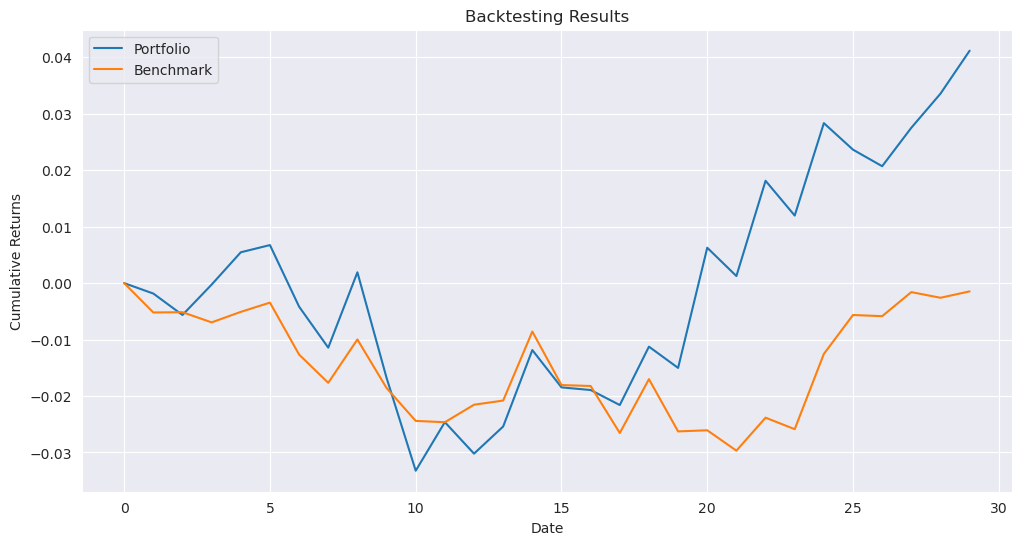

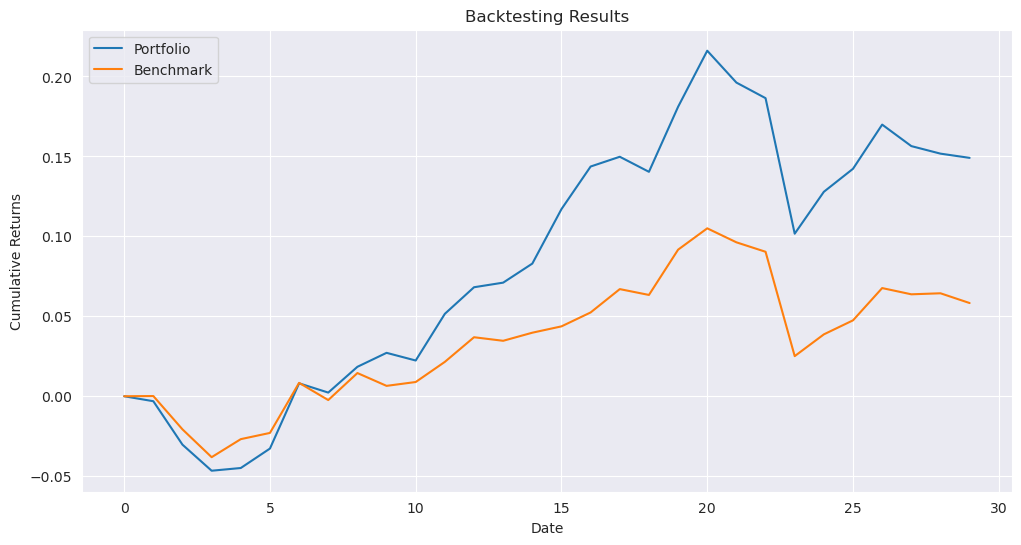

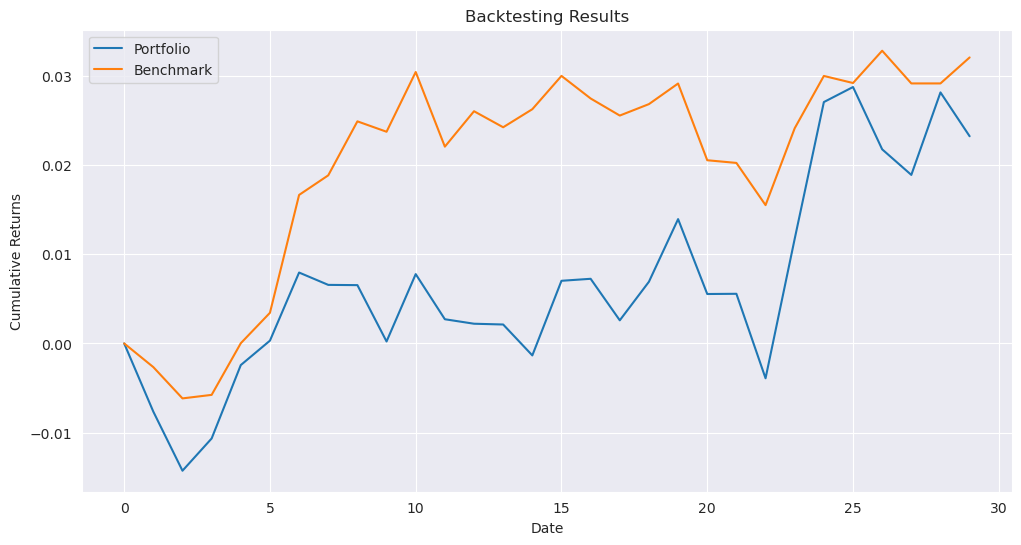

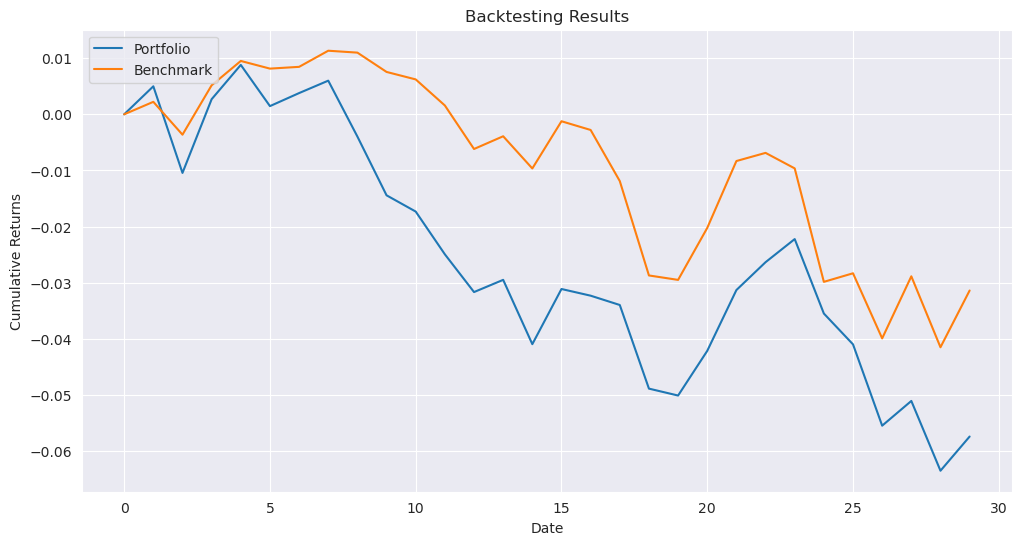

In [81]:
results_path_dwave_greedy_10 = '../results/results_10_{}_dwave_greedy.pkl'
_ = run_experiment(results_path_dwave_greedy_10, data_10, benchmark, opt_fun_dwave_greedy, parameters)

#### D-Wave Classical Samplers Comparison for 10 Stocks

2025-08-26 20:46:18,355 - inspect_results_logger - INFO - Period 0: Loaded D-Wave Simulated Annealing (exec_time: 9.29s)
INFO:inspect_results_logger:Period 0: Loaded D-Wave Simulated Annealing (exec_time: 9.29s)
2025-08-26 20:46:18,357 - inspect_results_logger - INFO - Period 0: Loaded D-Wave Tabu Search (exec_time: 63.79s)
INFO:inspect_results_logger:Period 0: Loaded D-Wave Tabu Search (exec_time: 63.79s)
2025-08-26 20:46:18,359 - inspect_results_logger - INFO - Period 0: Loaded D-Wave Steepest Descent (exec_time: 0.85s)
INFO:inspect_results_logger:Period 0: Loaded D-Wave Steepest Descent (exec_time: 0.85s)


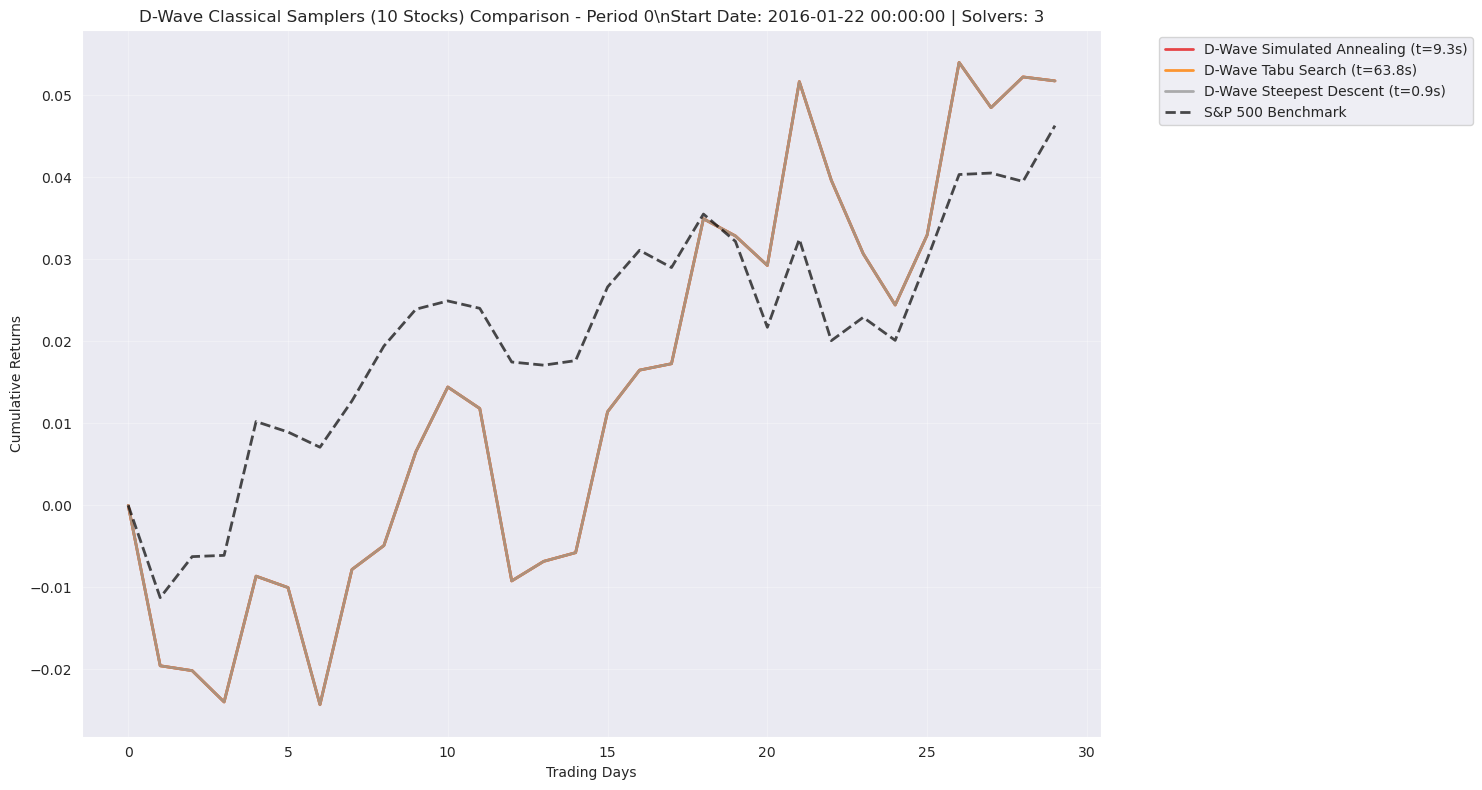

2025-08-26 20:46:18,479 - inspect_results_logger - INFO - Period 1: Loaded D-Wave Simulated Annealing (exec_time: 8.85s)
INFO:inspect_results_logger:Period 1: Loaded D-Wave Simulated Annealing (exec_time: 8.85s)
2025-08-26 20:46:18,481 - inspect_results_logger - INFO - Period 1: Loaded D-Wave Tabu Search (exec_time: 63.79s)
INFO:inspect_results_logger:Period 1: Loaded D-Wave Tabu Search (exec_time: 63.79s)
2025-08-26 20:46:18,483 - inspect_results_logger - INFO - Period 1: Loaded D-Wave Steepest Descent (exec_time: 0.77s)
INFO:inspect_results_logger:Period 1: Loaded D-Wave Steepest Descent (exec_time: 0.77s)


\nPeriod 0 Summary:
--------------------------------------------------
D-Wave Simulated Annealing:   0.0517 (  9.29s)
D-Wave Tabu Search       :   0.0517 ( 63.79s)
D-Wave Steepest Descent  :   0.0517 (  0.85s)
Benchmark                :   0.0463



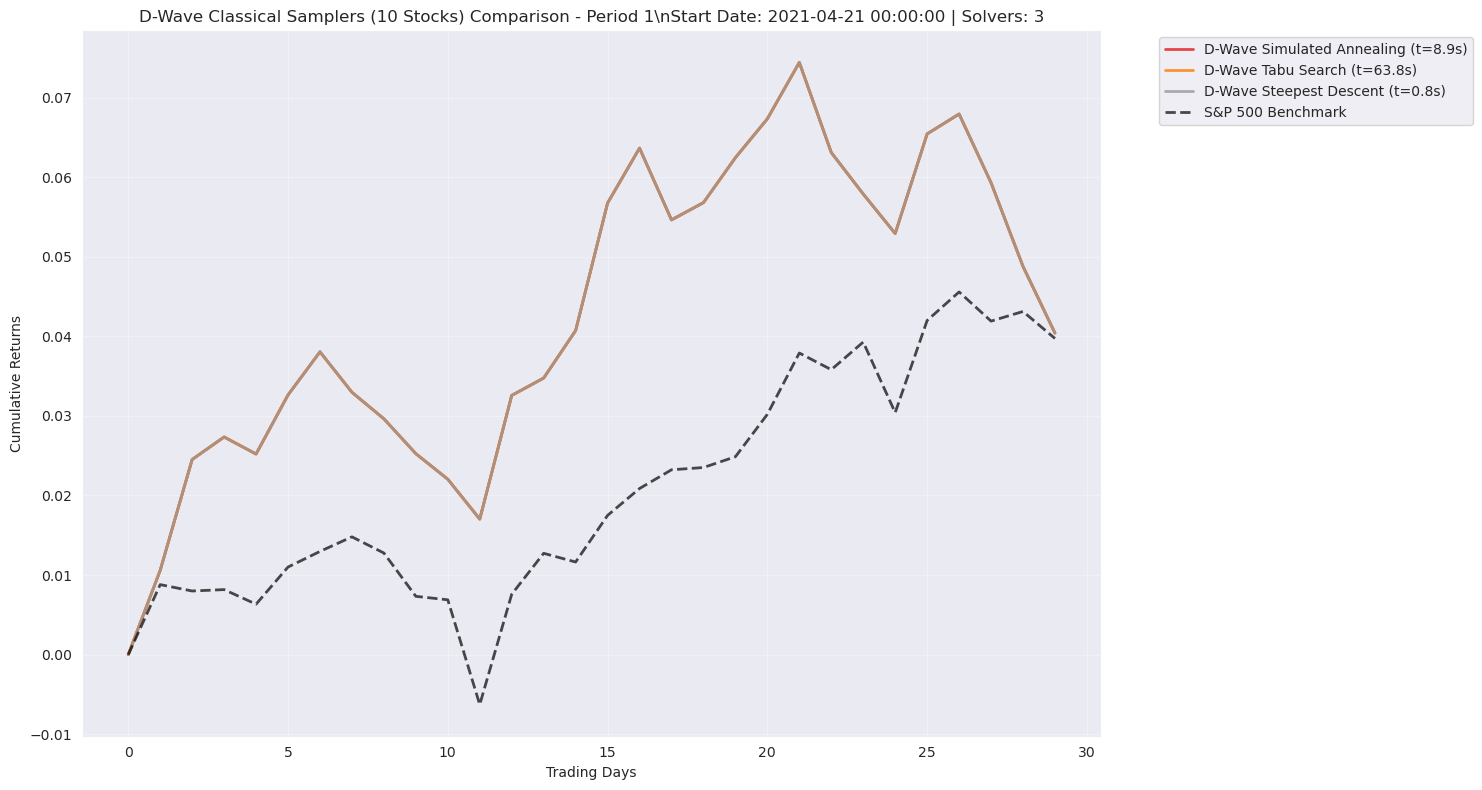

2025-08-26 20:46:18,598 - inspect_results_logger - INFO - Period 2: Loaded D-Wave Simulated Annealing (exec_time: 8.90s)
INFO:inspect_results_logger:Period 2: Loaded D-Wave Simulated Annealing (exec_time: 8.90s)
2025-08-26 20:46:18,599 - inspect_results_logger - INFO - Period 2: Loaded D-Wave Tabu Search (exec_time: 63.93s)
INFO:inspect_results_logger:Period 2: Loaded D-Wave Tabu Search (exec_time: 63.93s)
2025-08-26 20:46:18,599 - inspect_results_logger - INFO - Period 2: Loaded D-Wave Steepest Descent (exec_time: 0.77s)
INFO:inspect_results_logger:Period 2: Loaded D-Wave Steepest Descent (exec_time: 0.77s)


\nPeriod 1 Summary:
--------------------------------------------------
D-Wave Simulated Annealing:   0.0404 (  8.85s)
D-Wave Tabu Search       :   0.0404 ( 63.79s)
D-Wave Steepest Descent  :   0.0404 (  0.77s)
Benchmark                :   0.0397



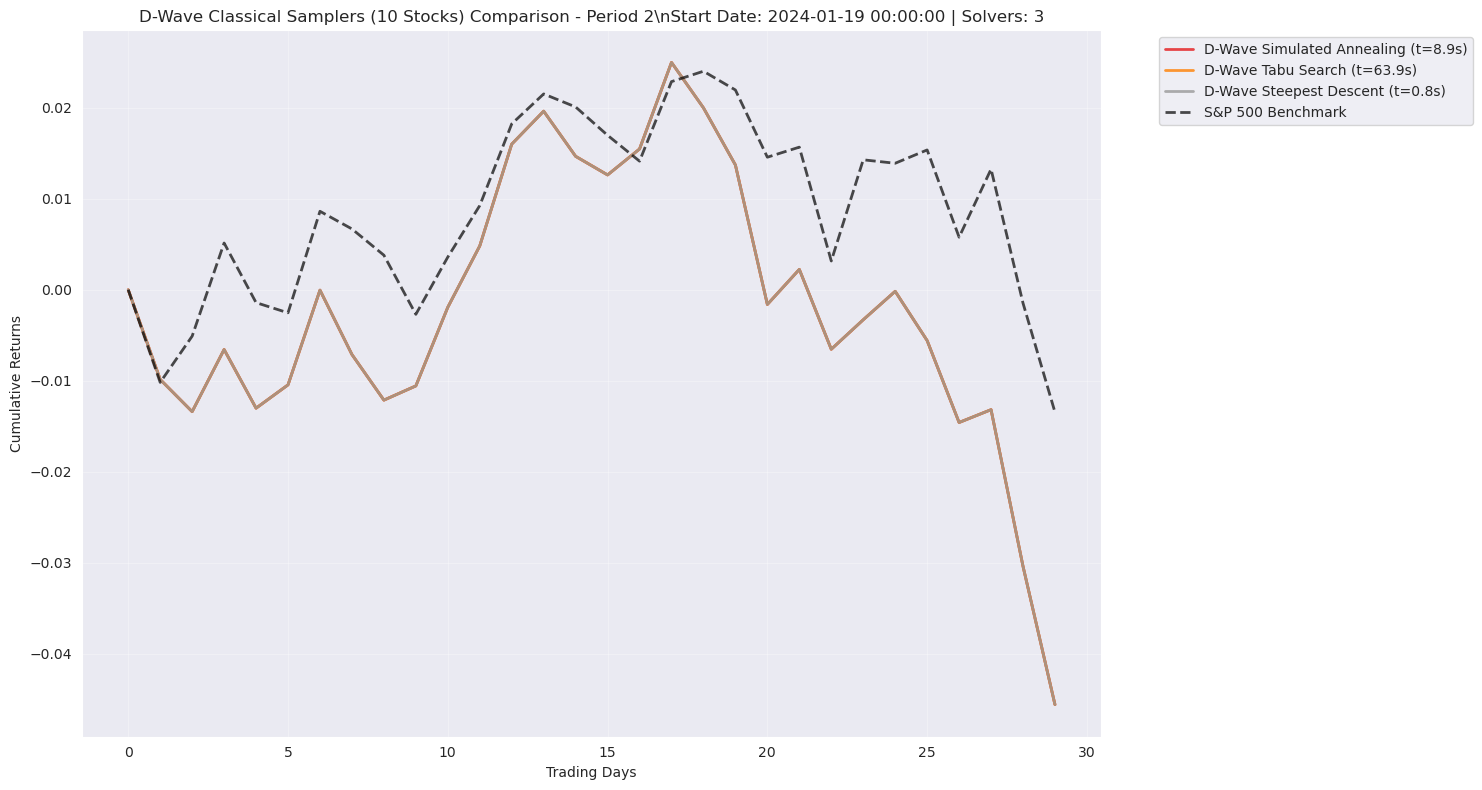

2025-08-26 20:46:18,708 - inspect_results_logger - INFO - Period 3: Loaded D-Wave Simulated Annealing (exec_time: 10.17s)
INFO:inspect_results_logger:Period 3: Loaded D-Wave Simulated Annealing (exec_time: 10.17s)
2025-08-26 20:46:18,710 - inspect_results_logger - INFO - Period 3: Loaded D-Wave Tabu Search (exec_time: 64.23s)
INFO:inspect_results_logger:Period 3: Loaded D-Wave Tabu Search (exec_time: 64.23s)
2025-08-26 20:46:18,711 - inspect_results_logger - INFO - Period 3: Loaded D-Wave Steepest Descent (exec_time: 1.03s)
INFO:inspect_results_logger:Period 3: Loaded D-Wave Steepest Descent (exec_time: 1.03s)


\nPeriod 2 Summary:
--------------------------------------------------
D-Wave Simulated Annealing:  -0.0456 (  8.90s)
D-Wave Tabu Search       :  -0.0456 ( 63.93s)
D-Wave Steepest Descent  :  -0.0456 (  0.77s)
Benchmark                :  -0.0135



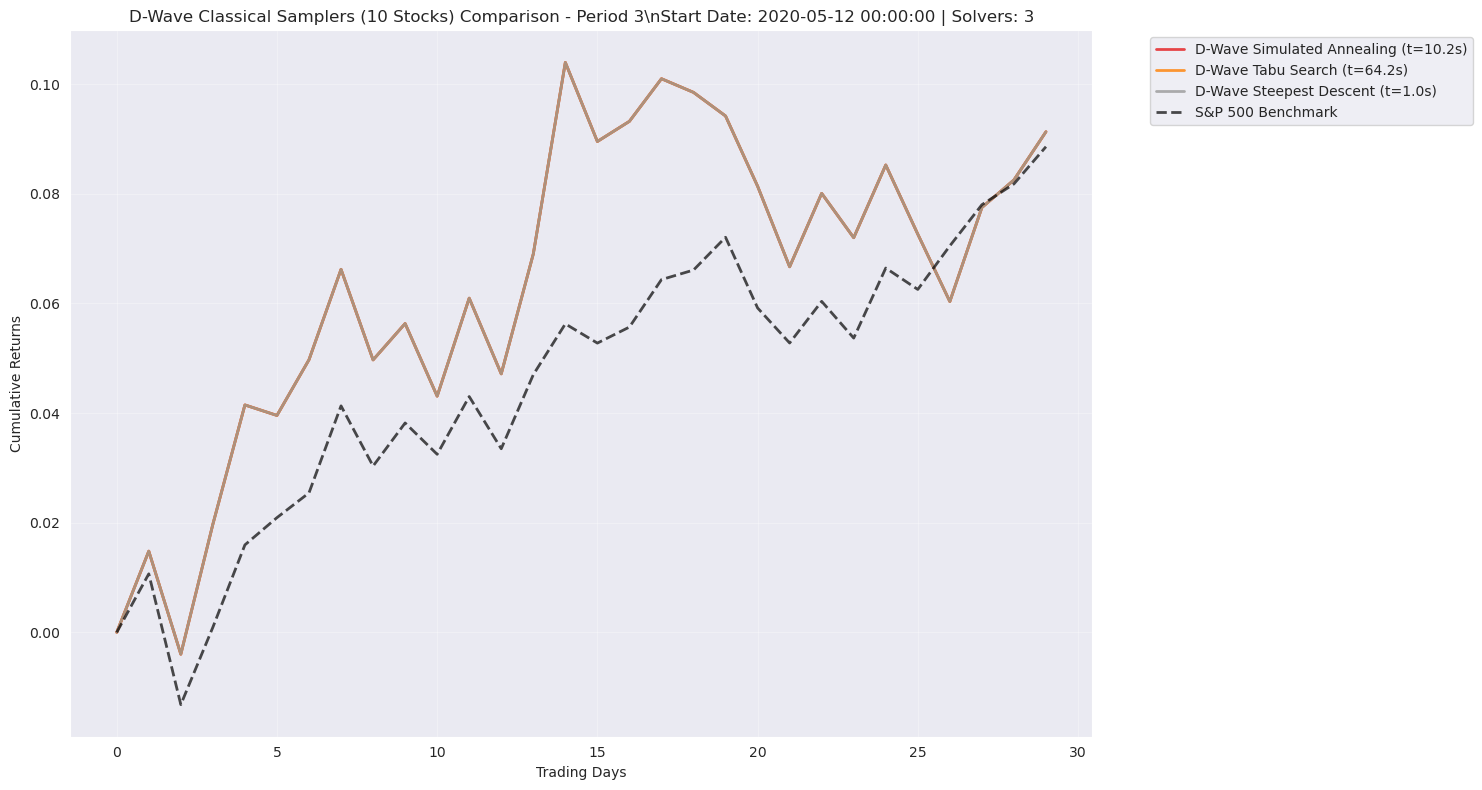

2025-08-26 20:46:18,824 - inspect_results_logger - INFO - Period 4: Loaded D-Wave Simulated Annealing (exec_time: 8.85s)
INFO:inspect_results_logger:Period 4: Loaded D-Wave Simulated Annealing (exec_time: 8.85s)
2025-08-26 20:46:18,824 - inspect_results_logger - INFO - Period 4: Loaded D-Wave Tabu Search (exec_time: 64.07s)
INFO:inspect_results_logger:Period 4: Loaded D-Wave Tabu Search (exec_time: 64.07s)
2025-08-26 20:46:18,825 - inspect_results_logger - INFO - Period 4: Loaded D-Wave Steepest Descent (exec_time: 1.21s)
INFO:inspect_results_logger:Period 4: Loaded D-Wave Steepest Descent (exec_time: 1.21s)


\nPeriod 3 Summary:
--------------------------------------------------
D-Wave Simulated Annealing:   0.0913 ( 10.17s)
D-Wave Tabu Search       :   0.0913 ( 64.23s)
D-Wave Steepest Descent  :   0.0913 (  1.03s)
Benchmark                :   0.0886



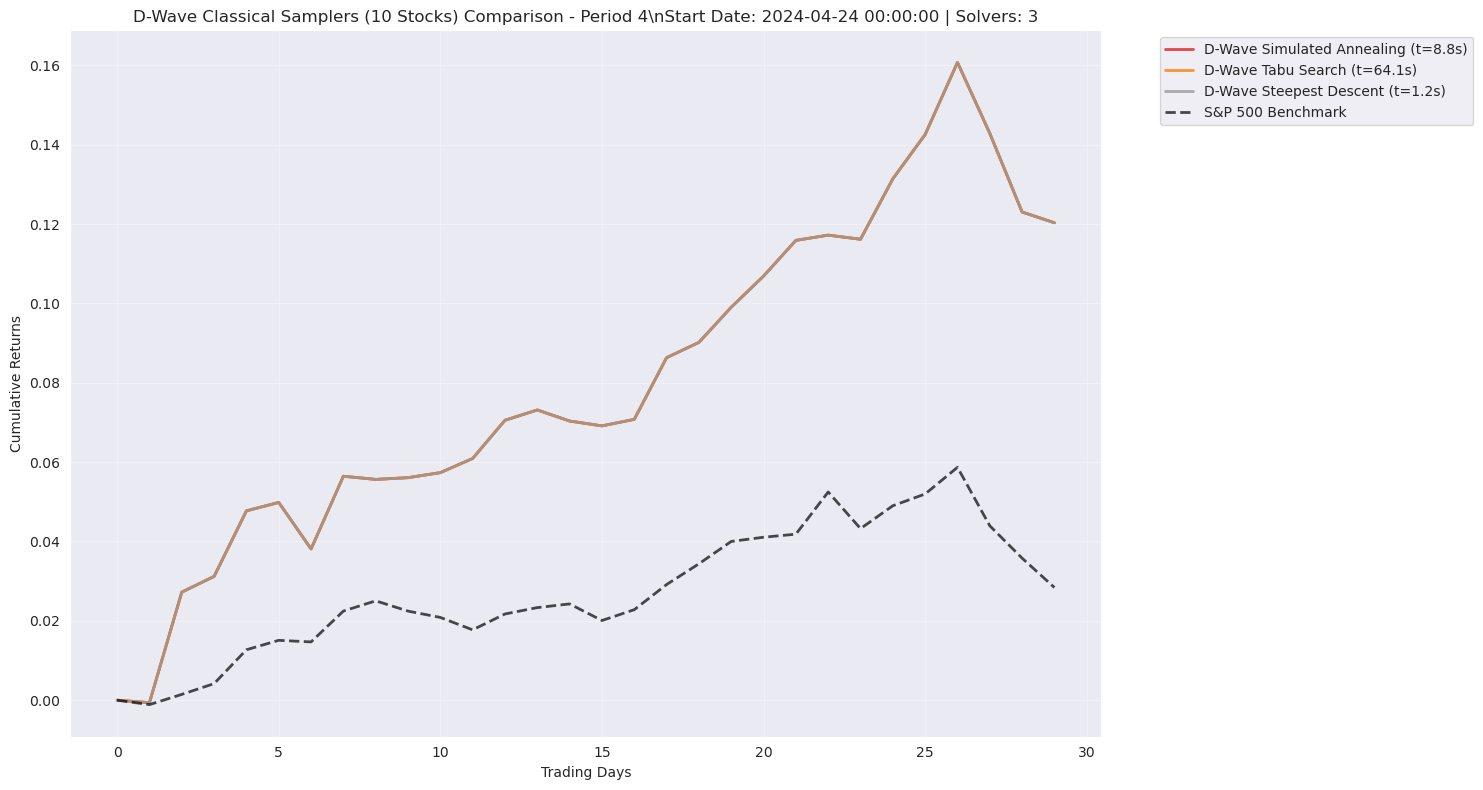

2025-08-26 20:46:18,933 - inspect_results_logger - INFO - Period 5: Loaded D-Wave Simulated Annealing (exec_time: 8.01s)
INFO:inspect_results_logger:Period 5: Loaded D-Wave Simulated Annealing (exec_time: 8.01s)
2025-08-26 20:46:18,935 - inspect_results_logger - INFO - Period 5: Loaded D-Wave Tabu Search (exec_time: 64.20s)
INFO:inspect_results_logger:Period 5: Loaded D-Wave Tabu Search (exec_time: 64.20s)
2025-08-26 20:46:18,937 - inspect_results_logger - INFO - Period 5: Loaded D-Wave Steepest Descent (exec_time: 1.10s)
INFO:inspect_results_logger:Period 5: Loaded D-Wave Steepest Descent (exec_time: 1.10s)


\nPeriod 4 Summary:
--------------------------------------------------
D-Wave Simulated Annealing:   0.1203 (  8.85s)
D-Wave Tabu Search       :   0.1203 ( 64.07s)
D-Wave Steepest Descent  :   0.1203 (  1.21s)
Benchmark                :   0.0284



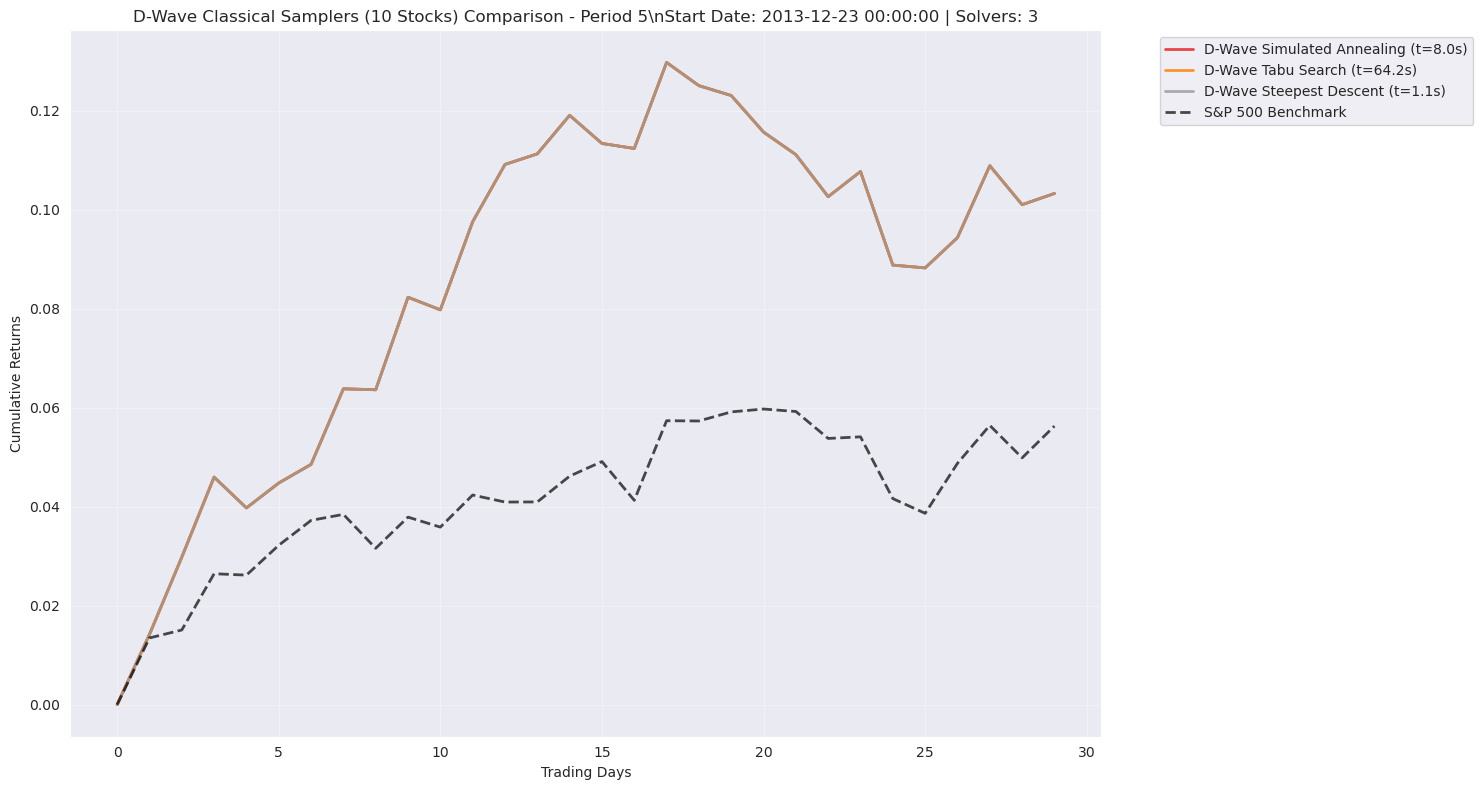

2025-08-26 20:46:19,048 - inspect_results_logger - INFO - Period 6: Loaded D-Wave Simulated Annealing (exec_time: 7.10s)
INFO:inspect_results_logger:Period 6: Loaded D-Wave Simulated Annealing (exec_time: 7.10s)
2025-08-26 20:46:19,049 - inspect_results_logger - INFO - Period 6: Loaded D-Wave Tabu Search (exec_time: 63.81s)
INFO:inspect_results_logger:Period 6: Loaded D-Wave Tabu Search (exec_time: 63.81s)
2025-08-26 20:46:19,050 - inspect_results_logger - INFO - Period 6: Loaded D-Wave Steepest Descent (exec_time: 0.80s)
INFO:inspect_results_logger:Period 6: Loaded D-Wave Steepest Descent (exec_time: 0.80s)


\nPeriod 5 Summary:
--------------------------------------------------
D-Wave Simulated Annealing:   0.1033 (  8.01s)
D-Wave Tabu Search       :   0.1033 ( 64.20s)
D-Wave Steepest Descent  :   0.1033 (  1.10s)
Benchmark                :   0.0563



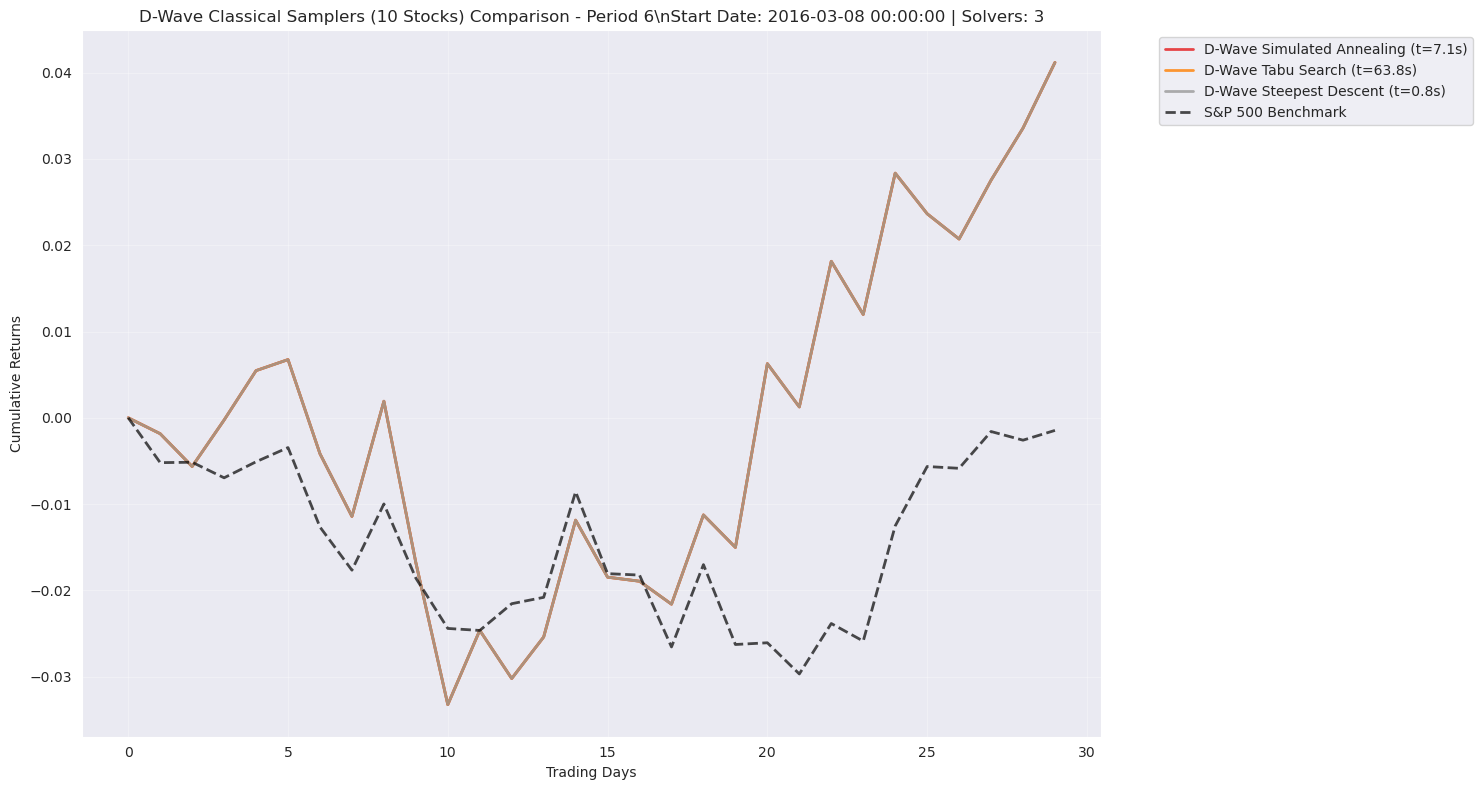

2025-08-26 20:46:19,159 - inspect_results_logger - INFO - Period 7: Loaded D-Wave Simulated Annealing (exec_time: 7.58s)
INFO:inspect_results_logger:Period 7: Loaded D-Wave Simulated Annealing (exec_time: 7.58s)
2025-08-26 20:46:19,159 - inspect_results_logger - INFO - Period 7: Loaded D-Wave Tabu Search (exec_time: 63.80s)
INFO:inspect_results_logger:Period 7: Loaded D-Wave Tabu Search (exec_time: 63.80s)
2025-08-26 20:46:19,160 - inspect_results_logger - INFO - Period 7: Loaded D-Wave Steepest Descent (exec_time: 0.91s)
INFO:inspect_results_logger:Period 7: Loaded D-Wave Steepest Descent (exec_time: 0.91s)


\nPeriod 6 Summary:
--------------------------------------------------
D-Wave Simulated Annealing:   0.0412 (  7.10s)
D-Wave Tabu Search       :   0.0412 ( 63.81s)
D-Wave Steepest Descent  :   0.0412 (  0.80s)
Benchmark                :  -0.0015



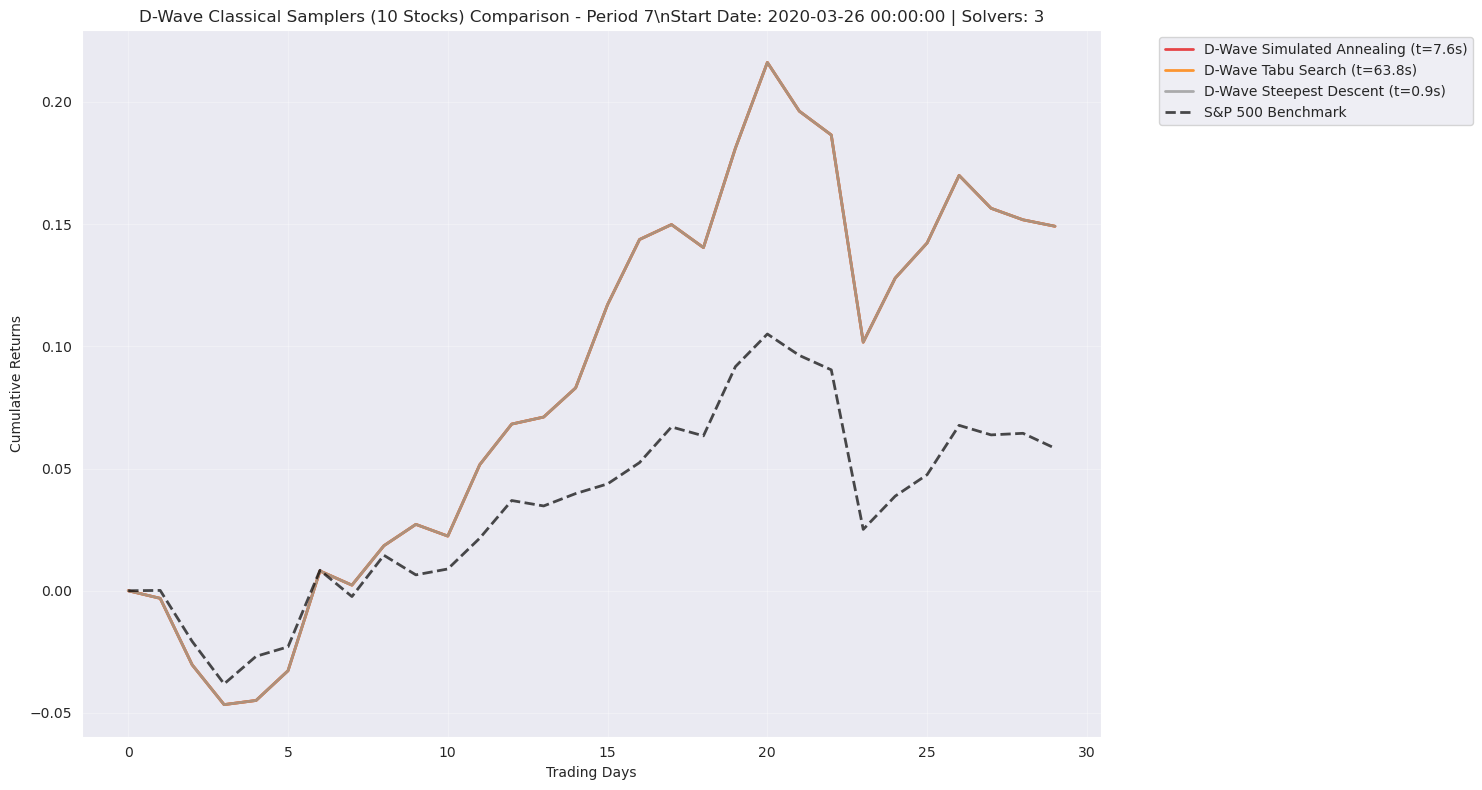

2025-08-26 20:46:19,265 - inspect_results_logger - INFO - Period 8: Loaded D-Wave Simulated Annealing (exec_time: 6.84s)
INFO:inspect_results_logger:Period 8: Loaded D-Wave Simulated Annealing (exec_time: 6.84s)
2025-08-26 20:46:19,266 - inspect_results_logger - INFO - Period 8: Loaded D-Wave Tabu Search (exec_time: 63.88s)
INFO:inspect_results_logger:Period 8: Loaded D-Wave Tabu Search (exec_time: 63.88s)
2025-08-26 20:46:19,267 - inspect_results_logger - INFO - Period 8: Loaded D-Wave Steepest Descent (exec_time: 1.17s)
INFO:inspect_results_logger:Period 8: Loaded D-Wave Steepest Descent (exec_time: 1.17s)


\nPeriod 7 Summary:
--------------------------------------------------
D-Wave Simulated Annealing:   0.1491 (  7.58s)
D-Wave Tabu Search       :   0.1491 ( 63.80s)
D-Wave Steepest Descent  :   0.1491 (  0.91s)
Benchmark                :   0.0583



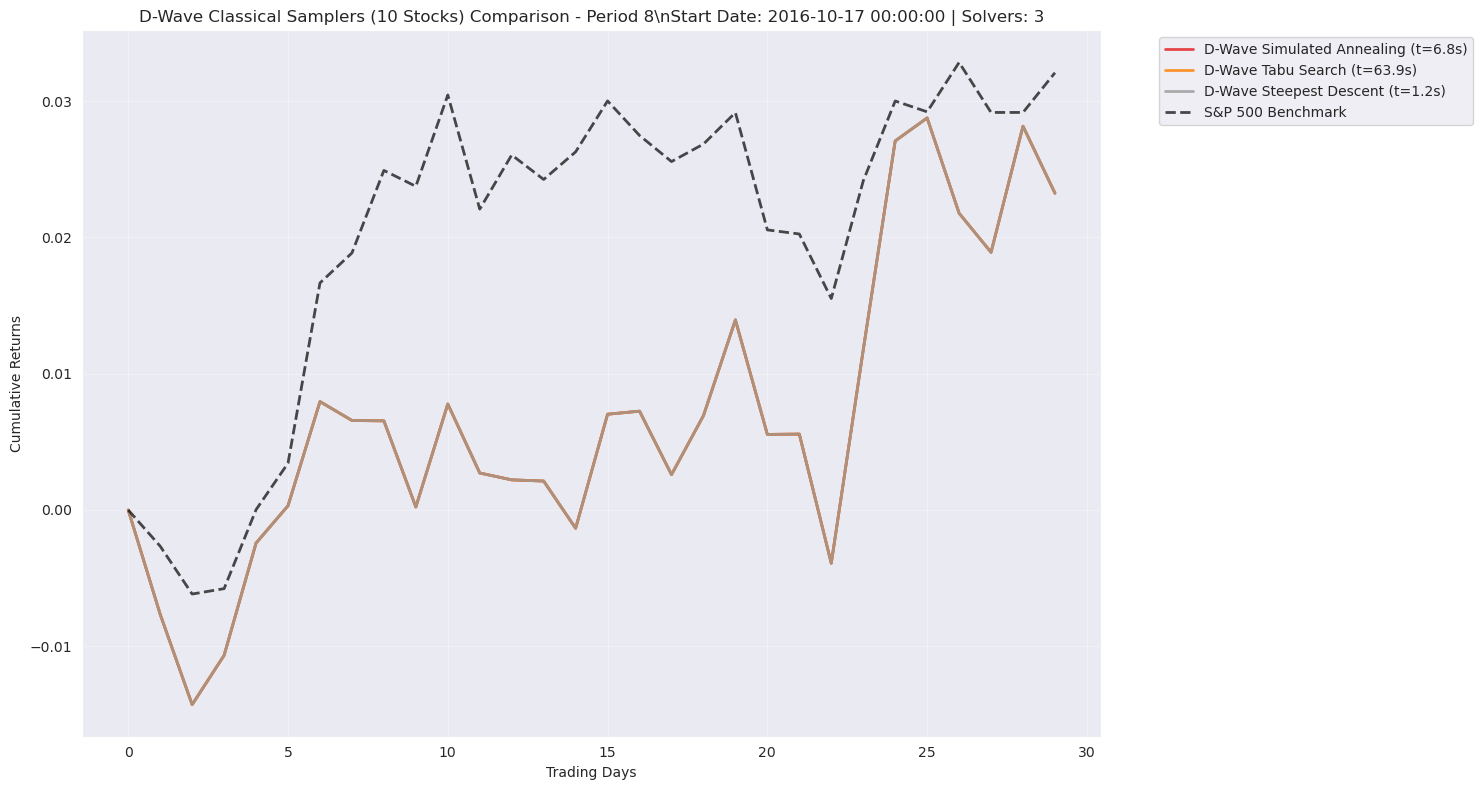

2025-08-26 20:46:19,374 - inspect_results_logger - INFO - Period 9: Loaded D-Wave Simulated Annealing (exec_time: 6.88s)
INFO:inspect_results_logger:Period 9: Loaded D-Wave Simulated Annealing (exec_time: 6.88s)
2025-08-26 20:46:19,375 - inspect_results_logger - INFO - Period 9: Loaded D-Wave Tabu Search (exec_time: 63.82s)
INFO:inspect_results_logger:Period 9: Loaded D-Wave Tabu Search (exec_time: 63.82s)
2025-08-26 20:46:19,375 - inspect_results_logger - INFO - Period 9: Loaded D-Wave Steepest Descent (exec_time: 1.18s)
INFO:inspect_results_logger:Period 9: Loaded D-Wave Steepest Descent (exec_time: 1.18s)


\nPeriod 8 Summary:
--------------------------------------------------
D-Wave Simulated Annealing:   0.0232 (  6.84s)
D-Wave Tabu Search       :   0.0232 ( 63.88s)
D-Wave Steepest Descent  :   0.0232 (  1.17s)
Benchmark                :   0.0321



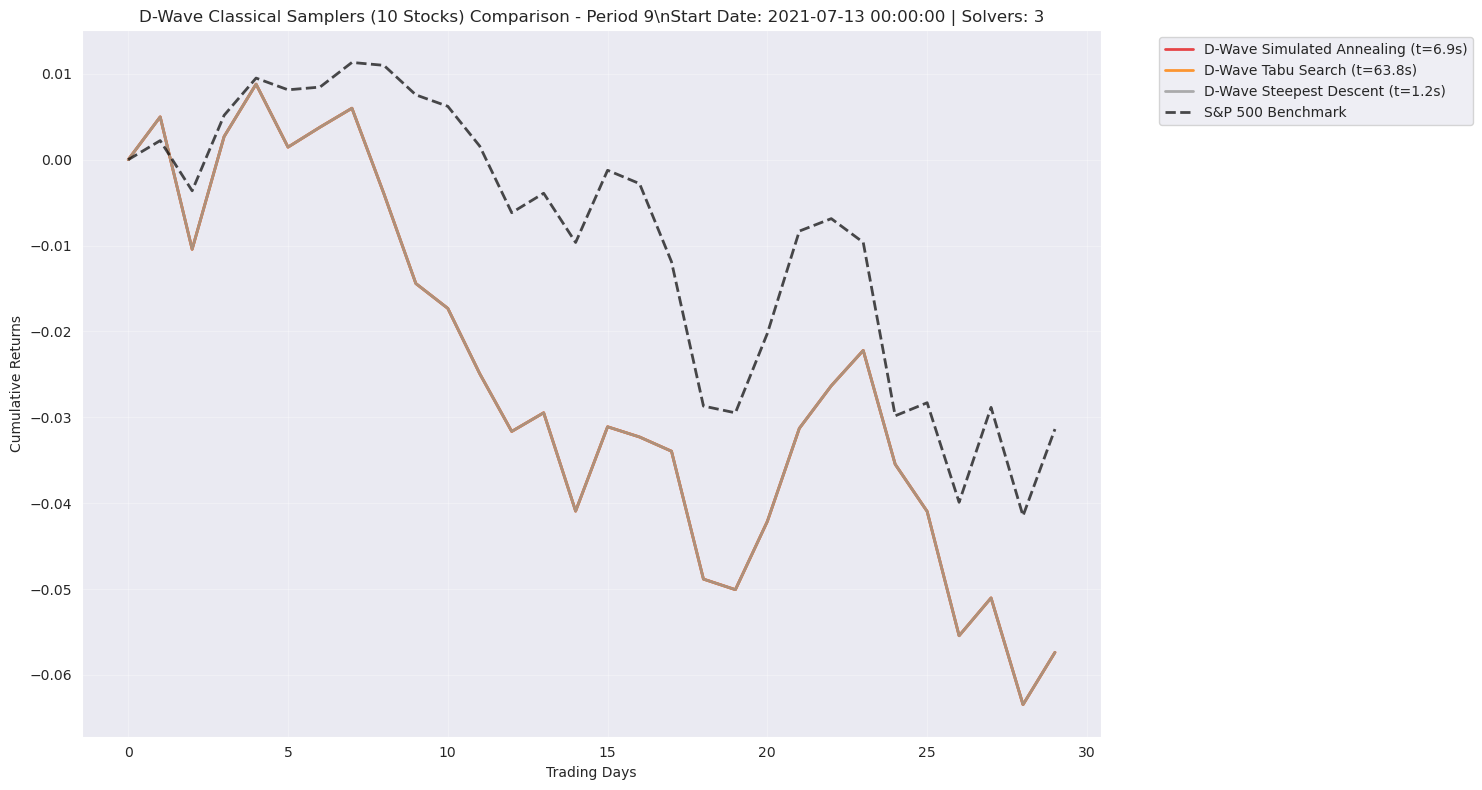

\nPeriod 9 Summary:
--------------------------------------------------
D-Wave Simulated Annealing:  -0.0574 (  6.88s)
D-Wave Tabu Search       :  -0.0574 ( 63.82s)
D-Wave Steepest Descent  :  -0.0574 (  1.18s)
Benchmark                :  -0.0314

\n================================================================================
PERFORMANCE SUMMARY - D-Wave Classical Samplers (10 Stocks)


,Solver,Periods,Avg_Return,Std_Return,Min_Return,Max_Return,Avg_Time,Std_Time,Success_Rate
0,D-Wave Simulated Annealing,10,0.0518,0.0639,-0.0574,0.1491,8.2480,1.0776,100.0
1,D-Wave Tabu Search,10,0.0518,0.0639,-0.0574,0.1491,63.9314,0.1637,100.0
2,D-Wave Steepest Descent,10,0.0518,0.0639,-0.0574,0.1491,0.9787,0.1690,100.0


In [82]:
# Updated D-Wave Classical Samplers Comparison for 10 Stocks using multi_comparison
dwave_10_solvers = [
    {'path_template': '../results/results_10_{}_dwave_sa.pkl', 'name': 'D-Wave Simulated Annealing'},
    {'path_template': '../results/results_10_{}_dwave_tabu.pkl', 'name': 'D-Wave Tabu Search'},
    {'path_template': '../results/results_10_{}_dwave_greedy.pkl', 'name': 'D-Wave Steepest Descent'}
]

n_periods = parameters['n_periods']
multi_comparison(dwave_10_solvers, n_periods, "D-Wave Classical Samplers (10 Stocks)")

# Generate performance summary
print("\\n" + "="*80)
print("PERFORMANCE SUMMARY - D-Wave Classical Samplers (10 Stocks)")
print("="*80)
summary_df = performance_summary(dwave_10_solvers, n_periods)
if not summary_df.empty:
    display(summary_df)
else:
    print("No summary data available")

### Medium test: Optimization with 100 stocks

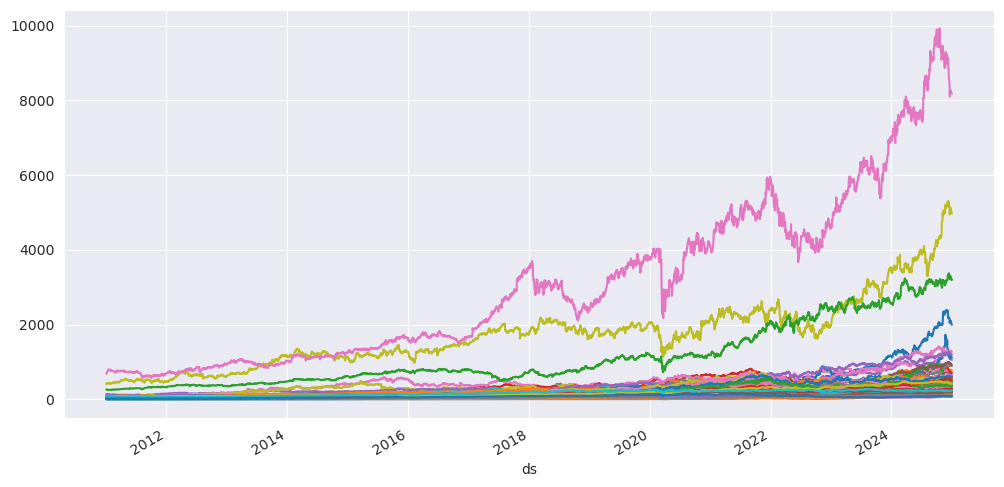

In [83]:
data_100 = source[select_100]
sns.set_style('darkgrid')
data_100.plot(figsize=(12,6))
plt.legend().remove()
plt.show()

#### D-Wave Simulated Annealing (100 stocks)

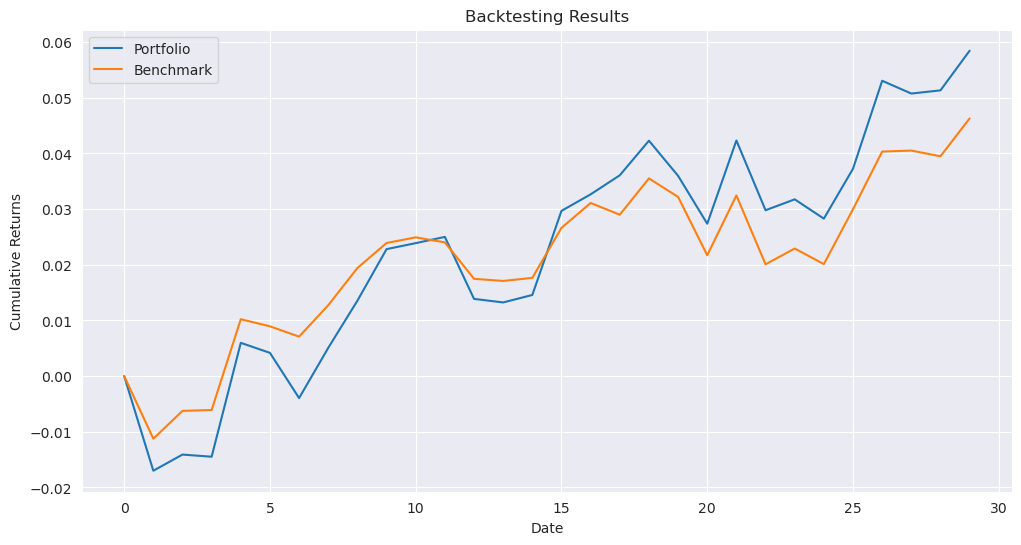

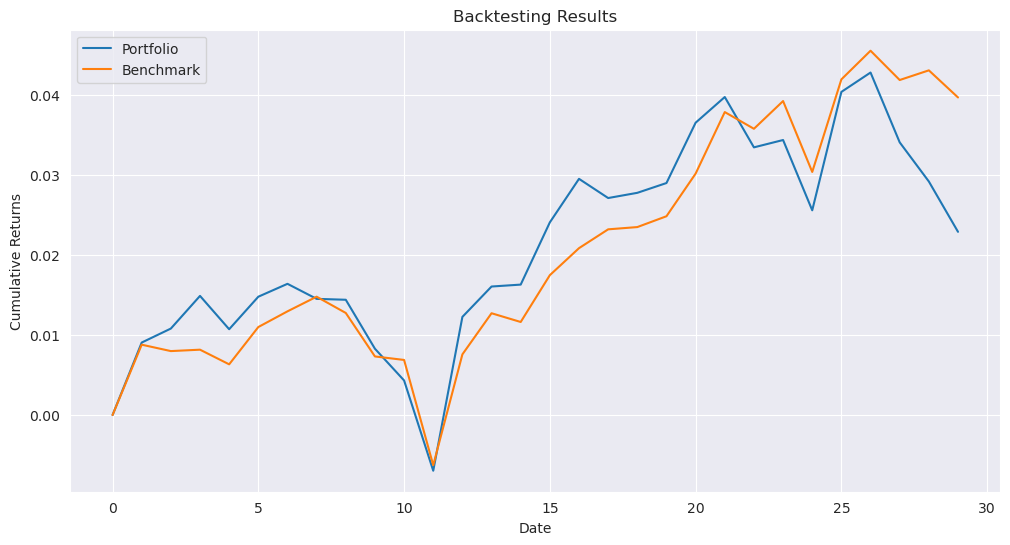

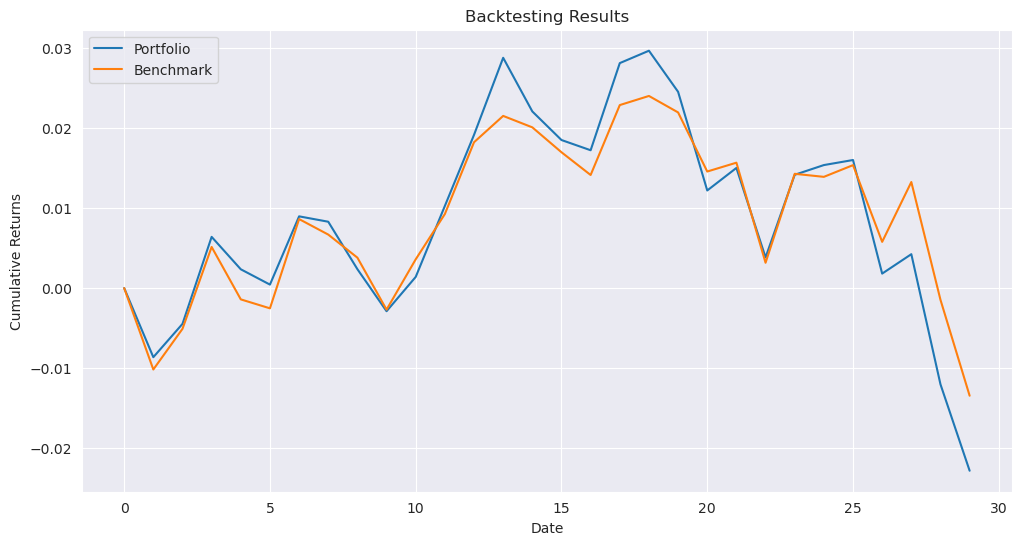

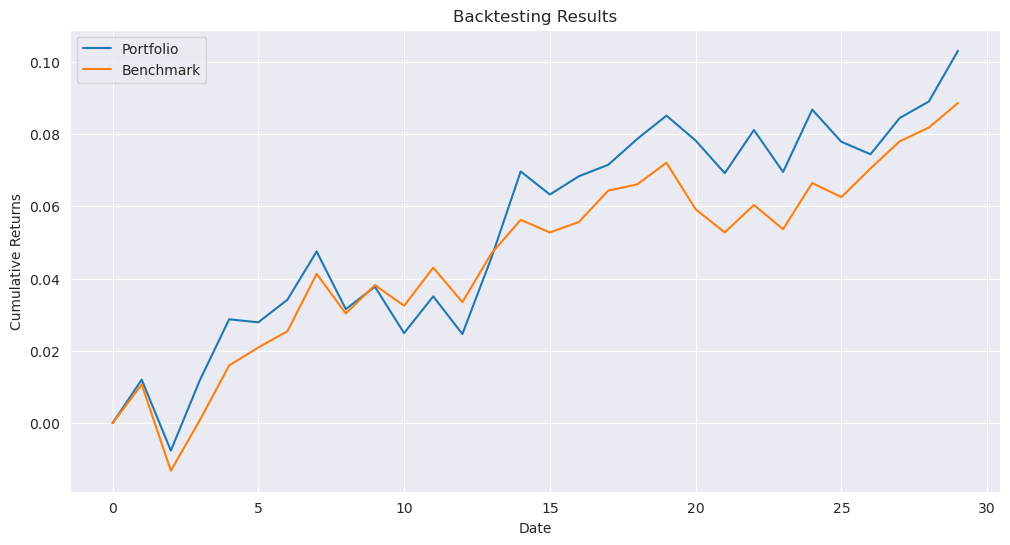

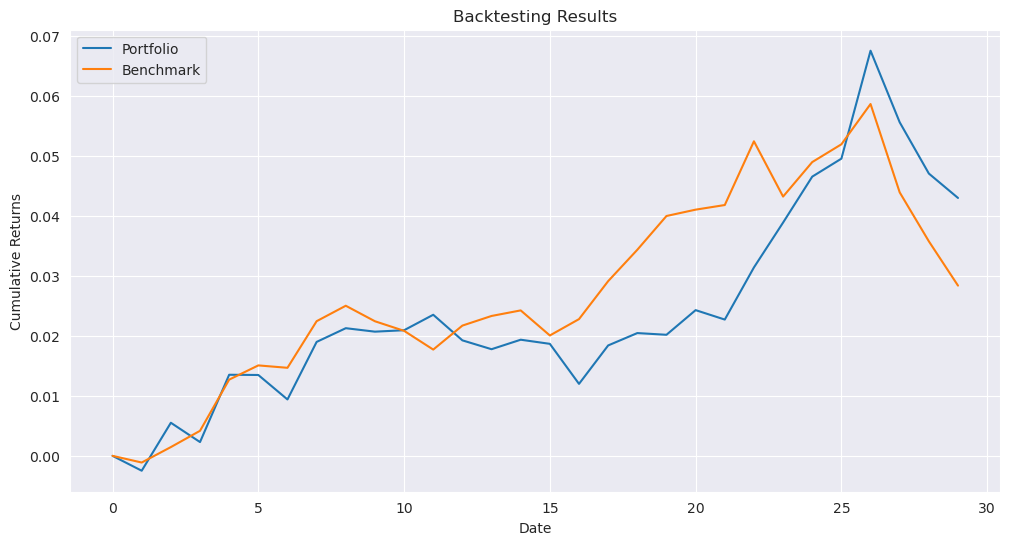

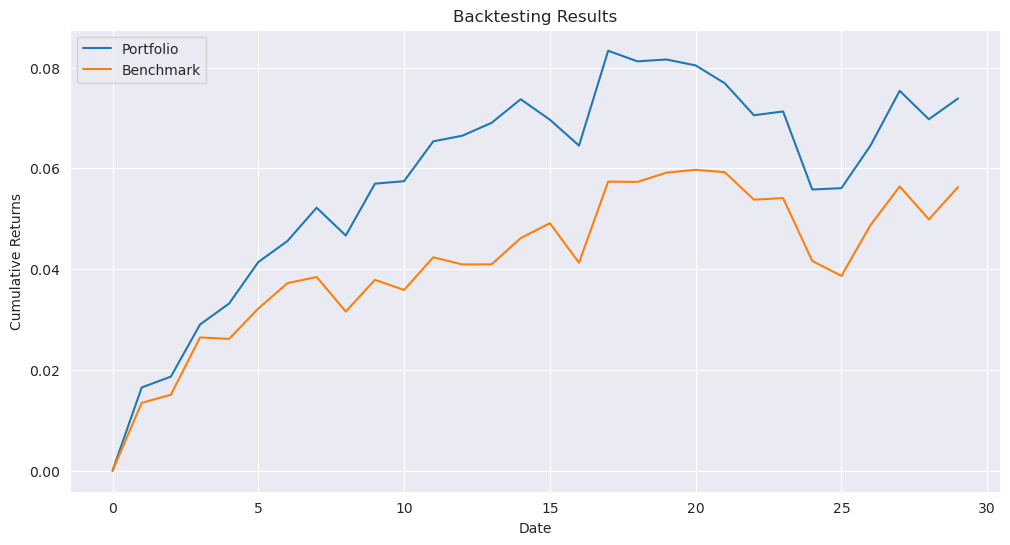

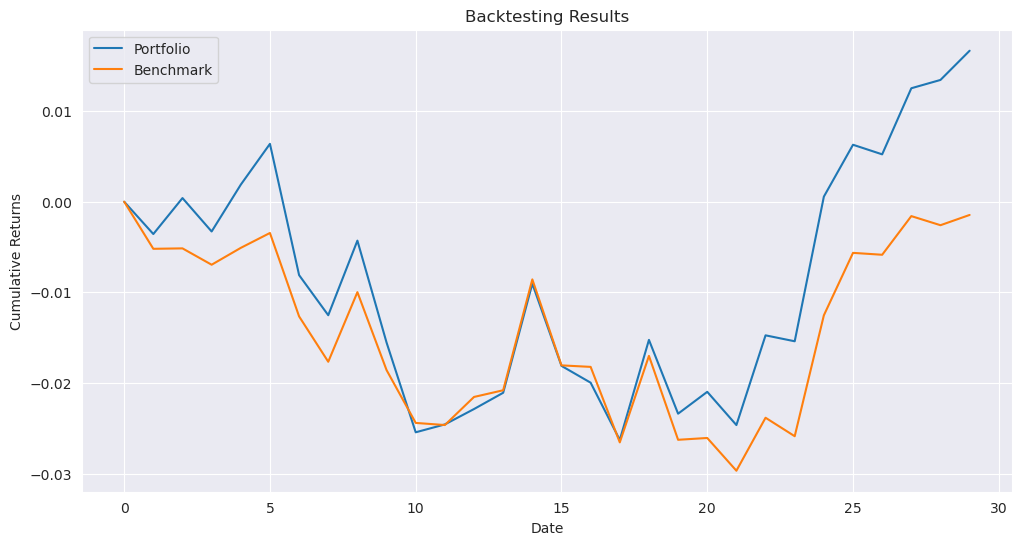

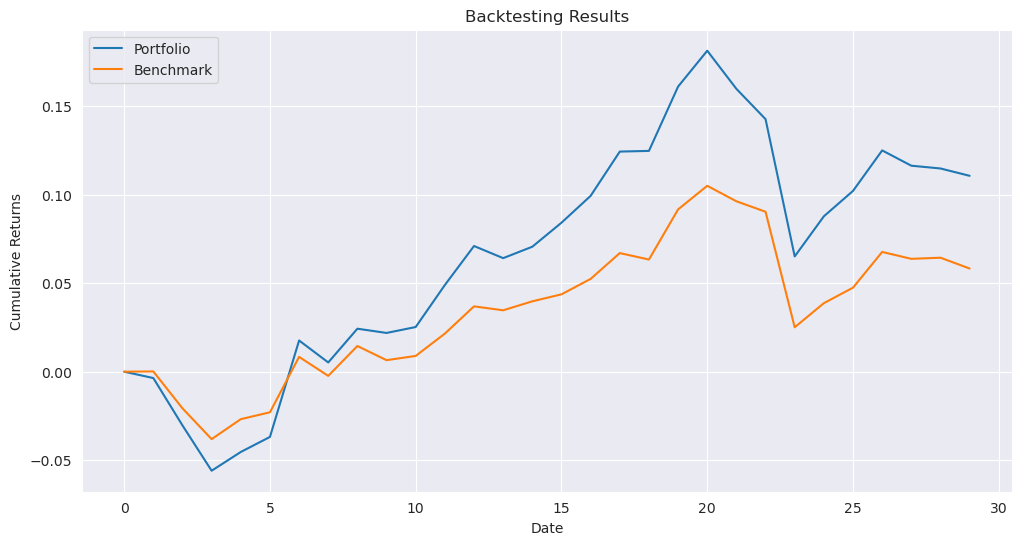

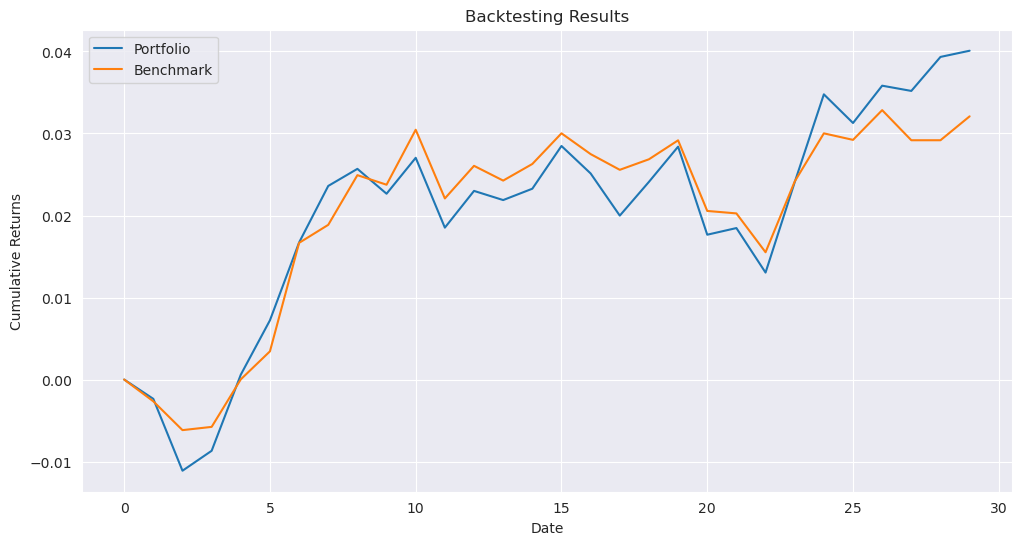

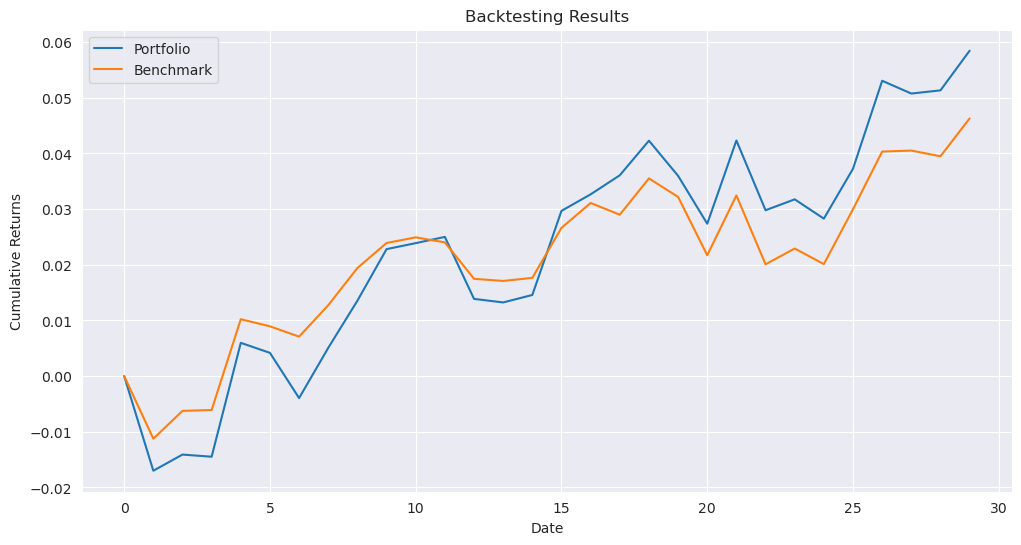

In [84]:
results_path_dwave_sa_100 = '../results/results_100_{}_dwave_sa.pkl'
_ = run_experiment(results_path_dwave_sa_100, data_100, benchmark, opt_fun_dwave_sa, parameters)

#### D-Wave Tabu Search (100 stocks)

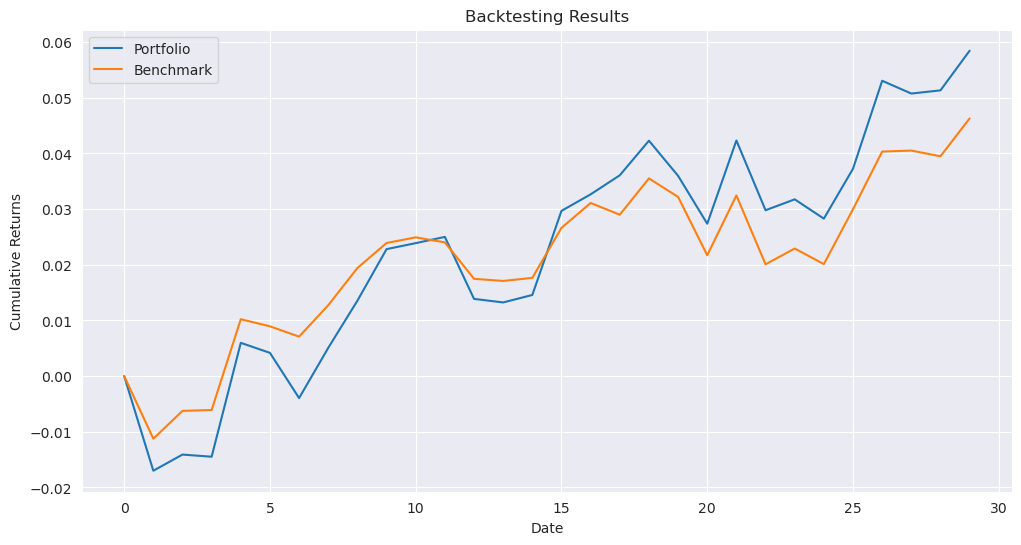

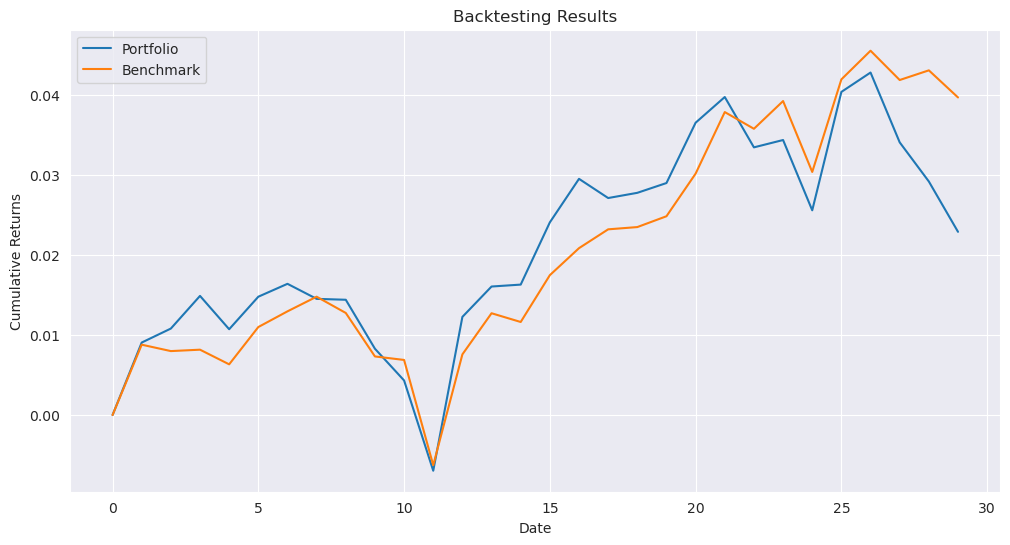

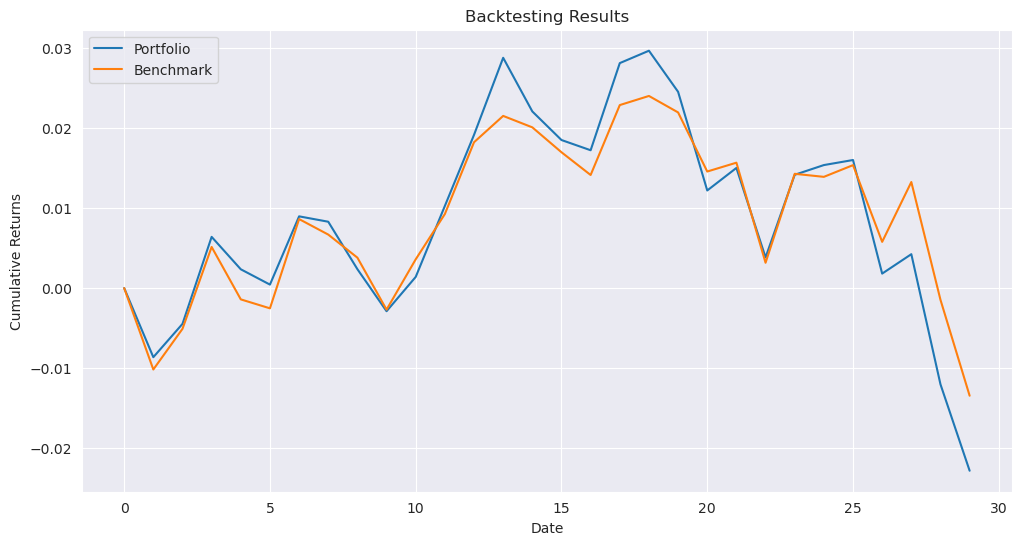

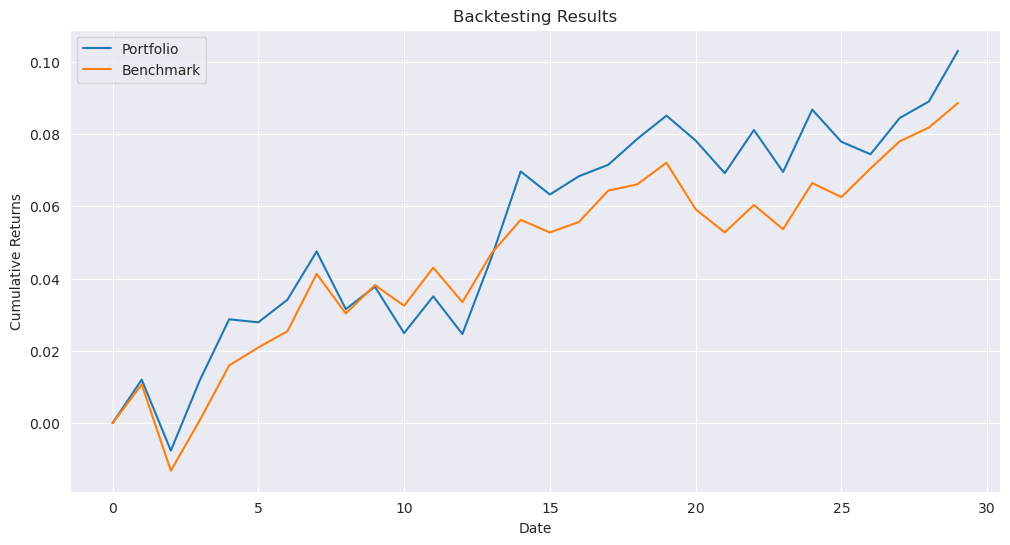

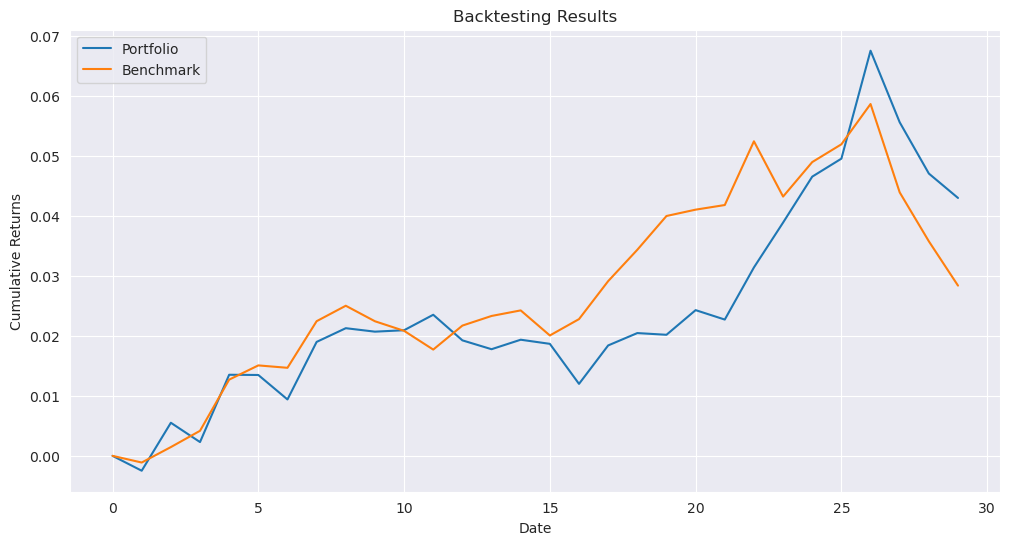

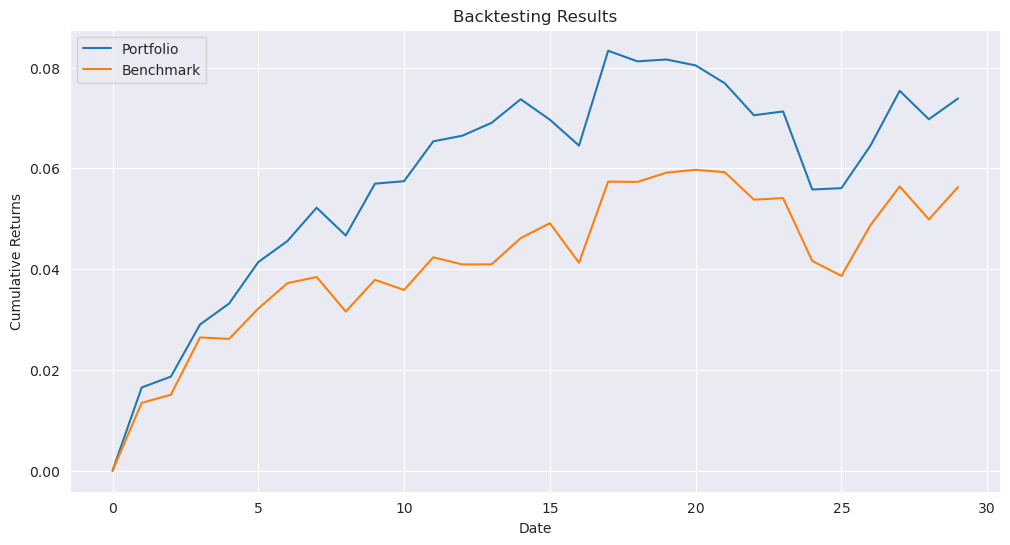

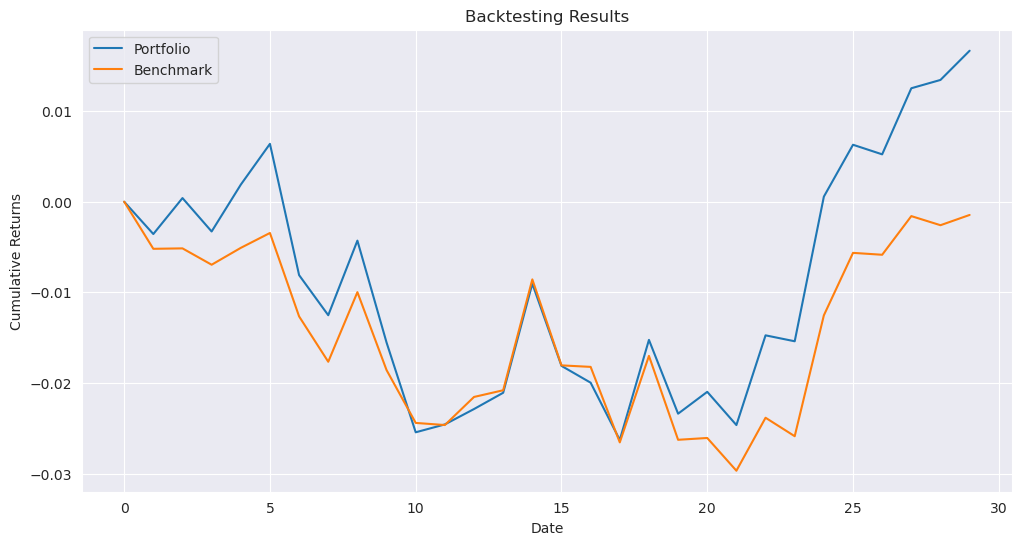

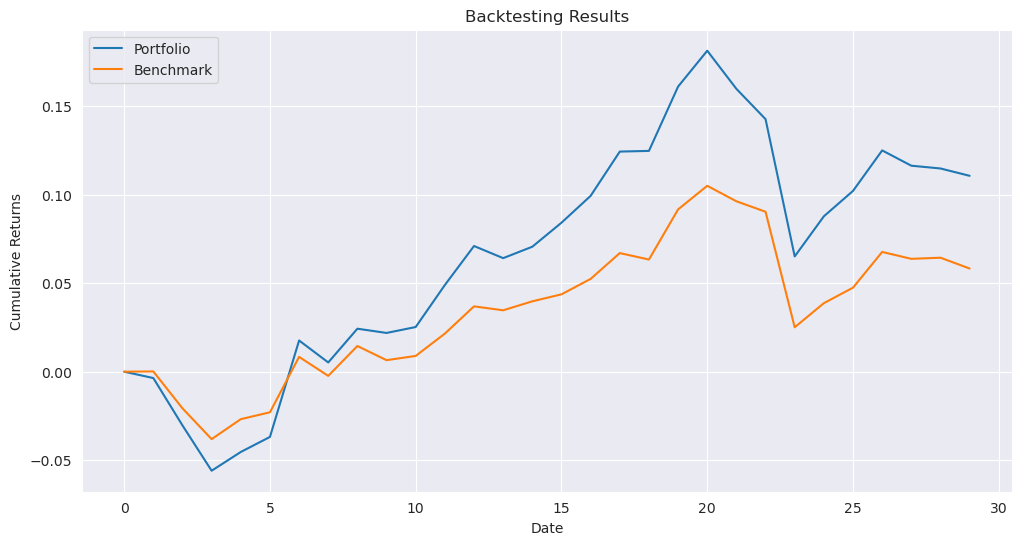

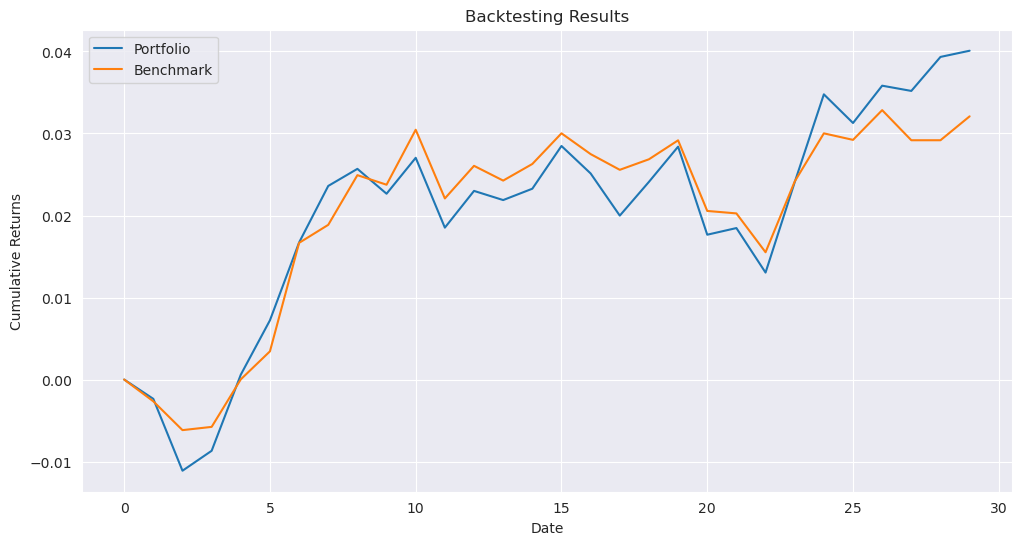

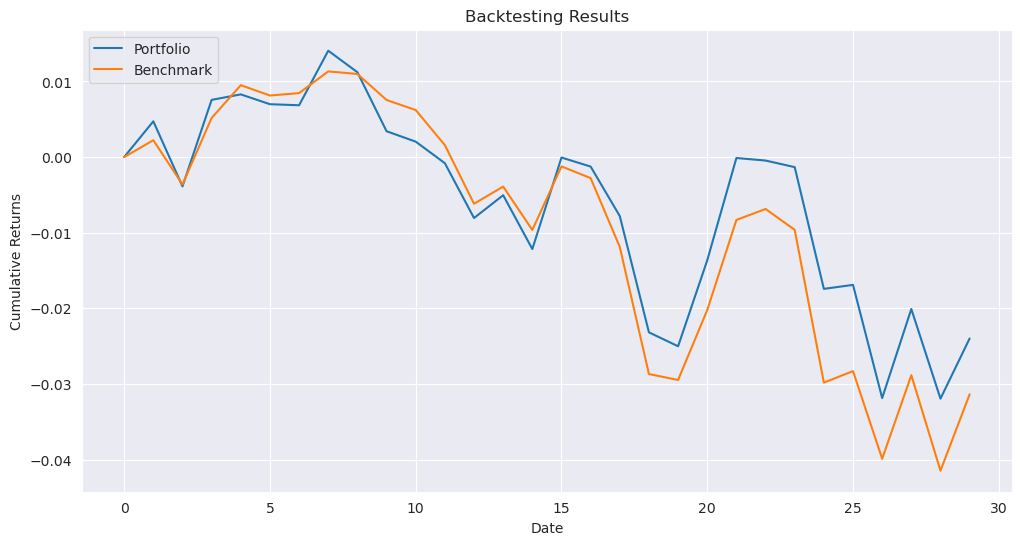

In [85]:
results_path_dwave_tabu_100 = '../results/results_100_{}_dwave_tabu.pkl'
_ = run_experiment(results_path_dwave_tabu_100, data_100, benchmark, opt_fun_dwave_tabu, parameters)

#### D-Wave Steepest Descent (100 stocks)

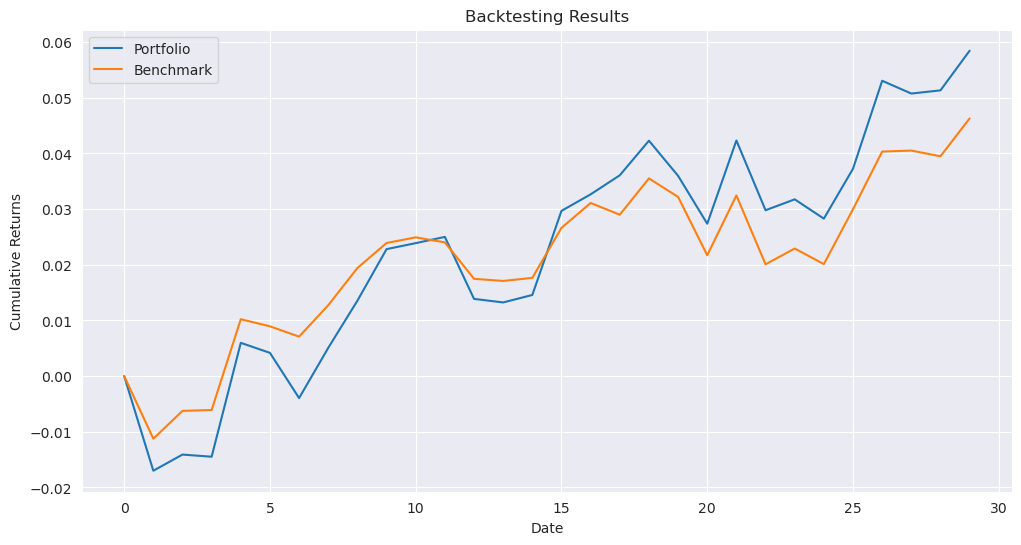

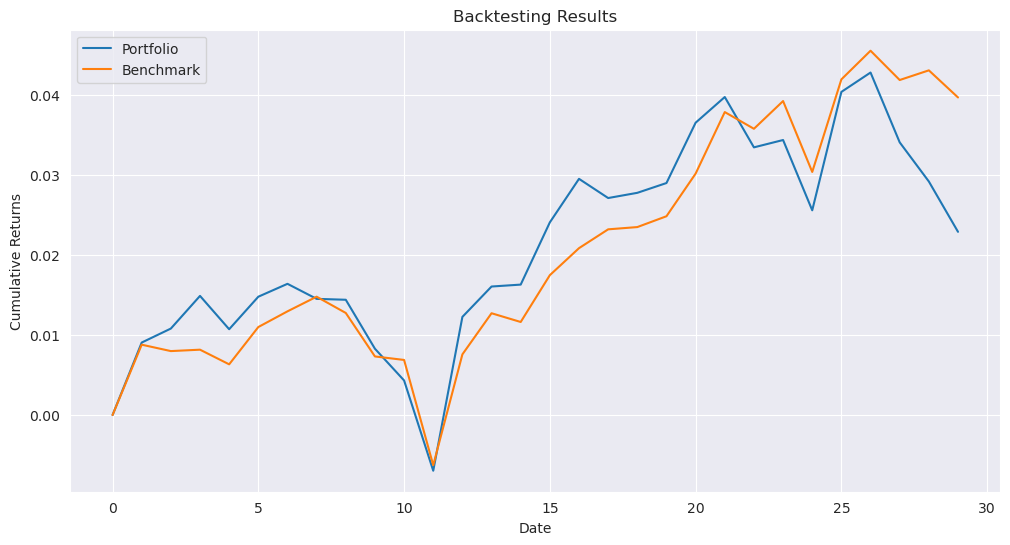

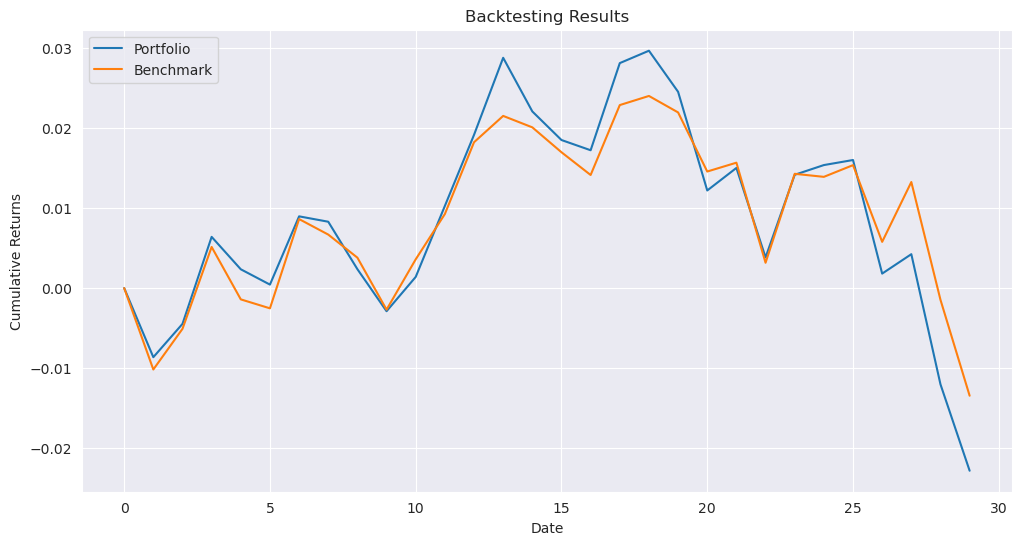

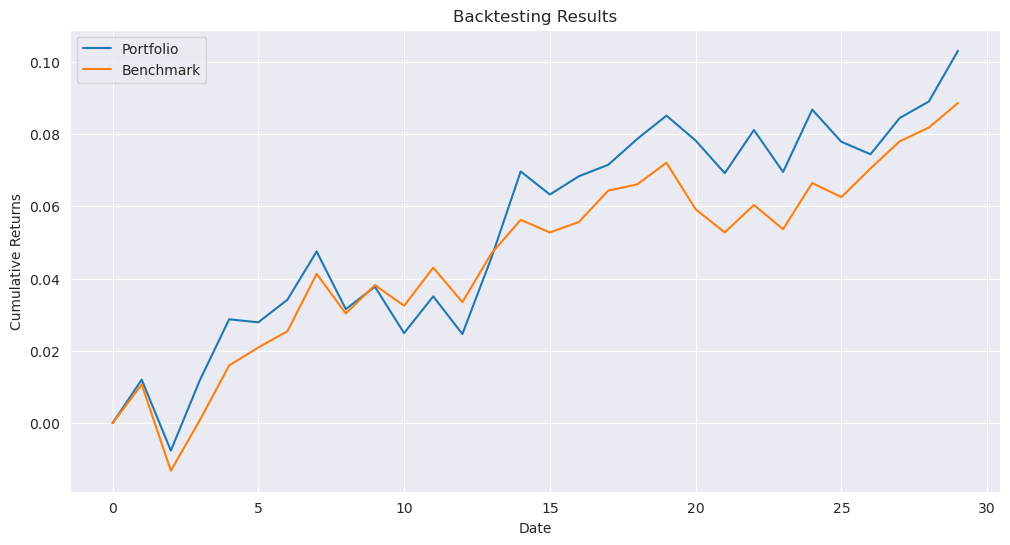

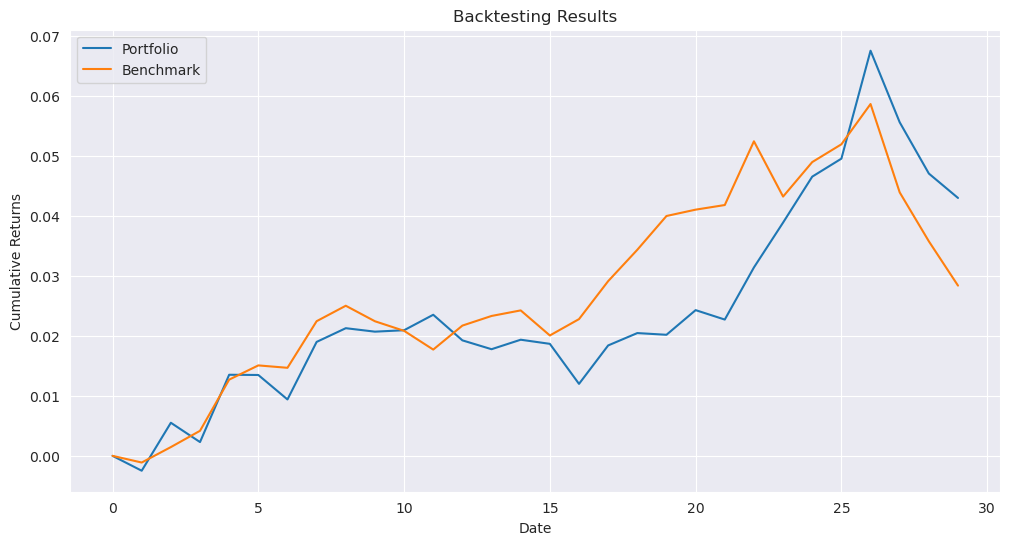

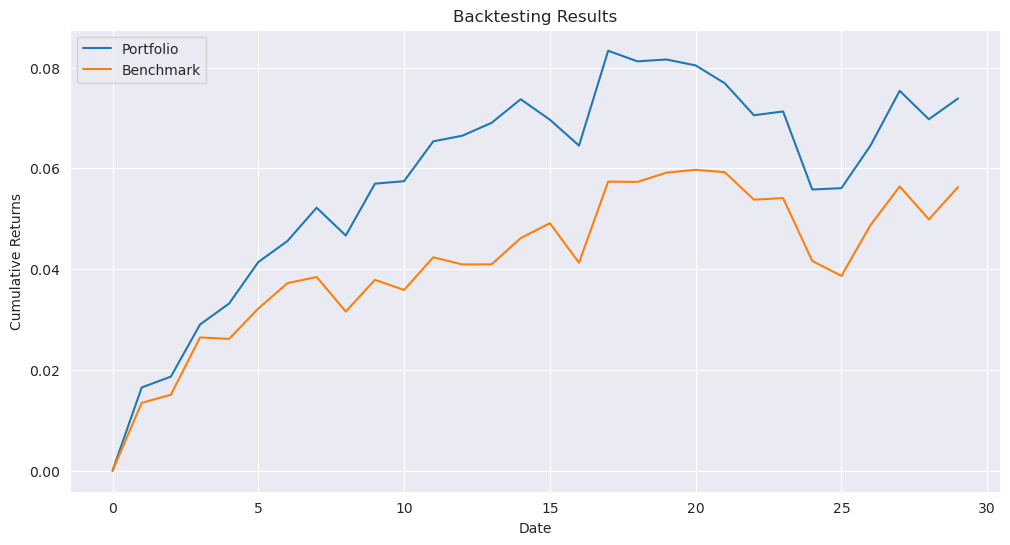

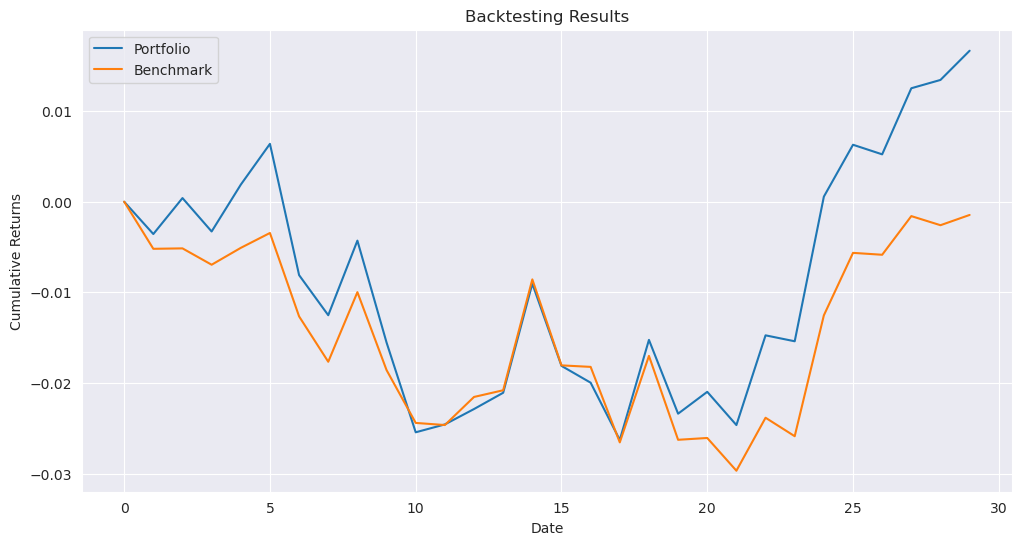

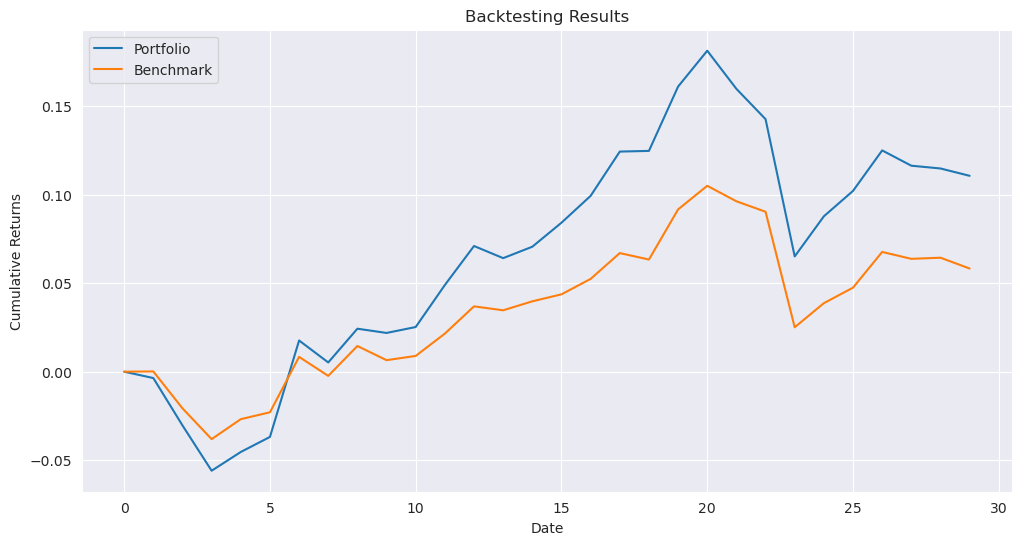

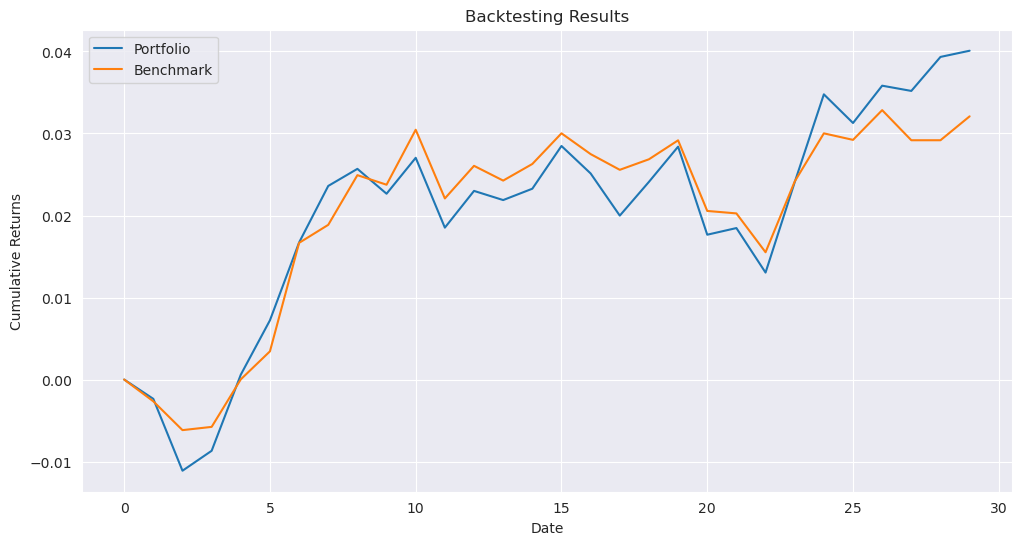

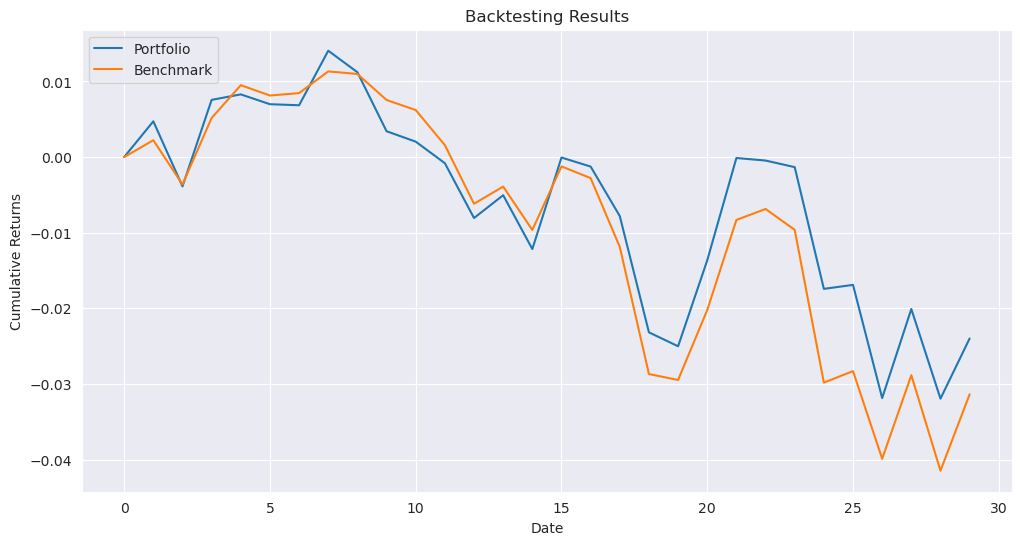

In [86]:
results_path_dwave_greedy_100 = '../results/results_100_{}_dwave_greedy.pkl'
_ = run_experiment(results_path_dwave_greedy_100, data_100, benchmark, opt_fun_dwave_greedy, parameters)

#### D-Wave Classical Samplers Comparison for 100 Stocks

2025-08-26 20:46:21,970 - inspect_results_logger - INFO - Period 0: Loaded D-Wave Simulated Annealing (exec_time: 235.29s)
INFO:inspect_results_logger:Period 0: Loaded D-Wave Simulated Annealing (exec_time: 235.29s)
2025-08-26 20:46:21,971 - inspect_results_logger - INFO - Period 0: Loaded D-Wave Tabu Search (exec_time: 140.26s)
INFO:inspect_results_logger:Period 0: Loaded D-Wave Tabu Search (exec_time: 140.26s)
2025-08-26 20:46:21,971 - inspect_results_logger - INFO - Period 0: Loaded D-Wave Steepest Descent (exec_time: 48.55s)
INFO:inspect_results_logger:Period 0: Loaded D-Wave Steepest Descent (exec_time: 48.55s)


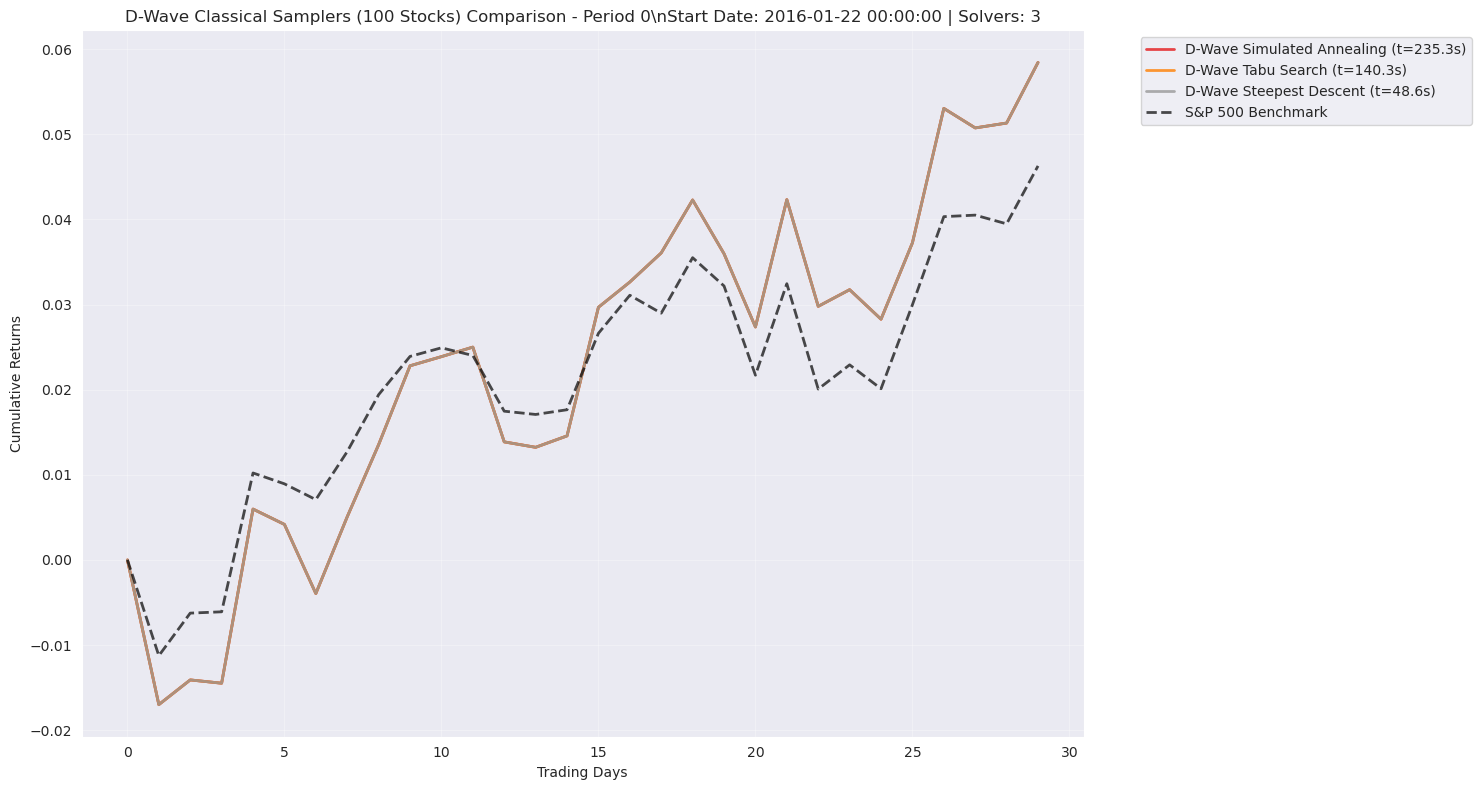

2025-08-26 20:46:22,086 - inspect_results_logger - INFO - Period 1: Loaded D-Wave Simulated Annealing (exec_time: 220.18s)
INFO:inspect_results_logger:Period 1: Loaded D-Wave Simulated Annealing (exec_time: 220.18s)
2025-08-26 20:46:22,086 - inspect_results_logger - INFO - Period 1: Loaded D-Wave Tabu Search (exec_time: 112.61s)
INFO:inspect_results_logger:Period 1: Loaded D-Wave Tabu Search (exec_time: 112.61s)
2025-08-26 20:46:22,087 - inspect_results_logger - INFO - Period 1: Loaded D-Wave Steepest Descent (exec_time: 46.85s)
INFO:inspect_results_logger:Period 1: Loaded D-Wave Steepest Descent (exec_time: 46.85s)


\nPeriod 0 Summary:
--------------------------------------------------
D-Wave Simulated Annealing:   0.0584 (235.29s)
D-Wave Tabu Search       :   0.0584 (140.26s)
D-Wave Steepest Descent  :   0.0584 ( 48.55s)
Benchmark                :   0.0463



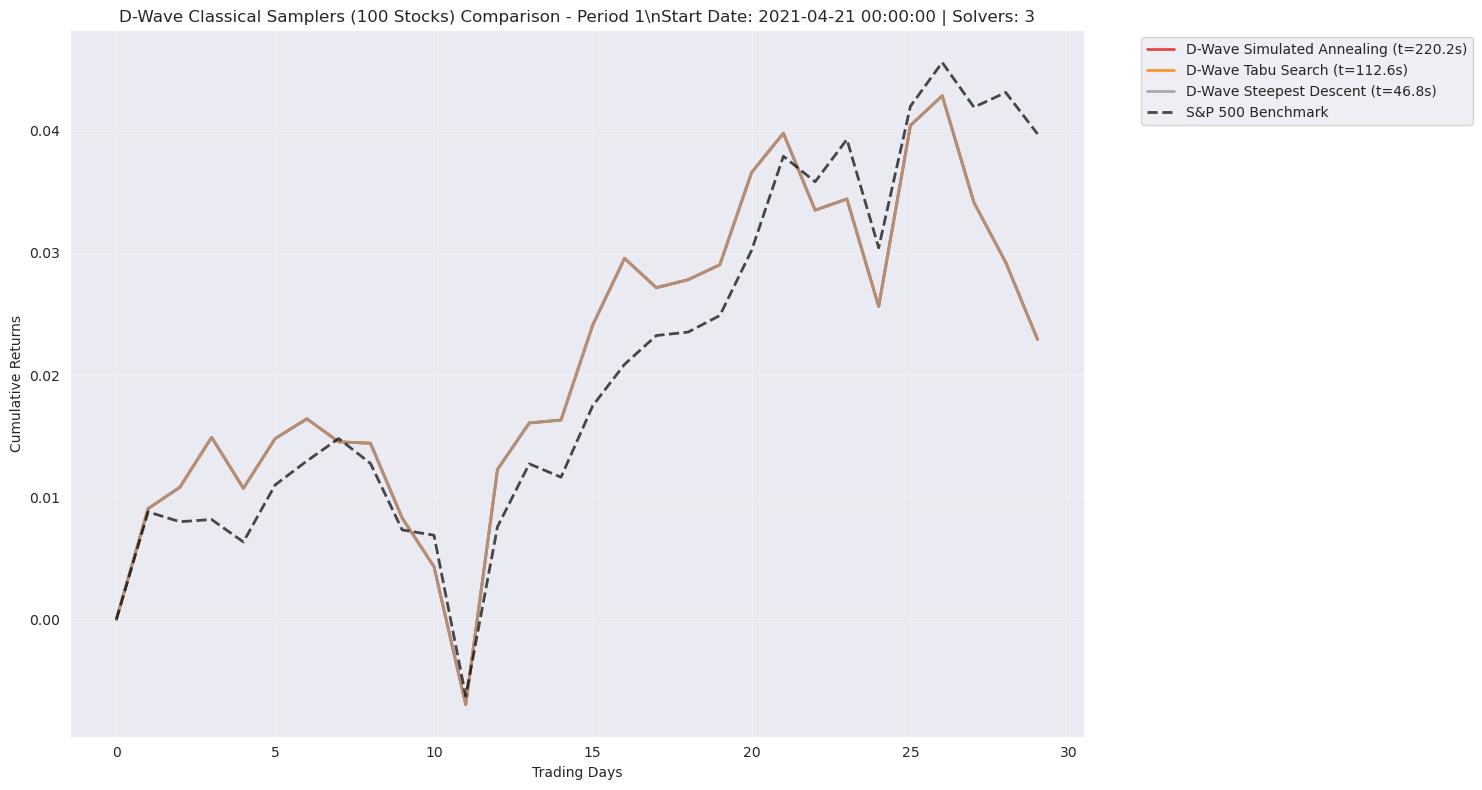

2025-08-26 20:46:22,191 - inspect_results_logger - INFO - Period 2: Loaded D-Wave Simulated Annealing (exec_time: 217.26s)
INFO:inspect_results_logger:Period 2: Loaded D-Wave Simulated Annealing (exec_time: 217.26s)
2025-08-26 20:46:22,192 - inspect_results_logger - INFO - Period 2: Loaded D-Wave Tabu Search (exec_time: 117.00s)
INFO:inspect_results_logger:Period 2: Loaded D-Wave Tabu Search (exec_time: 117.00s)
2025-08-26 20:46:22,192 - inspect_results_logger - INFO - Period 2: Loaded D-Wave Steepest Descent (exec_time: 47.28s)
INFO:inspect_results_logger:Period 2: Loaded D-Wave Steepest Descent (exec_time: 47.28s)


\nPeriod 1 Summary:
--------------------------------------------------
D-Wave Simulated Annealing:   0.0229 (220.18s)
D-Wave Tabu Search       :   0.0229 (112.61s)
D-Wave Steepest Descent  :   0.0229 ( 46.85s)
Benchmark                :   0.0397



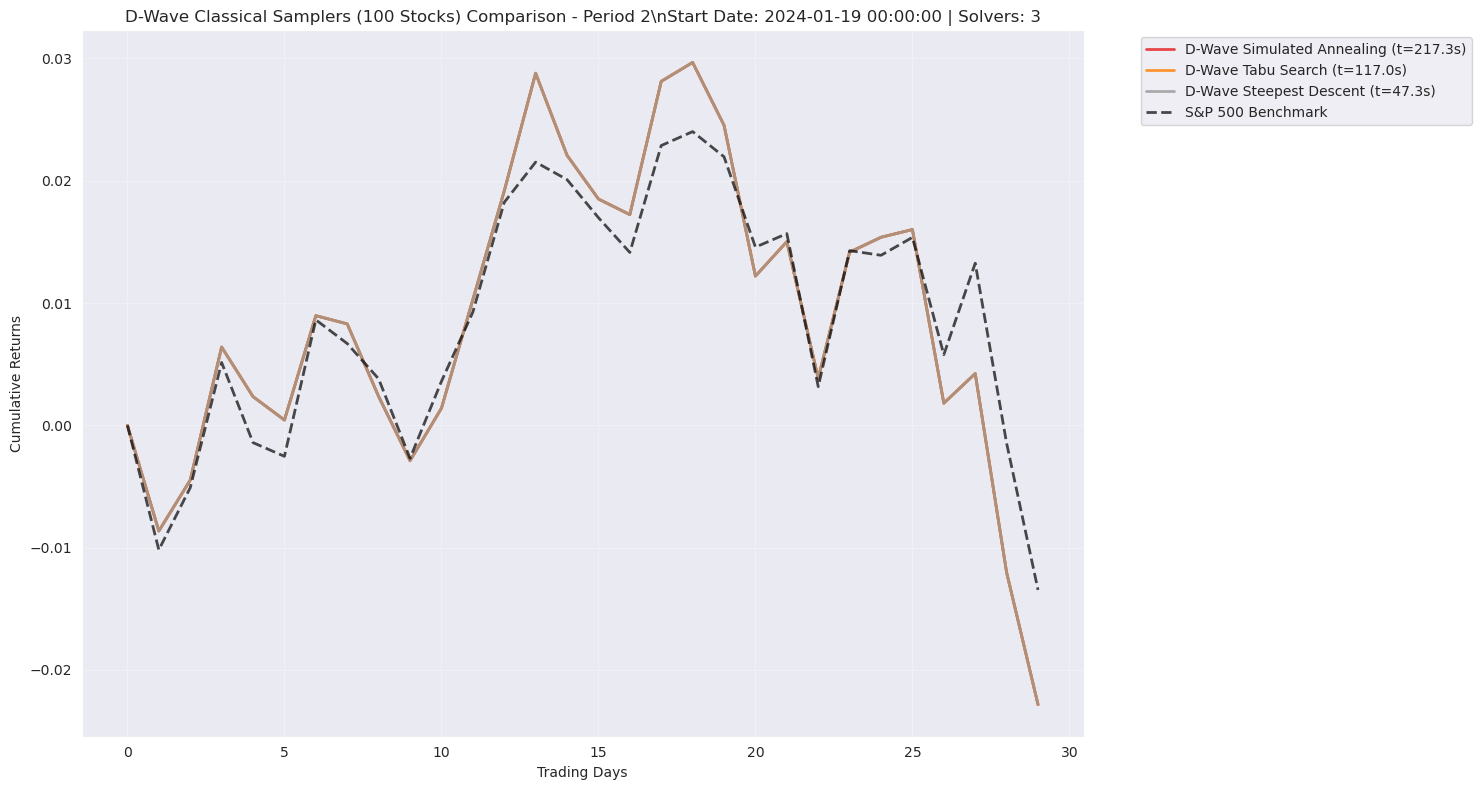

2025-08-26 20:46:22,301 - inspect_results_logger - INFO - Period 3: Loaded D-Wave Simulated Annealing (exec_time: 219.61s)
INFO:inspect_results_logger:Period 3: Loaded D-Wave Simulated Annealing (exec_time: 219.61s)
2025-08-26 20:46:22,301 - inspect_results_logger - INFO - Period 3: Loaded D-Wave Tabu Search (exec_time: 134.76s)
INFO:inspect_results_logger:Period 3: Loaded D-Wave Tabu Search (exec_time: 134.76s)
2025-08-26 20:46:22,302 - inspect_results_logger - INFO - Period 3: Loaded D-Wave Steepest Descent (exec_time: 46.57s)
INFO:inspect_results_logger:Period 3: Loaded D-Wave Steepest Descent (exec_time: 46.57s)


\nPeriod 2 Summary:
--------------------------------------------------
D-Wave Simulated Annealing:  -0.0228 (217.26s)
D-Wave Tabu Search       :  -0.0228 (117.00s)
D-Wave Steepest Descent  :  -0.0228 ( 47.28s)
Benchmark                :  -0.0135



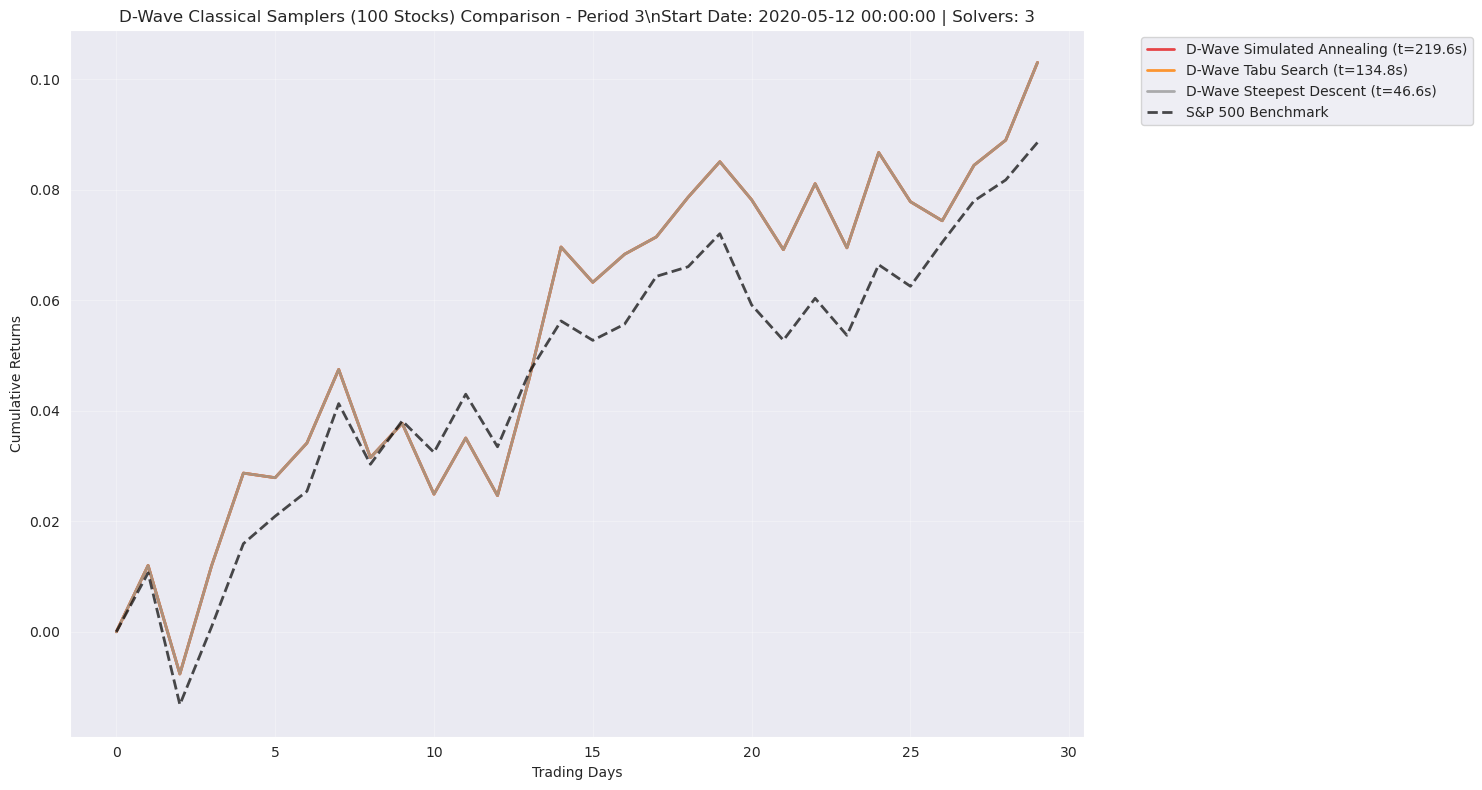

2025-08-26 20:46:22,409 - inspect_results_logger - INFO - Period 4: Loaded D-Wave Simulated Annealing (exec_time: 208.77s)
INFO:inspect_results_logger:Period 4: Loaded D-Wave Simulated Annealing (exec_time: 208.77s)
2025-08-26 20:46:22,410 - inspect_results_logger - INFO - Period 4: Loaded D-Wave Tabu Search (exec_time: 112.17s)
INFO:inspect_results_logger:Period 4: Loaded D-Wave Tabu Search (exec_time: 112.17s)
2025-08-26 20:46:22,412 - inspect_results_logger - INFO - Period 4: Loaded D-Wave Steepest Descent (exec_time: 71.09s)
INFO:inspect_results_logger:Period 4: Loaded D-Wave Steepest Descent (exec_time: 71.09s)


\nPeriod 3 Summary:
--------------------------------------------------
D-Wave Simulated Annealing:   0.1031 (219.61s)
D-Wave Tabu Search       :   0.1031 (134.76s)
D-Wave Steepest Descent  :   0.1031 ( 46.57s)
Benchmark                :   0.0886



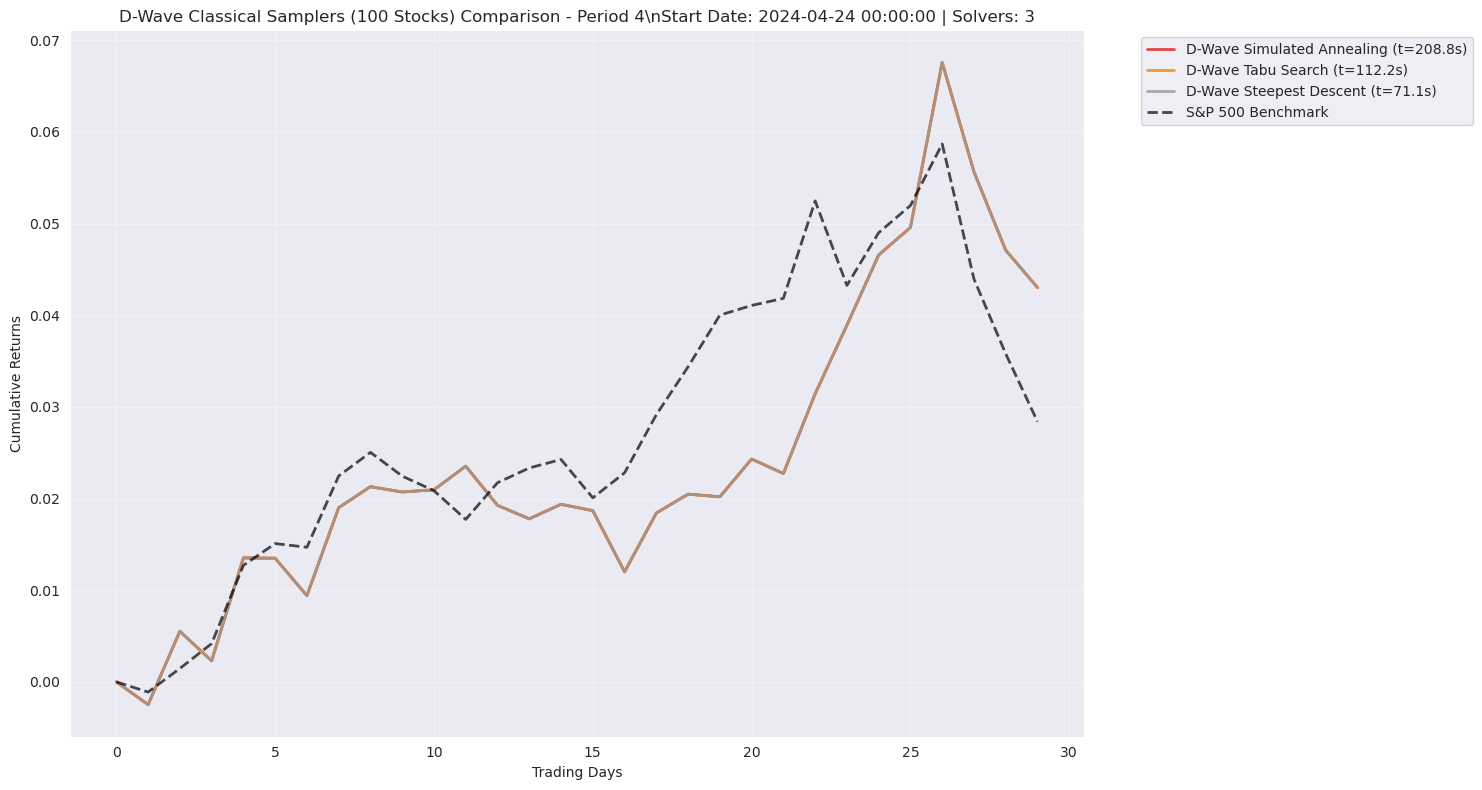

2025-08-26 20:46:22,523 - inspect_results_logger - INFO - Period 5: Loaded D-Wave Simulated Annealing (exec_time: 221.51s)
INFO:inspect_results_logger:Period 5: Loaded D-Wave Simulated Annealing (exec_time: 221.51s)
2025-08-26 20:46:22,525 - inspect_results_logger - INFO - Period 5: Loaded D-Wave Tabu Search (exec_time: 112.49s)
INFO:inspect_results_logger:Period 5: Loaded D-Wave Tabu Search (exec_time: 112.49s)
2025-08-26 20:46:22,527 - inspect_results_logger - INFO - Period 5: Loaded D-Wave Steepest Descent (exec_time: 47.81s)
INFO:inspect_results_logger:Period 5: Loaded D-Wave Steepest Descent (exec_time: 47.81s)


\nPeriod 4 Summary:
--------------------------------------------------
D-Wave Simulated Annealing:   0.0430 (208.77s)
D-Wave Tabu Search       :   0.0430 (112.17s)
D-Wave Steepest Descent  :   0.0430 ( 71.09s)
Benchmark                :   0.0284



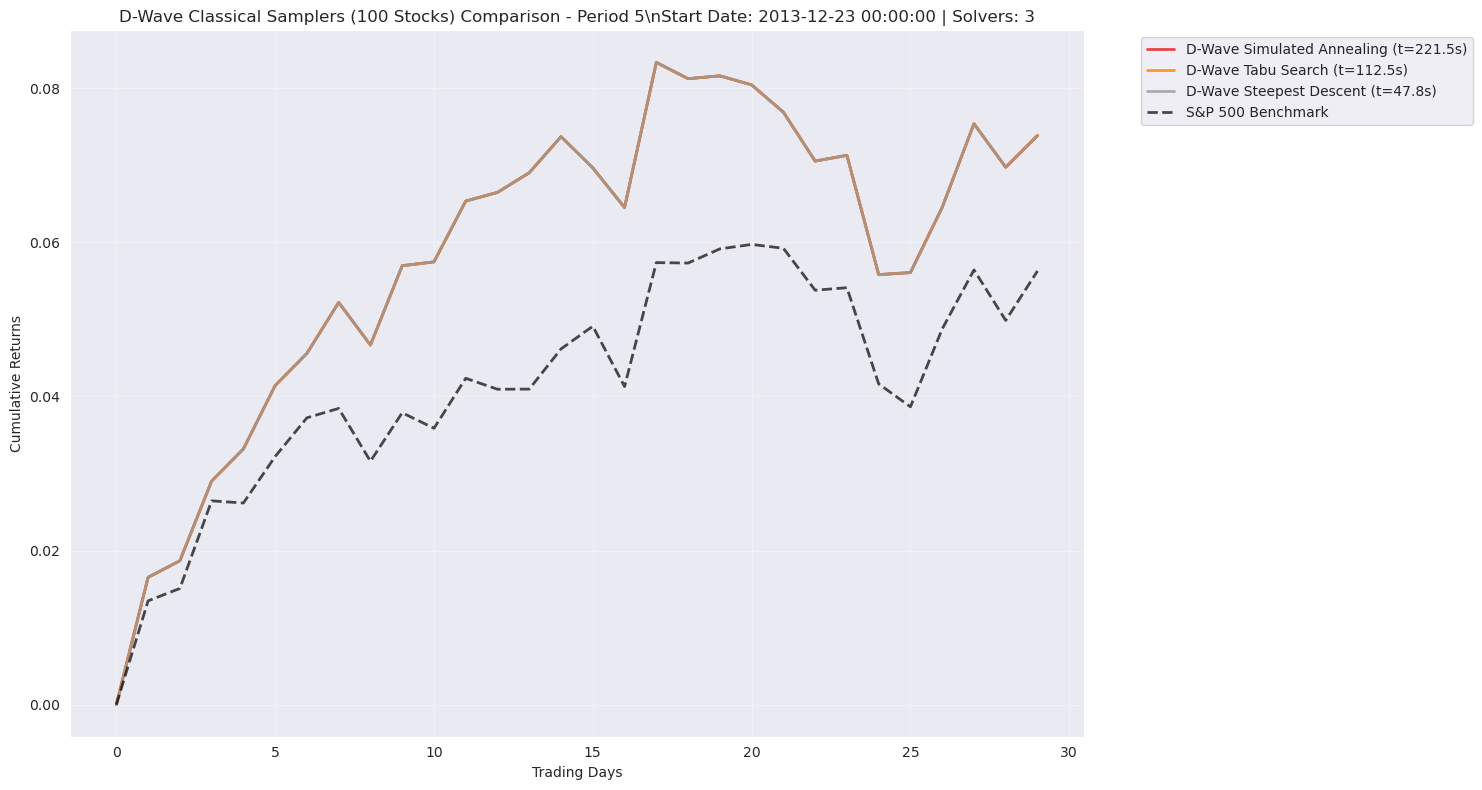

2025-08-26 20:46:22,633 - inspect_results_logger - INFO - Period 6: Loaded D-Wave Simulated Annealing (exec_time: 235.13s)
INFO:inspect_results_logger:Period 6: Loaded D-Wave Simulated Annealing (exec_time: 235.13s)
2025-08-26 20:46:22,635 - inspect_results_logger - INFO - Period 6: Loaded D-Wave Tabu Search (exec_time: 112.07s)
INFO:inspect_results_logger:Period 6: Loaded D-Wave Tabu Search (exec_time: 112.07s)
2025-08-26 20:46:22,636 - inspect_results_logger - INFO - Period 6: Loaded D-Wave Steepest Descent (exec_time: 46.61s)
INFO:inspect_results_logger:Period 6: Loaded D-Wave Steepest Descent (exec_time: 46.61s)


\nPeriod 5 Summary:
--------------------------------------------------
D-Wave Simulated Annealing:   0.0739 (221.51s)
D-Wave Tabu Search       :   0.0739 (112.49s)
D-Wave Steepest Descent  :   0.0739 ( 47.81s)
Benchmark                :   0.0563



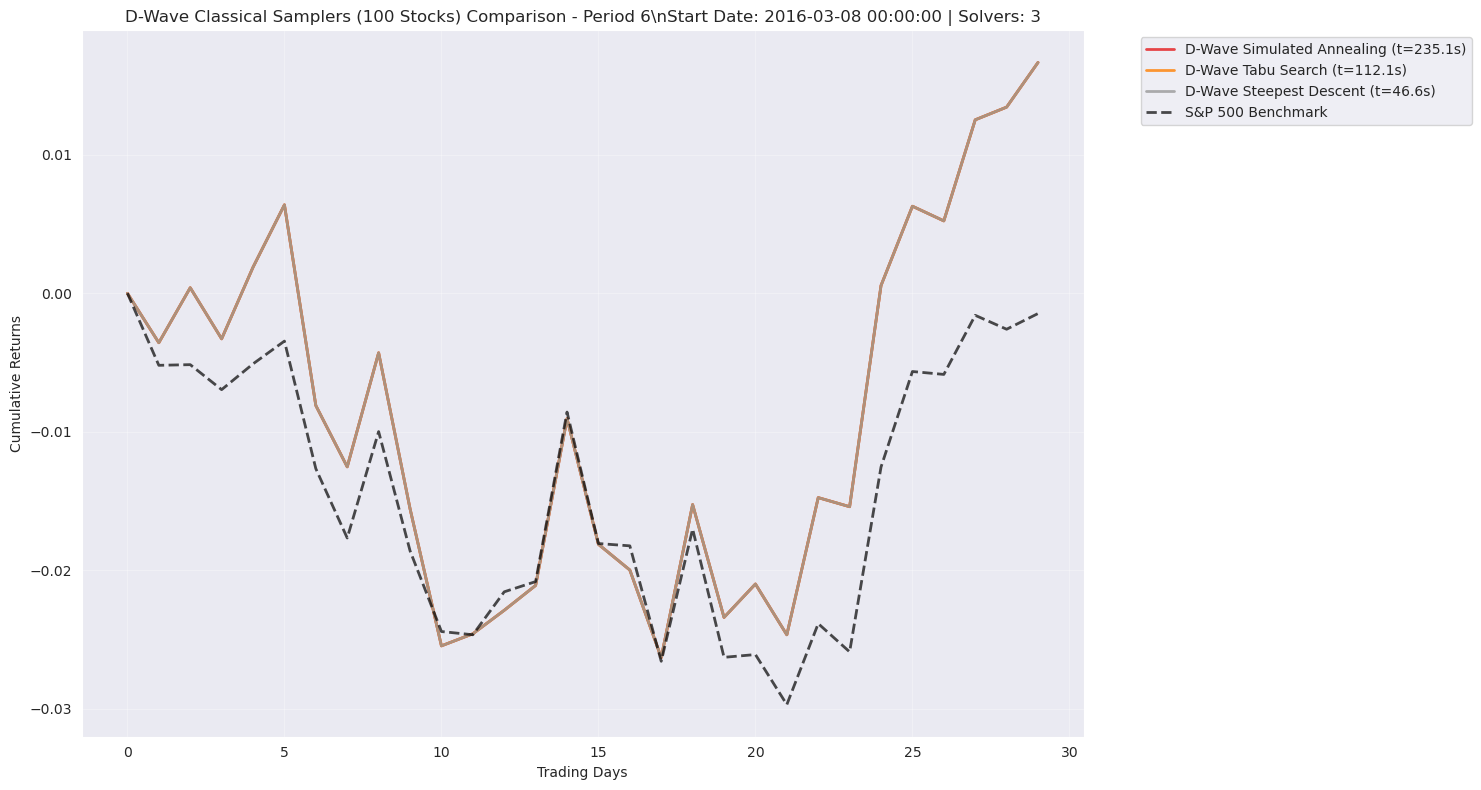

2025-08-26 20:46:22,744 - inspect_results_logger - INFO - Period 7: Loaded D-Wave Simulated Annealing (exec_time: 242.12s)
INFO:inspect_results_logger:Period 7: Loaded D-Wave Simulated Annealing (exec_time: 242.12s)
2025-08-26 20:46:22,746 - inspect_results_logger - INFO - Period 7: Loaded D-Wave Tabu Search (exec_time: 112.27s)
INFO:inspect_results_logger:Period 7: Loaded D-Wave Tabu Search (exec_time: 112.27s)
2025-08-26 20:46:22,747 - inspect_results_logger - INFO - Period 7: Loaded D-Wave Steepest Descent (exec_time: 46.61s)
INFO:inspect_results_logger:Period 7: Loaded D-Wave Steepest Descent (exec_time: 46.61s)


\nPeriod 6 Summary:
--------------------------------------------------
D-Wave Simulated Annealing:   0.0167 (235.13s)
D-Wave Tabu Search       :   0.0167 (112.07s)
D-Wave Steepest Descent  :   0.0167 ( 46.61s)
Benchmark                :  -0.0015



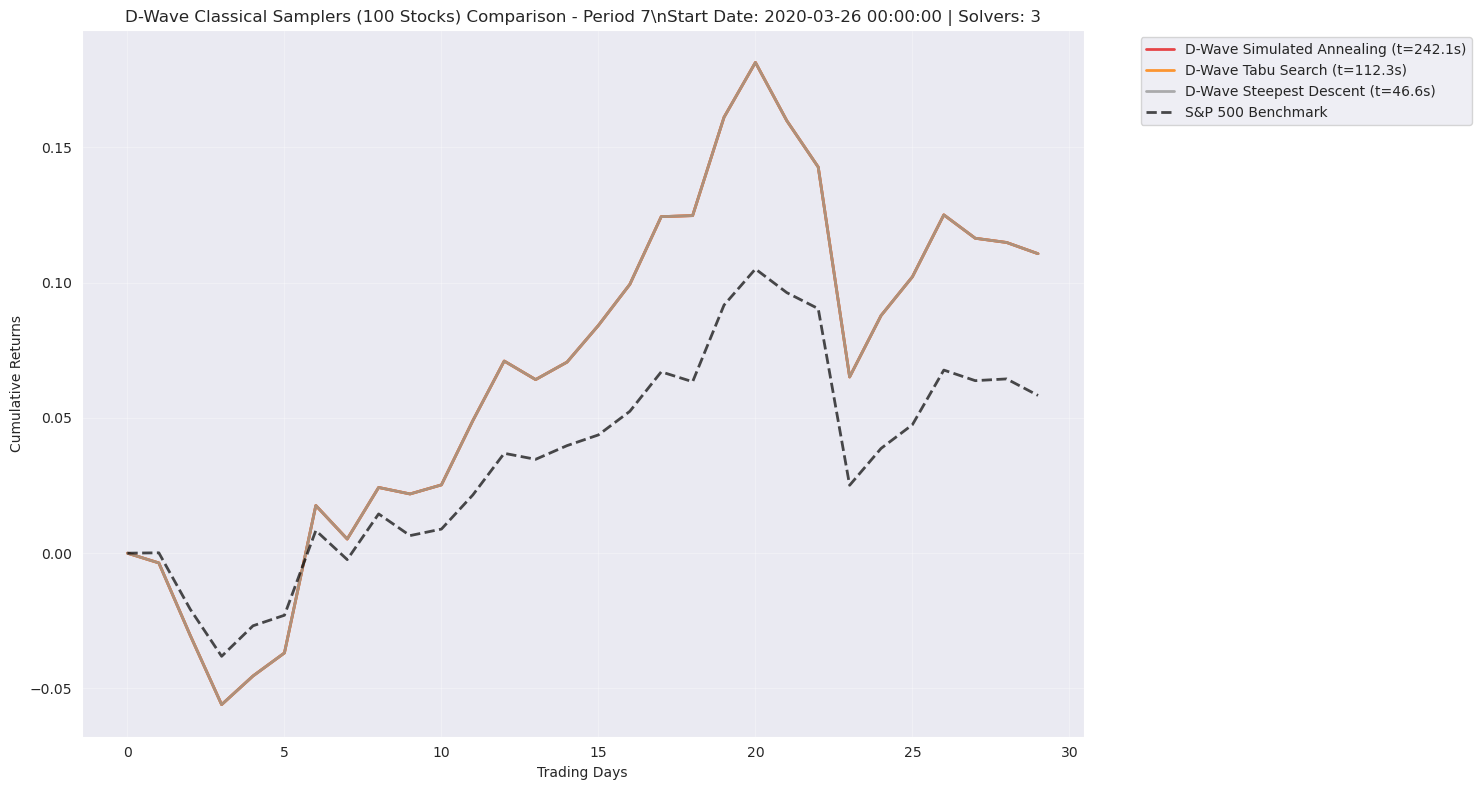

2025-08-26 20:46:22,854 - inspect_results_logger - INFO - Period 8: Loaded D-Wave Simulated Annealing (exec_time: 206.46s)
INFO:inspect_results_logger:Period 8: Loaded D-Wave Simulated Annealing (exec_time: 206.46s)
2025-08-26 20:46:22,856 - inspect_results_logger - INFO - Period 8: Loaded D-Wave Tabu Search (exec_time: 115.62s)
INFO:inspect_results_logger:Period 8: Loaded D-Wave Tabu Search (exec_time: 115.62s)
2025-08-26 20:46:22,857 - inspect_results_logger - INFO - Period 8: Loaded D-Wave Steepest Descent (exec_time: 46.44s)
INFO:inspect_results_logger:Period 8: Loaded D-Wave Steepest Descent (exec_time: 46.44s)


\nPeriod 7 Summary:
--------------------------------------------------
D-Wave Simulated Annealing:   0.1107 (242.12s)
D-Wave Tabu Search       :   0.1107 (112.27s)
D-Wave Steepest Descent  :   0.1107 ( 46.61s)
Benchmark                :   0.0583



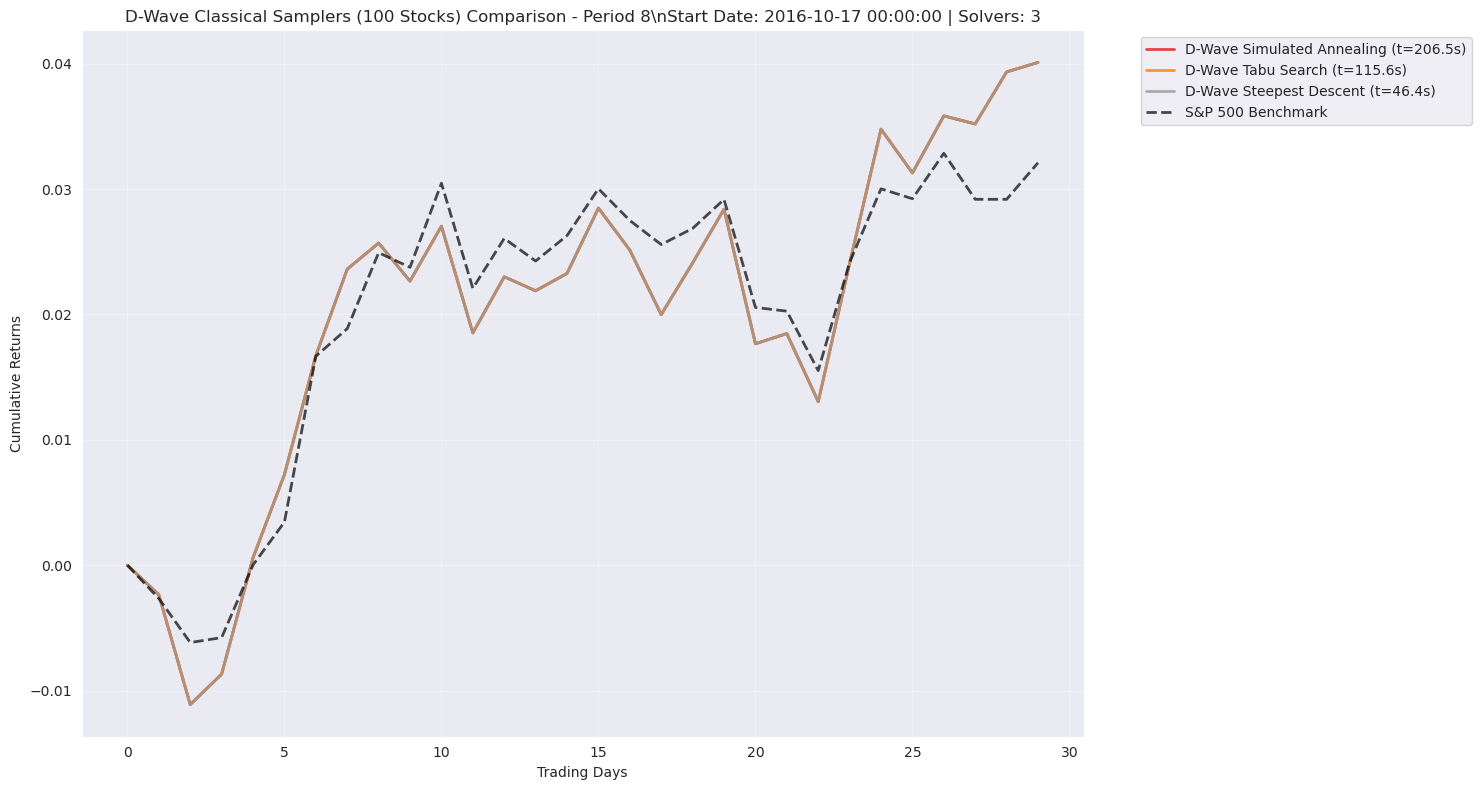

2025-08-26 20:46:22,965 - inspect_results_logger - INFO - Period 9: Loaded D-Wave Simulated Annealing (exec_time: 243.72s)
INFO:inspect_results_logger:Period 9: Loaded D-Wave Simulated Annealing (exec_time: 243.72s)
2025-08-26 20:46:22,967 - inspect_results_logger - INFO - Period 9: Loaded D-Wave Tabu Search (exec_time: 112.11s)
INFO:inspect_results_logger:Period 9: Loaded D-Wave Tabu Search (exec_time: 112.11s)
2025-08-26 20:46:22,969 - inspect_results_logger - INFO - Period 9: Loaded D-Wave Steepest Descent (exec_time: 46.31s)
INFO:inspect_results_logger:Period 9: Loaded D-Wave Steepest Descent (exec_time: 46.31s)


\nPeriod 8 Summary:
--------------------------------------------------
D-Wave Simulated Annealing:   0.0401 (206.46s)
D-Wave Tabu Search       :   0.0401 (115.62s)
D-Wave Steepest Descent  :   0.0401 ( 46.44s)
Benchmark                :   0.0321



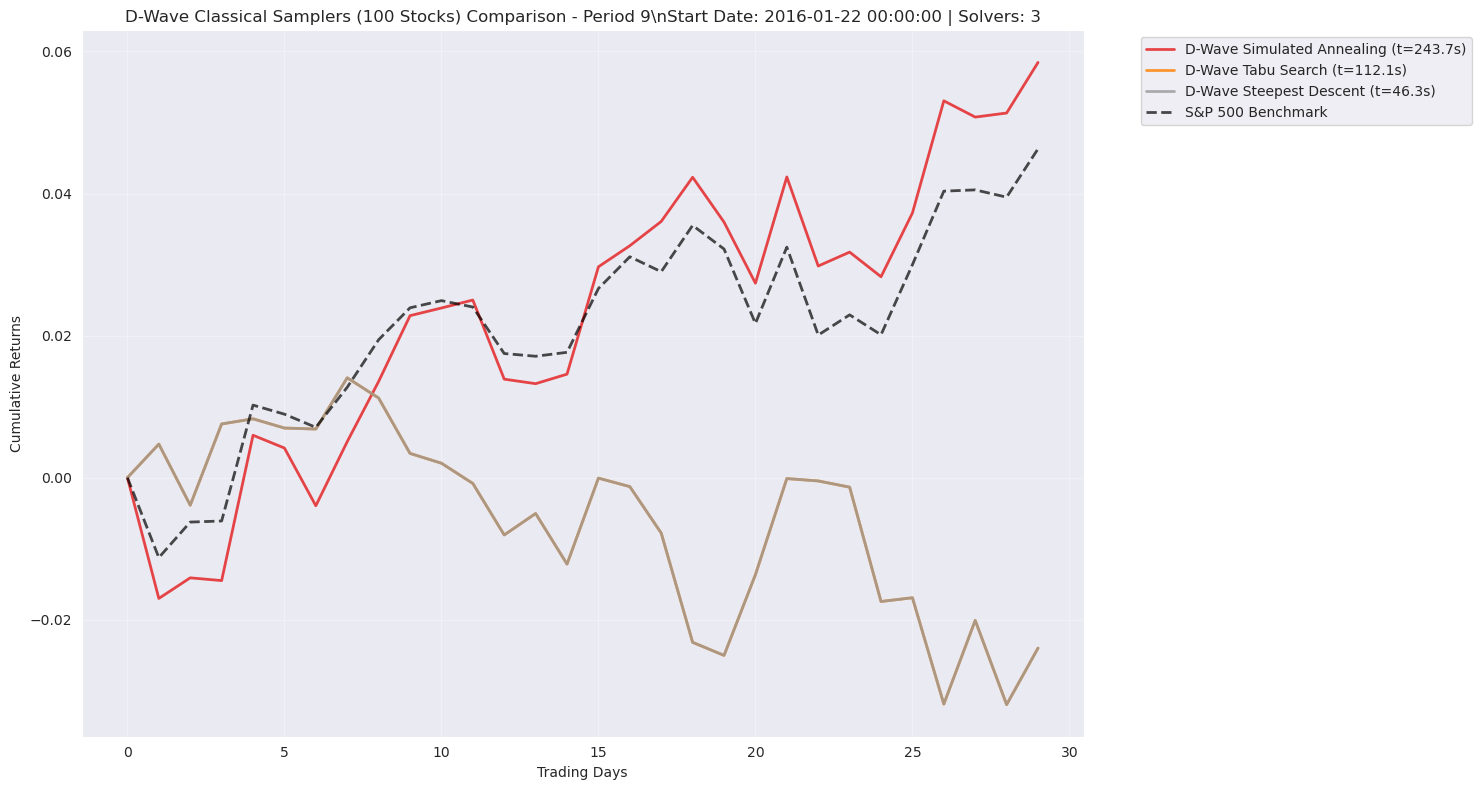

\nPeriod 9 Summary:
--------------------------------------------------
D-Wave Simulated Annealing:   0.0584 (243.72s)
D-Wave Tabu Search       :  -0.0240 (112.11s)
D-Wave Steepest Descent  :  -0.0240 ( 46.31s)
Benchmark                :   0.0463

\n================================================================================
PERFORMANCE SUMMARY - D-Wave Classical Samplers (100 Stocks)


,Solver,Periods,Avg_Return,Std_Return,Min_Return,Max_Return,Avg_Time,Std_Time,Success_Rate
0,D-Wave Simulated Annealing,10,0.0504,0.0381,-0.0228,0.1107,225.0053,12.5839,100.0
1,D-Wave Tabu Search,10,0.0422,0.0439,-0.0240,0.1107,118.1360,9.8958,100.0
2,D-Wave Steepest Descent,10,0.0422,0.0439,-0.0240,0.1107,49.4128,7.2578,100.0


\nKey Insights:
----------------------------------------
🏆 Best Average Return: D-Wave Simulated Annealing
⚡ Fastest Execution: D-Wave Steepest Descent
📈 Most Consistent: D-Wave Simulated Annealing


In [87]:
# D-Wave Classical Samplers Comparison for 100 Stocks using multi_comparison
dwave_100_solvers = [
    {'path_template': '../results/results_100_{}_dwave_sa.pkl', 'name': 'D-Wave Simulated Annealing'},
    {'path_template': '../results/results_100_{}_dwave_tabu.pkl', 'name': 'D-Wave Tabu Search'},
    {'path_template': '../results/results_100_{}_dwave_greedy.pkl', 'name': 'D-Wave Steepest Descent'}
]

n_periods = parameters['n_periods']
multi_comparison(dwave_100_solvers, n_periods, "D-Wave Classical Samplers (100 Stocks)")

# Generate performance summary
print("\\n" + "="*80)
print("PERFORMANCE SUMMARY - D-Wave Classical Samplers (100 Stocks)")
print("="*80)
summary_df = performance_summary(dwave_100_solvers, n_periods)
if not summary_df.empty:
    display(summary_df)
    
    # Additional analysis
    print("\\nKey Insights:")
    print("-" * 40)
    best_avg_return = summary_df.loc[summary_df['Avg_Return'].idxmax(), 'Solver']
    fastest_solver = summary_df.loc[summary_df['Avg_Time'].idxmin(), 'Solver']
    most_consistent = summary_df.loc[summary_df['Std_Return'].idxmin(), 'Solver']
    
    print(f"🏆 Best Average Return: {best_avg_return}")
    print(f"⚡ Fastest Execution: {fastest_solver}")
    print(f"📈 Most Consistent: {most_consistent}")
else:
    print("No summary data available")

### Full dataset

#### D-Wave Simulated Annealing (Full Dataset)

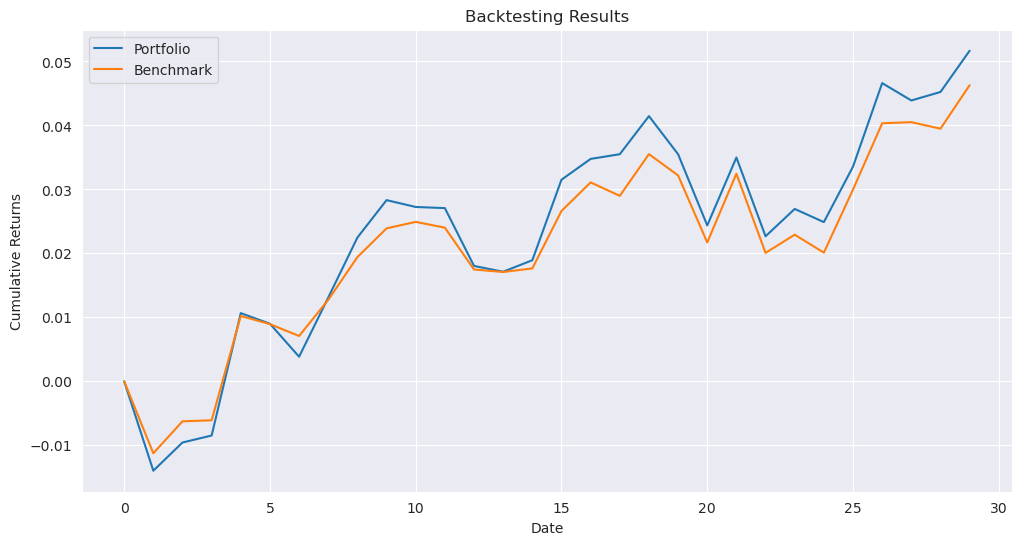

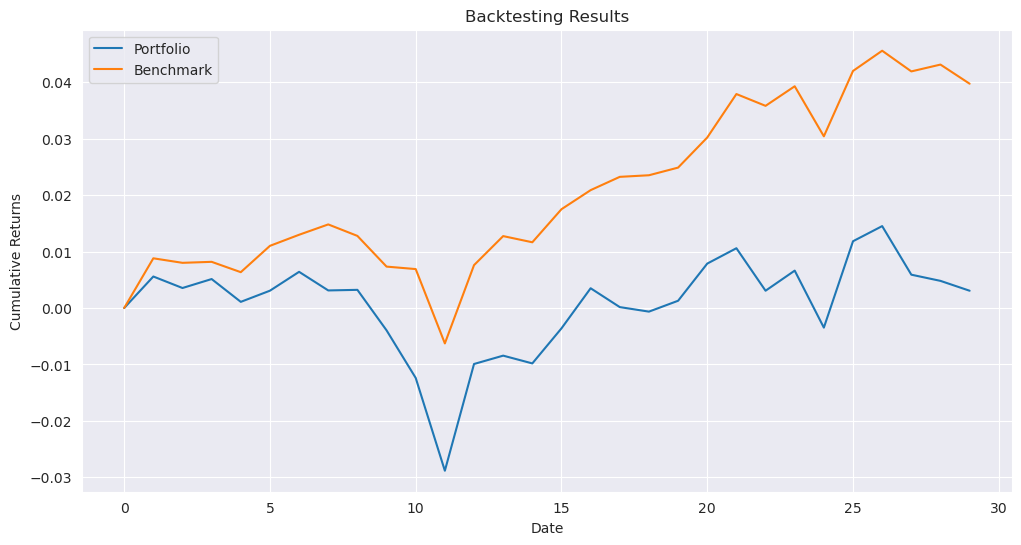

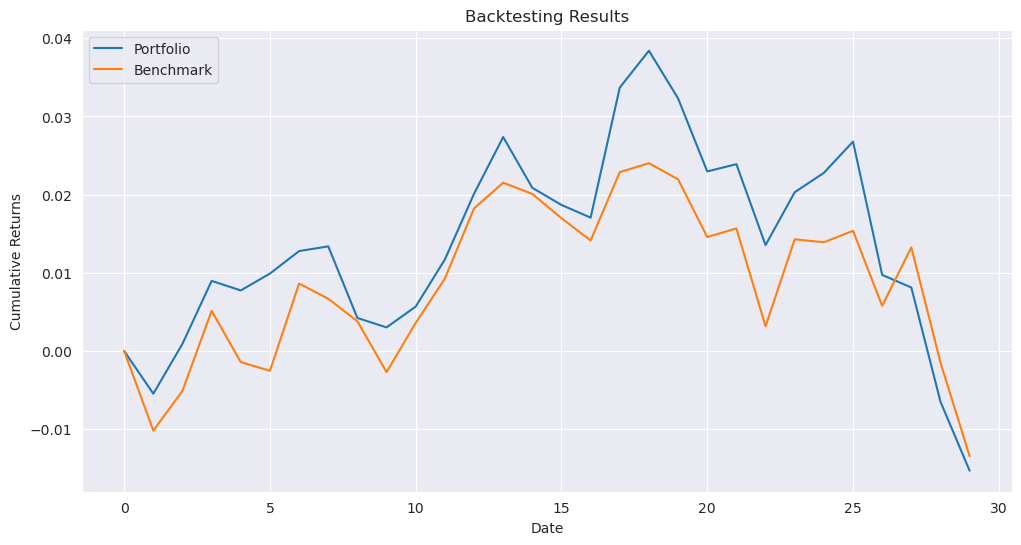

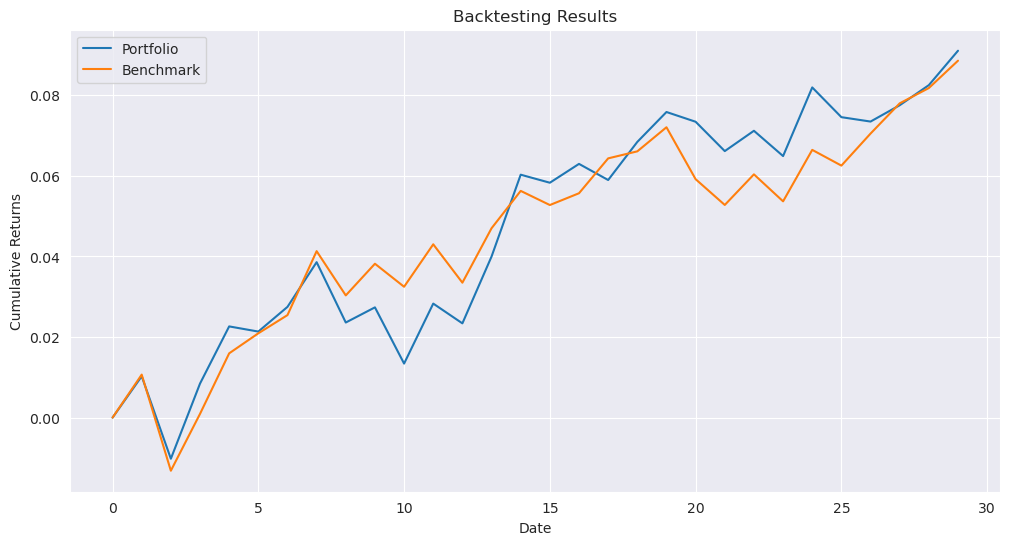

initial date: 2016-03-08 00:00:00


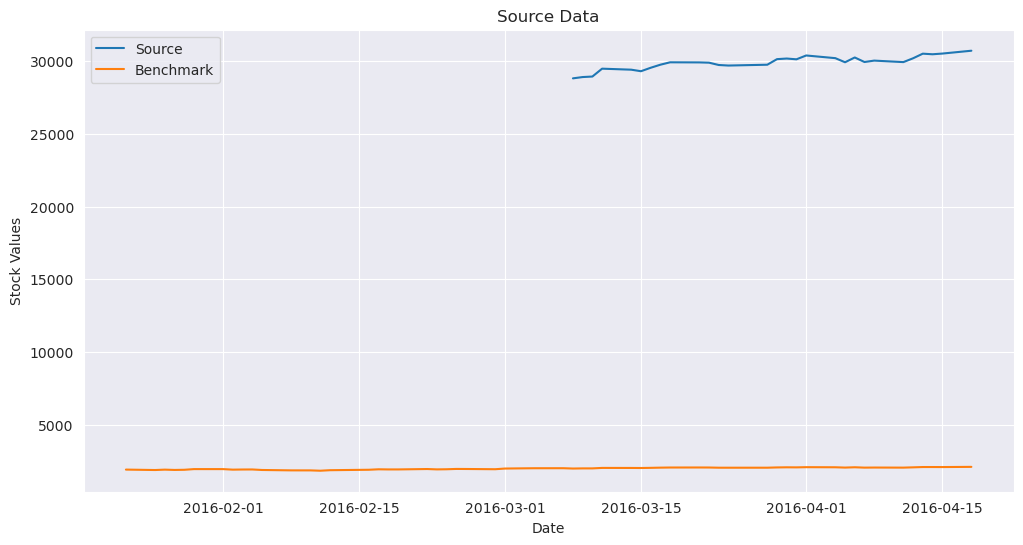

In [ ]:
results_path_dwave_sa_full = '../results/results_full_{}_dwave_sa.pkl'
_ = run_experiment(results_path_dwave_sa_full, source, benchmark, opt_fun_dwave_sa, parameters)

#### D-Wave Tabu Search (Full Dataset)

In [ ]:
results_path_dwave_tabu_full = '../results/results_full_{}_dwave_tabu.pkl'
_ = run_experiment(results_path_dwave_tabu_full, source, benchmark, opt_fun_dwave_tabu, parameters)

#### D-Wave Steepest Descent (Full Dataset)

In [ ]:
results_path_dwave_greedy_full = '../results/results_full_{}_dwave_greedy.pkl'
_ = run_experiment(results_path_dwave_greedy_full, source, benchmark, opt_fun_dwave_greedy, parameters)

#### D-Wave Classical Samplers Comparison for Full Dataset

In [ ]:
# Comprehensive comparison of ALL optimization methods for Full Dataset
all_solvers = [
    # Traditional methods (if available)
    {'path_template': '../results/results_full_{}_ga.pkl', 'name': 'Genetic Algorithm'},
    {'path_template': '../results/results_full_{}_bf.pkl', 'name': 'Scipy SLSQP'},
    {'path_template': '../results/results_full_{}_hrp.pkl', 'name': 'Hierarchical Risk Parity'},
    # D-Wave methods
    {'path_template': '../results/results_full_{}_dwave_sa.pkl', 'name': 'D-Wave Simulated Annealing'},
    {'path_template': '../results/results_full_{}_dwave_tabu.pkl', 'name': 'D-Wave Tabu Search'},
    {'path_template': '../results/results_full_{}_dwave_greedy.pkl', 'name': 'D-Wave Steepest Descent'}
]

n_periods = parameters['n_periods']
multi_comparison(all_solvers, n_periods, "All Optimization Methods (Full Dataset)")

# Generate comprehensive performance summary
print("\\n" + "="*100)
print("COMPREHENSIVE PERFORMANCE SUMMARY - All Methods (Full Dataset)")
print("="*100)
summary_df = performance_summary(all_solvers, n_periods)
if not summary_df.empty:
    # Sort by average return for better readability
    summary_df_sorted = summary_df.sort_values('Avg_Return', ascending=False)
    display(summary_df_sorted)
    
    # Performance analysis
    print("\\nPerformance Analysis:")
    print("-" * 50)
    print(f"Methods compared: {len(summary_df)}")
    print(f"Best performer: {summary_df_sorted.iloc[0]['Solver']} (avg return: {summary_df_sorted.iloc[0]['Avg_Return']:.4f})")
    print(f"Fastest method: {summary_df.loc[summary_df['Avg_Time'].idxmin(), 'Solver']} ({summary_df['Avg_Time'].min():.2f}s)")
    print(f"Most reliable: {summary_df.loc[summary_df['Success_Rate'].idxmax(), 'Solver']} ({summary_df['Success_Rate'].max():.1f}%)")
    
    # Method comparison
    traditional_methods = summary_df[summary_df['Solver'].isin(['Genetic Algorithm', 'Scipy SLSQP', 'Hierarchical Risk Parity'])]
    dwave_methods = summary_df[summary_df['Solver'].str.contains('D-Wave')]
    
    if not traditional_methods.empty and not dwave_methods.empty:
        print("\\nTraditional vs D-Wave Analysis:")
        print("-" * 40)
        print(f"Traditional avg return: {traditional_methods['Avg_Return'].mean():.4f}")
        print(f"D-Wave avg return: {dwave_methods['Avg_Return'].mean():.4f}")
        print(f"Traditional avg time: {traditional_methods['Avg_Time'].mean():.2f}s")
        print(f"D-Wave avg time: {dwave_methods['Avg_Time'].mean():.2f}s")
        
else:
    print("No summary data available")

## Wide dataset

In [ ]:
source_path_extended = '../data/etfs_close.pkl'

In [ ]:
source_extended = pd.read_pickle(source_path_extended)
source_extended.head()

In [ ]:
source_wide = pd.merge(source, source_extended, on='ds', how='left').set_index('ds').dropna()
print(source_wide.shape)
# Check if any row contains at least one NaN
#print(source_wide.isnull().any(axis=1))
# Check if any value in the DataFrame is null
has_any_nan = source_wide.isnull().values.any()
print("Any NaN in source_wide:", has_any_nan)
source_wide.head()

In [ ]:
df = source_wide.copy()
days_to_avg = parameters['days_to_avg']
display(df.head())
print(f'initial date: {df.iloc[days_to_avg+1, :].index}')

#### D-Wave Simulated Annealing (Wide Dataset)

In [ ]:
results_path_dwave_sa_wide = '../results/results_wide_{}_dwave_sa.pkl'
_ = run_experiment(results_path_dwave_sa_wide, df, benchmark, opt_fun_dwave_sa, parameters)

#### D-Wave Tabu Search (Wide Dataset)

In [ ]:
results_path_dwave_tabu_wide = '../results/results_wide_{}_dwave_tabu.pkl'
_ = run_experiment(results_path_dwave_tabu_wide, df, benchmark, opt_fun_dwave_tabu, parameters)

#### D-Wave Steepest Descent (Wide Dataset)

In [ ]:
results_path_dwave_greedy_wide = '../results/results_wide_{}_dwave_greedy.pkl'
_ = run_experiment(results_path_dwave_greedy_wide, df, benchmark, opt_fun_dwave_greedy, parameters)

#### D-Wave Classical Samplers Comparison for Wide Dataset

In [ ]:
# D-Wave Classical Samplers Comparison for Wide Dataset using multi_comparison
dwave_wide_solvers = [
    {'path_template': '../results/results_wide_{}_dwave_sa.pkl', 'name': 'D-Wave Simulated Annealing'},
    {'path_template': '../results/results_wide_{}_dwave_tabu.pkl', 'name': 'D-Wave Tabu Search'},
    {'path_template': '../results/results_wide_{}_dwave_greedy.pkl', 'name': 'D-Wave Steepest Descent'}
]

n_periods = parameters['n_periods']
multi_comparison(dwave_wide_solvers, n_periods, "D-Wave Classical Samplers (Wide Dataset)")

# Generate performance summary
print("\\n" + "="*80)
print("PERFORMANCE SUMMARY - D-Wave Classical Samplers (Wide Dataset)")
print("="*80)
summary_df = performance_summary(dwave_wide_solvers, n_periods)
if not summary_df.empty:
    display(summary_df)
    
    # Additional analysis
    print("\\nKey Insights:")
    print("-" * 40)
    best_avg_return = summary_df.loc[summary_df['Avg_Return'].idxmax(), 'Solver']
    fastest_solver = summary_df.loc[summary_df['Avg_Time'].idxmin(), 'Solver']
    most_consistent = summary_df.loc[summary_df['Std_Return'].idxmin(), 'Solver']
    
    print(f"🏆 Best Average Return: {best_avg_return}")
    print(f"⚡ Fastest Execution: {fastest_solver}")
    print(f"📈 Most Consistent: {most_consistent}")
else:
    print("No summary data available")